<a href="https://colab.research.google.com/github/D2718281828nis/AutomaticControlTheory-Denoising_Signals/blob/main/LLM-GNN-fact-checking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

BioMedAI Fact Checking with RoBERTa + PubMed + Graph Neural Networks
======================================================================

This script demonstrates a comprehensive medical fact-checking system using:
1. RoBERTa transformer models for claim-evidence analysis
2. PubMed literature search for scientific evidence
3. Graph Neural Networks for knowledge graph reasoning

The system evaluates medical claims by analyzing evidence, searching relevant literature,
constructing knowledge graphs, and providing structured verdicts through advanced ML.

Fact Checking Process:
1. Data Preparation: Medical claims with evidence pairs
2. PubMed Literature Search: Scientific paper retrieval
3. Knowledge Graph Construction: Claims, evidence, and papers as nodes
4. Graph Neural Network Reasoning: Multi-hop reasoning over relationships
5. Model Training: Combined RoBERTa + GNN approach
6. Verdict Generation: Enhanced classification with confidence scores


# Load lbraries

In [1]:
!pip install torch_geometric --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 29.9 MB/s eta 0:00:00


In [2]:
#import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, GATConv
from torch_geometric.utils import to_networkx
import networkx as nx
from torch.utils.data import Dataset, DataLoader
from transformers import RobertaTokenizer, RobertaModel
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import logging
from collections import Counter, defaultdict
import warnings
import requests
import time
from urllib.parse import quote_plus
import xml.etree.ElementTree as ET
from torch.optim import AdamW
import random

In [3]:
# Set up logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# Suppress warnings
warnings.filterwarnings('ignore')


from google.colab import userdata

# Get Hugging Face and PubMed token from environment
HF_TOKEN = userdata.get("HF_token_example")
PUBMED_TOKEN = userdata.get("PubMed_token")

In [4]:
if PUBMED_TOKEN:
  print(f"✅ PubMed API token detected")
else:
  print("⚠️  No PubMed API token found. Set PUBMED_TOKEN environment variable to avoid rate limits.")

if HF_TOKEN:
  print("✅ Hugging Face token detected")
else:
  print("⚠️  No Hugging Face")

✅ PubMed API token detected
✅ Hugging Face token detected


In [31]:
class MedicalFactCheckingDataset(Dataset):
    """Dataset class for medical fact-checking data"""

    def __init__(self, claims, evidences, labels, tokenizer, max_length=512):
        self.claims = claims
        self.evidences = evidences
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.claims)

    def __getitem__(self, idx):
        claim = str(self.claims[idx])
        evidence = str(self.evidences[idx])
        label = self.labels[idx]

        # Combine claim and evidence as input
        text = f"Claim: {claim} Evidence: {evidence}"

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

class MedicalKnowledgeGraph:
    """
    Knowledge Graph for Medical Fact Checking
    """

    def __init__(self):
        self.nodes = []
        self.edges = []
        self.node_features = []
        self.node_types = []
        self.node_id_map = {}
        self.node_labels = {}  # For visualization
        self.node_metadata = {}  # Store detailed metadata for each node

    def __repr__(self):
        num_nodes = len(self.nodes)
        num_edges = len(self.edges)
        return f"<MedicalKnowledgeGraph: {num_nodes} nodes, {num_edges} edges>"

    def add_claim_node(self, claim_text, claim_id):
        """Add a claim node to the graph"""
        node_id = len(self.nodes)
        node_name = f"claim_{claim_id}"
        self.nodes.append(node_name)
        self.node_types.append('claim')
        # Handle None case
        claim_text = claim_text if claim_text else "Unknown Claim"
        self.node_labels[node_name] = claim_text[:50] + "..." if len(claim_text) > 50 else claim_text
        self.node_metadata[node_name] = {
            'full_text': claim_text,
            'type': 'claim',
            'id': claim_id
        }
        # Simple feature: text embedding placeholder
        self.node_features.append(self._text_to_features(claim_text))
        self.node_id_map[node_name] = node_id
        return node_id

    def add_evidence_node(self, evidence_text, evidence_id):
        """Add an evidence node to the graph"""
        node_id = len(self.nodes)
        node_name = f"evidence_{evidence_id}"
        self.nodes.append(node_name)
        self.node_types.append('evidence')
        # Handle None case
        evidence_text = evidence_text if evidence_text else "Unknown Evidence"
        self.node_labels[node_name] = evidence_text[:50] + "..." if len(evidence_text) > 50 else evidence_text
        self.node_metadata[node_name] = {
            'full_text': evidence_text,
            'type': 'evidence',
            'id': evidence_id
        }
        self.node_features.append(self._text_to_features(evidence_text))
        self.node_id_map[node_name] = node_id
        return node_id

    def add_paper_node(self, paper_info, paper_id):
        """Add a paper node to the graph"""
        node_id = len(self.nodes)
        node_name = f"paper_{paper_id}"
        self.nodes.append(node_name)
        self.node_types.append('paper')
        # Handle None case for title
        title = paper_info.get('title', 'Unknown Paper') if paper_info else 'Unknown Paper'
        title = title if title else 'Unknown Paper'
        self.node_labels[node_name] = title[:50] + "..." if len(title) > 50 else title
        self.node_metadata[node_name] = {
            'title': title,
            'authors': paper_info.get('authors', []) if paper_info else [],
            'journal': paper_info.get('journal', '') if paper_info else '',
            'year': paper_info.get('year', '') if paper_info else '',
            'pmid': paper_info.get('pmid', '') if paper_info else '',
            'type': 'paper',
            'id': paper_id,
            'relevance_score': paper_info.get('relevance_score', 0.5) if paper_info else 0.5
        }
        # Feature based on paper metadata
        features = self._paper_to_features(paper_info)
        self.node_features.append(features)
        self.node_id_map[node_name] = node_id
        return node_id

    def add_entity_node(self, entity_name, entity_type):
        """Add a medical entity node to the graph"""
        node_key = f"entity_{entity_name}_{entity_type}"
        if node_key in self.node_id_map:
            return self.node_id_map[node_key]

        node_id = len(self.nodes)
        self.nodes.append(node_key)
        self.node_types.append('entity')
        entity_display = f"{entity_name} ({entity_type})" if entity_name and entity_type else "Unknown Entity"
        self.node_labels[node_key] = entity_display[:50] + "..." if len(entity_display) > 50 else entity_display
        self.node_metadata[node_key] = {
            'name': entity_name if entity_name else "Unknown",
            'entity_type': entity_type if entity_type else "Unknown",
            'type': 'entity'
        }
        self.node_features.append(self._entity_to_features(entity_name, entity_type))
        self.node_id_map[node_key] = node_id
        return node_id

    def add_edge(self, source_node_id, target_node_id, relation_type, weight=1.0):
        """Add an edge between nodes"""
        self.edges.append((source_node_id, target_node_id, relation_type, weight))

    def _text_to_features(self, text):
        """Convert text to feature vector (simplified)"""
        if not text:
            return [0, 0, 0]
        words = str(text).lower().split()
        return [len(words), len(set(words)), sum(len(w) for w in words)/len(words) if words else 0]

    def _paper_to_features(self, paper_info):
        """Convert paper info to feature vector"""
        if not paper_info:
            return [0, 0, 0]
        return [1, paper_info.get('relevance_score', 0.5), len(paper_info.get('authors', []))]

    def _entity_to_features(self, entity_name, entity_type):
        """Convert entity to feature vector"""
        if not entity_name or not entity_type:
            return [0, 0, 0]
        type_map = {'disease': 1, 'drug': 2, 'symptom': 3, 'treatment': 4, 'cancer': 5, 'sugar': 6, 'sweetener': 7}
        return [type_map.get(entity_type, 0), len(entity_name), 1]

    def build_torch_geometric_data(self):
        """Convert to PyTorch Geometric format"""
        # Node features
        x = torch.tensor(self.node_features, dtype=torch.float)

        # Edge indices and attributes
        edge_index = []
        edge_attr = []

        for source, target, relation, weight in self.edges:
            edge_index.append([source, target])
            # Encode relation type
            relation_map = {'supports': 1, 'refutes': 2, 'cites': 3, 'mentions': 4, 'related': 5}
            edge_attr.append([relation_map.get(relation, 0), weight])

        if edge_index:
            edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
            edge_attr = torch.tensor(edge_attr, dtype=torch.float)
        else:
            edge_index = torch.empty((2, 0), dtype=torch.long)
            edge_attr = torch.empty((0, 2), dtype=torch.float)

        return Data(x=x, edge_index=edge_index, edge_attr=edge_attr)

    def visualize_graph(self, claim_id=None, max_nodes=100, save_path=None, show_all=False, layout_algorithm='spring', alpha_labels=0.8):
        """
        Visualize the knowledge graph with enhanced styling and filtering options.
        """

        # Create NetworkX graph from edges
        G = nx.DiGraph()

        # Add all nodes with attributes
        node_colors = []
        node_sizes = []
        node_shapes = []
        node_color_map = {
            'claim': '#FF6B6B',      # Red for claims
            'evidence': '#4ECDC4',   # Teal for evidence
            'paper': '#45B7D1',      # Blue for papers
            'entity': '#96CEB4'      # Green for entities
        }

        node_shape_map = {
            'claim': 'o',      # Circle
            'evidence': 's',   # Square
            'paper': 'd',      # Diamond
            'entity': '^'      # Triangle
        }

        # Add all nodes to graph (or filter if claim_id is specified)
        if show_all or claim_id is None:
            # Show all nodes
            nodes_to_show = range(len(self.nodes))
        else:
            # Filter nodes if claim_id is specified
            claim_node_name = f"claim_{claim_id}"
            if claim_node_name in self.node_id_map:
                claim_node_id = self.node_id_map[claim_node_name]
                # Get connected nodes
                connected_nodes = {claim_node_id}
                for source, target, _, _ in self.edges:
                    if source == claim_node_id or target == claim_node_id:
                        connected_nodes.add(source)
                        connected_nodes.add(target)

                # Limit to max_nodes for visualization clarity
                nodes_to_show = list(connected_nodes)[:max_nodes]
            else:
                nodes_to_show = list(range(min(len(self.nodes), max_nodes)))

        # Add filtered nodes to graph
        for node_id in nodes_to_show:
            if node_id < len(self.nodes):
                node_name = self.nodes[node_id]
                node_type = self.node_types[node_id]
                G.add_node(node_name,
                          type=node_type,
                          label=self.node_labels.get(node_name, node_name),
                          metadata=self.node_metadata.get(node_name, {}))
                node_colors.append(node_color_map.get(node_type, '#CCCCCC'))
                node_sizes.append(300 if node_type == 'claim' else 150)
                node_shapes.append(node_shape_map.get(node_type, 'o'))

        # Add all edges between nodes in the graph
        edge_colors = []
        edge_styles = []
        edge_widths = []
        edge_labels = []
        edge_style_map = {
            'supports': 'solid',
            'refutes': 'dashed',
            'cites': 'dotted',
            'mentions': 'dashdot',
            'related': 'solid'
        }
        edge_color_map = {
            'supports': '#2E8B57',   # Green
            'refutes': '#DC143C',    # Crimson
            'cites': '#4169E1',      # Royal Blue
            'mentions': '#FF8C00',   # Dark Orange
            'related': '#808080'     # Gray
        }

        for source, target, relation, weight in self.edges:
            if source in nodes_to_show and target in nodes_to_show:
                G.add_edge(self.nodes[source], self.nodes[target],
                          relation=relation, weight=weight)
                edge_colors.append(edge_color_map.get(relation, '#000000'))
                edge_styles.append(edge_style_map.get(relation, 'solid'))
                edge_widths.append(max(0.5, weight * 2))  # Scale width by weight
                edge_labels.append(relation[:10])  # Short label for edges

        # Create visualization
        plt.figure(figsize=(20, 15))

        # Use selected layout algorithm
        if layout_algorithm == 'spring':
            pos = nx.spring_layout(G, k=3, iterations=50, seed=42)
        elif layout_algorithm == 'kamada_kawai':
            pos = nx.kamada_kawai_layout(G)
        elif layout_algorithm == 'spectral':
            pos = nx.spectral_layout(G)
        elif layout_algorithm == 'circular':
            pos = nx.circular_layout(G)
        else:
            pos = nx.spring_layout(G, k=3, iterations=50, seed=42) # Default to spring

        # Draw nodes by type (to get different shapes)
        for shape in set(node_shapes):
            nodes_of_shape = [n for n, ns in zip(G.nodes(), node_shapes)
                             if ns == shape and n in G.nodes()]
            if nodes_of_shape:
                nx.draw_networkx_nodes(G, pos,
                                     nodelist=nodes_of_shape,
                                     node_color=[node_colors[i] for i, ns in enumerate(node_shapes) if ns == shape and self.nodes[i] in G.nodes()],
                                     node_size=[node_sizes[i] for i, ns in enumerate(node_shapes) if ns == shape and self.nodes[i] in G.nodes()],
                                     node_shape=shape,
                                     alpha=0.8)

        # Draw edges
        nx.draw_networkx_edges(G, pos,
                              edge_color=edge_colors,
                              style=edge_styles,
                              width=edge_widths,
                              alpha=0.6,
                              arrows=True,
                              arrowsize=15)

        # Draw labels with better positioning
        labels = nx.get_node_attributes(G, 'label')
        nx.draw_networkx_labels(G, pos, labels, font_size=8, font_weight='bold', alpha=alpha_labels)

        # Create legend
        legend_elements = []
        for node_type, color in node_color_map.items():
            legend_elements.append(plt.Line2D([0], [0], marker='o', color='w',
                                            markerfacecolor=color, markersize=10,
                                            label=f'{node_type.capitalize()}'))

        for relation, color in edge_color_map.items():
            legend_elements.append(plt.Line2D([0], [0], color=color, linestyle=edge_style_map.get(relation, 'solid'),
                                            linewidth=2, label=f'{relation.capitalize()}'))

        plt.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.05, 1))

        plt.title('Medical Knowledge Graph Visualization', fontsize=16, fontweight='bold')
        plt.axis('off')
        plt.tight_layout()

        # Save or show
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"Graph visualization saved to {save_path}")
        else:
            plt.show()

        # Print graph statistics
        print(f"\n\U0001f4ca Graph Statistics:")
        print(f"  Nodes: {G.number_of_nodes()}")
        print(f"  Edges: {G.number_of_edges()}")
        node_types = nx.get_node_attributes(G, 'type')
        if node_types:
            print(f"  Node Types: {dict(Counter(node_types.values()))}")
        edge_relations = nx.get_edge_attributes(G, 'relation')
        if edge_relations:
            print(f"  Relationship Types: {dict(Counter(edge_relations.values()))}")

        return G

class GNNFactChecker(nn.Module):
    """
    Graph Neural Network for Medical Fact Checking
    """

    def __init__(self, num_node_features, hidden_dim=64, num_classes=2):
        super(GNNFactChecker, self).__init__()

        # GCN layers for local neighborhood aggregation
        self.conv1 = GCNConv(num_node_features, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)

        # GAT layer for attention-based reasoning
        self.gat1 = GATConv(hidden_dim, hidden_dim, heads=4, dropout=0.1)
        self.gat2 = GATConv(hidden_dim * 4, hidden_dim, heads=1, dropout=0.1)

        # Classification layers
        self.dropout = nn.Dropout(0.3)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim // 2, num_classes)
        )

    def forward(self, data):
        x, edge_index = data.x, data.edge_index

        # GCN layers
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        x = F.relu(x)

        # GAT layers
        x = self.gat1(x, edge_index)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.gat2(x, edge_index)

        # Global pooling (mean pooling)
        graph_embedding = torch.mean(x, dim=0, keepdim=True)

        # Classification
        output = self.classifier(graph_embedding)

        return output.squeeze(0)

class HybridFactChecker(nn.Module):
    """
    Hybrid Fact Checker combining RoBERTa and GNN
    """

    def __init__(self, roberta_model, gnn_model, hidden_dim=64):
        super(HybridFactChecker, self).__init__()
        self.roberta = roberta_model
        self.gnn = gnn_model

        # Fusion layer
        self.fusion = nn.Linear(hidden_dim + 768, hidden_dim)  # 768 = RoBERTa hidden size
        #fusion layer concatenates two vectors (resulting in a vector of size hidden_dim + 768)
        #and then projects them down to hidden_dim dimensions. This is a common practice
        # in multimodal fusion to combine features from different modalities (text and graph)
        # into a shared representation space.
        self.classifier = nn.Linear(hidden_dim, 2)
        self.dropout = nn.Dropout(0.3)

    def forward(self, input_ids, attention_mask, graph_data):
        # RoBERTa encoding
        roberta_outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        roberta_embedding = roberta_outputs.last_hidden_state[:, 0, :]  # CLS token

        # GNN encoding
        gnn_output = self.gnn(graph_data).unsqueeze(0)

        # Fusion
        combined = torch.cat([roberta_embedding, gnn_output], dim=1)
        fused = F.relu(self.fusion(combined))
        fused = self.dropout(fused)

        # Final classification
        logits = self.classifier(fused)

        return logits

def parse_pubmed_xml(xml_content):
    """
    Parse PubMed XML content to extract paper information and citations.
    """
    try:
        if not xml_content:
            return []
        root = ET.fromstring(xml_content)
        papers = []

        for article in root.findall('.//PubmedArticle'):
            # Extract PMID
            pmid_elem = article.find('.//PMID')
            pmid = pmid_elem.text if pmid_elem is not None and pmid_elem.text else 'Unknown'

            # Extract title
            title_elem = article.find('.//ArticleTitle')
            title = title_elem.text if title_elem is not None and title_elem.text else 'Unknown Title'

            # Extract authors
            authors = []
            for author in article.findall('.//Author'):
                lastname_elem = author.find('LastName')
                firstname_elem = author.find('ForeName')
                if lastname_elem is not None and firstname_elem is not None and lastname_elem.text and firstname_elem.text:
                    authors.append(f"{firstname_elem.text} {lastname_elem.text}")

            # Extract journal
            journal_elem = article.find('.//Journal/Title')
            journal = journal_elem.text if journal_elem is not None and journal_elem.text else 'Unknown Journal'

            # Extract year
            year_elem = article.find('.//PubDate/Year')
            year = year_elem.text if year_elem is not None and year_elem.text else 'Unknown Year'

            papers.append({
                'pmid': pmid,
                'title': title,
                'authors': authors,
                'journal': journal,
                'year': year
            })

        return papers
    except Exception as e:
        logger.warning(f"Failed to parse PubMed XML: {e}")
        return []

def search_pubmed(query, max_results=5, api_key=None):
    """
    Search PubMed for relevant medical literature with proper API key usage and rate limiting.
    """

    # Construct PubMed API URLs
    base_url = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/esearch.fcgi"
    fetch_url = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi"

    # Prepare search parameters with API key
    params = {
        'db': 'pubmed',
        'term': query,
        'retmax': max_results,
        'retmode': 'json',
        'sort': 'relevance'
    }

    # Add API key if provided
    if api_key:
        params['api_key'] = api_key

    try:
        # Search for papers
        search_response = requests.get(base_url, params=params, timeout=10)
        search_response.raise_for_status()
        search_data = search_response.json()

        # Extract PMIDs
        pmids = search_data.get('esearchresult', {}).get('idlist', [])

        if not pmids:
            return {
                'papers': [],
                'abstracts': [],
                'total_papers': 0,
                'confidence_boost': 0,
                'literature_evidence': 'No relevant literature found'
            }

        # Fetch paper details with rate limiting
        fetch_params = {
            'db': 'pubmed',
            'id': ','.join(pmids),
            'retmode': 'xml',
            'rettype': 'abstract'
        }

        # Add API key to fetch request as well
        if api_key:
            fetch_params['api_key'] = api_key

        # Rate limiting - add delay to respect API limits
        time.sleep(0.2)  # 200ms delay between requests

        fetch_response = requests.get(fetch_url, params=fetch_params, timeout=10)
        fetch_response.raise_for_status()

        # Parse XML response
        papers = parse_pubmed_xml(fetch_response.text)

        # Add relevance scores and abstracts
        abstracts = []
        for i, paper in enumerate(papers):
            if 'relevance_score' not in paper:
                paper['relevance_score'] = max(0.7, 1.0 - i * 0.1)  # Decreasing relevance
            abstracts.append(f"Abstract of study examining {query}. Findings support current medical understanding.")

        # Calculate confidence boost based on literature quality
        confidence_boost = min(0.3, len(papers) * 0.1)  # Max 30% confidence boost

        literature_evidence = f"Found {len(papers)} relevant studies. "
        if len(papers) >= 2:
            literature_evidence += "Strong literature support."
        elif len(papers) == 1:
            literature_evidence += "Moderate literature support."
        else:
            literature_evidence += "Limited literature support."

        return {
            'papers': papers,
            'abstracts': abstracts,
            'total_papers': len(papers),
            'confidence_boost': confidence_boost,
            'literature_evidence': literature_evidence
        }

    except requests.exceptions.HTTPError as e:
        if e.response.status_code == 429:
            logger.warning(f"PubMed API rate limit exceeded for query '{query}'. Consider using an API key.")
            # Return empty results instead of failing
            return {
                'papers': [],
                'abstracts': [],
                'total_papers': 0,
                'confidence_boost': 0,
                'literature_evidence': 'API rate limit exceeded. Try again later.'
            }
        else:
            logger.warning(f"PubMed search failed for query '{query}': {e}")
            return {
                'papers': [],
                'abstracts': [],
                'total_papers': 0,
                'confidence_boost': 0,
                'literature_evidence': f'Literature search error: {str(e)}'
            }
    except Exception as e:
        logger.warning(f"PubMed search failed for query '{query}': {e}")
        return {
            'papers': [],
            'abstracts': [],
            'total_papers': 0,
            'confidence_boost': 0,
            'literature_evidence': f'Literature search error: {str(e)}'
        }

def enhance_claim_with_literature(claim, verdict):
    """
    Enhance claim evaluation with PubMed literature search.
    """

    # Construct search query based on claim and verdict
    if verdict == 'Supported by Evidence':
        # Look for supporting evidence
        search_query = f"{claim} AND (clinical trial OR meta-analysis OR systematic review)"
    else:
        # Look for contradicting evidence or studies showing no effect
        search_query = f"{claim} AND (no effect OR contradicts OR systematic review)"

    # Perform PubMed search
    pubmed_results = search_pubmed(search_query, max_results=5, api_key=PUBMED_TOKEN)

    # Generate enhanced evidence text
    if pubmed_results['total_papers'] > 0:
        literature_summary = f"PubMed literature review found {pubmed_results['total_papers']} relevant papers. "
        literature_summary += pubmed_results['literature_evidence']
        enhanced_evidence = f"{pubmed_results['literature_evidence']} {pubmed_results['abstracts'][0][:200]}..."
    else:
        literature_summary = "No relevant PubMed literature found for this claim."
        enhanced_evidence = f"No PubMed literature available. {pubmed_results['literature_evidence']}"

    return {
        'enhanced_evidence': enhanced_evidence,
        'literature_summary': literature_summary,
        'confidence_boost': pubmed_results['confidence_boost'],
        'papers_found': pubmed_results['total_papers'],
        'papers': pubmed_results['papers']
    }

def build_knowledge_graph_for_claim(claim, evidence, papers, claim_id):
    """
    Build knowledge graph for a single claim-evidence pair with paper citations.
    """

    kg = MedicalKnowledgeGraph()

    # Add nodes
    claim_node_id = kg.add_claim_node(claim, claim_id)
    evidence_node_id = kg.add_evidence_node(evidence, claim_id)

    # Add paper nodes
    paper_node_ids = []
    paper_metadata = {}
    for i, paper in enumerate(papers):
        paper_node_id = kg.add_paper_node(paper, f"{claim_id}_{i}")
        paper_node_ids.append(paper_node_id)
        paper_metadata[paper_node_id] = paper

    # Add entity nodes (simplified extraction)
    entities = extract_medical_entities(claim)
    entity_node_ids = []
    for entity, entity_type in entities:
        entity_node_id = kg.add_entity_node(entity, entity_type)
        entity_node_ids.append(entity_node_id)

    # Add edges
    # Claim-Evidence relationship
    kg.add_edge(claim_node_id, evidence_node_id, 'related', weight=1.0)
    kg.add_edge(evidence_node_id, claim_node_id, 'related', weight=1.0)

    # Evidence-Paper relationships
    for paper_node_id in paper_node_ids:
        kg.add_edge(evidence_node_id, paper_node_id, 'supports', weight=0.8)
        kg.add_edge(paper_node_id, evidence_node_id, 'related', weight=0.6)

    # Claim-Entity relationships
    for entity_node_id in entity_node_ids:
        kg.add_edge(claim_node_id, entity_node_id, 'mentions', weight=0.7)
        kg.add_edge(entity_node_id, claim_node_id, 'mentioned_in', weight=0.7)

    # Paper-Paper citations (simplified - in practice, extract from references)
    # For demonstration, create citation network based on relevance scores
    if len(paper_node_ids) > 1:
        # Sort papers by relevance score
        paper_scores = [(pid, paper_metadata[pid].get('relevance_score', 0.5)) for pid in paper_node_ids]
        paper_scores.sort(key=lambda x: x[1], reverse=True)

        # Create citation links from higher relevance to lower relevance papers
        for i in range(len(paper_scores) - 1):
            source_pid = paper_scores[i][0]
            target_pid = paper_scores[i + 1][0]
            citation_weight = 0.5 + (paper_scores[i][1] - paper_scores[i + 1][1]) * 2
            kg.add_edge(source_pid, target_pid, 'cites', weight=min(1.0, citation_weight))

    return kg

In [27]:
def extract_medical_entities(text):
    """
    Simple medical entity extraction (in practice, use medical NER models).
    Returns list of (entity, type) tuples.
    """
    if not text:
        return []
    # Simplified entity extraction
    entities = []

    # Disease keywords
    diseases = ['disease', 'disorder', 'syndrome', 'condition', 'infection', 'cancer', 'diabetes', 'hypertension', 'obesity']
    for disease in diseases:
        if disease in text.lower():
            entities.append((disease, 'disease'))

    # Treatment keywords
    treatments = ['treatment', 'therapy', 'medication', 'drug', 'vaccine', 'sweetener', 'sugar', 'additive']
    for treatment in treatments:
        if treatment in text.lower():
            entities.append((treatment, 'treatment'))

    # Symptom keywords
    symptoms = ['symptom', 'sign', 'effect', 'impact', 'risk', 'mortality', 'weight', 'cancer']
    for symptom in symptoms:
        if symptom in text.lower():
            entities.append((symptom, 'symptom'))

    return entities

def load_and_preprocess_medical_data(visualize=True, use_pubmed=True, use_gnn=True, num_supported = 50):
    """
    Load and preprocess sample medical fact-checking data with imbalanced distribution
    and optional PubMed literature + GNN integration.
    """
    logger.info("Loading and preprocessing medical data...")

    # Base medical claims - realistic examples
    base_claims_supported = [
        "Regular exercise reduces cardiovascular disease risk.",
        "Mediterranean diet promotes longevity.",
        "Chronic stress weakens immune function.",
        "Sleep deprivation impairs cognitive performance.",
        "Breastfeeding boosts infant immunity.",
        "Omega-3 fatty acids benefit heart health.",
        "High fiber diet reduces colon cancer risk.",
        "Sun exposure in moderation provides vitamin D benefits.",
        "Probiotics support digestive health.",
        "Mindfulness meditation reduces anxiety.",
        "Vaccination prevents infectious diseases.",
        "Hand washing prevents disease transmission.",
        "Adequate hydration supports kidney function.",
        "Strength training maintains muscle mass with aging.",
        "Fruits and vegetables provide essential antioxidants."
    ]

    base_claims_refuted = [
        "Vitamin C can cure the common cold.",
        "Antibiotics treat viral infections.",
        "Probiotics cure serious bacterial infections.",
        "Eating carrots significantly improves night vision.",
        "Vaccines cause autism.",
        "Drinking exactly 8 glasses of water daily is required.",
        "MSG causes headaches in everyone.",
        "Microwave cooking destroys all nutrients.",
        "Red wine consumption is always heart-healthy.",
        "Artificial sweeteners cause cancer.",
        "Detox diets are necessary for body cleansing.",
        "Protein intake damages healthy kidneys.",
        "Crash diets are effective for long-term weight loss.",
        "Supplements replace a balanced diet.",
        "All fats are bad for health.",
        "Organic food always prevents disease.",
        "Homeopathy cures serious illnesses.",
        "Essential oils cure chronic conditions.",
        "Fasting cleanses toxins from organs.",
        "Alkaline water prevents cancer."
    ]

    # Simulate a larger, imbalanced dataset (~90% Refuted)
    #num_supported = 300  # Reduced for testing
    #num_refuted = int(0.9 * (len(base_claims_supported) + len(base_claims_refuted)) * 2)
    num_refuted = num_supported

    supported_claims = np.random.choice(base_claims_supported, size=num_supported, replace=True).tolist()
    refuted_claims = np.random.choice(base_claims_refuted, size=num_refuted, replace=True).tolist()

    all_claims = supported_claims + refuted_claims
    all_verdicts = ['Supported by Evidence'] * len(supported_claims) + ['Refuted by Evidence'] * len(refuted_claims)

    combined = list(zip(all_claims, all_verdicts))
    np.random.shuffle(combined)
    claims_shuffled, verdicts_shuffled = zip(*combined)
    claims_shuffled, verdicts_shuffled = list(claims_shuffled), list(verdicts_shuffled)

    # Generate corresponding evidence texts with optional PubMed integration
    evidence_texts = []
    labels = []
    literature_info = []
    knowledge_graphs = []

    print("\U0001f50d Integrating PubMed literature search and GNN knowledge graphs...")

    for i, (claim, verdict) in enumerate(zip(claims_shuffled, verdicts_shuffled)):
        if i % 5 == 0:  # Progress indicator
            print(f"  Processing claim {i+1}/{len(claims_shuffled)}: {claim[:50] if claim else 'Unknown Claim'}...")

        if verdict == 'Supported by Evidence':
            # Generate supporting evidence
            base_evidence = f"Clinical studies and meta-analyses consistently demonstrate that {claim.lower()[:-1] if claim else 'unknown claim'} is supported by robust scientific evidence."
            label = 1  # Supported
        else:
            # Generate refuting evidence
            base_evidence = f"Epidemiological research and systematic reviews show that {claim.lower()[:-1] if claim else 'unknown claim'} is contradicted by current medical understanding."
            label = 0  # Refuted

        # Integrate PubMed literature if enabled
        if use_pubmed:
            literature_results = enhance_claim_with_literature(claim, verdict)
            enhanced_evidence = f"{base_evidence} {literature_results['enhanced_evidence']}"
            literature_summary = literature_results['literature_summary']
            papers = literature_results['papers']
        else:
            enhanced_evidence = base_evidence
            literature_summary = "PubMed integration disabled"
            papers = []

        # Build knowledge graph if GNN is enabled
        if use_gnn:
            kg = build_knowledge_graph_for_claim(claim, enhanced_evidence, papers, i)
            knowledge_graphs.append(kg)
        else:
            # Create empty knowledge graph
            kg = MedicalKnowledgeGraph()
            knowledge_graphs.append(kg)

        evidence_texts.append(enhanced_evidence)
        labels.append(label)
        literature_info.append(literature_summary)

        # Rate limiting for PubMed API - only when actually making requests
        if use_pubmed and literature_results['papers_found'] > 0:
            time.sleep(0.1)  # Brief delay to respect API limits

    # Create DataFrame
    df = pd.DataFrame({
        'medical_claim': claims_shuffled,
        'evidence_text': evidence_texts,
        'label': labels,
        'verdict_text': verdicts_shuffled,
        'literature_info': literature_info
    })

    logger.info(f"Loaded {len(df)} medical claim-evidence pairs")
    logger.info(f"Class distribution - Supported: {sum(labels)}, Refuted: {len(labels) - sum(labels)}")

    if use_gnn and knowledge_graphs:
      df['knowledge_graph'] = knowledge_graphs # Add list as new column
    else:
      df['knowledge_graph'] = [None] * len(df) # Add None if GNN disabled or no graphs

    return df

def visualize_all_graphs(knowledge_graphs, save_path='complete_knowledge_graph.png', layout_algorithm='spring', alpha_labels=0.8):
    """
    Visualize all knowledge graphs combined into one comprehensive graph.
    """

    print(f"\U0001f3a8 Creating comprehensive visualization of all knowledge graphs...")

    # Create a unified graph combining all individual graphs
    unified_kg = MedicalKnowledgeGraph()
    node_mapping = {}  # Map old node IDs to new unified IDs
    paper_citations = []  # Store citation relationships

    # Process each knowledge graph
    for kg_idx, kg in enumerate(knowledge_graphs):
        # Add all nodes from this graph
        for i, (node_name, node_type) in enumerate(zip(kg.nodes, kg.node_types)):
            if node_name not in node_mapping:
                # Add node to unified graph
                metadata = kg.node_metadata.get(node_name, {})
                if node_type == 'claim':
                    unified_kg.add_claim_node(metadata.get('full_text', ''),
                                            metadata.get('id', kg_idx))
                elif node_type == 'evidence':
                    unified_kg.add_evidence_node(metadata.get('full_text', ''),
                                               metadata.get('id', kg_idx))
                elif node_type == 'paper':
                    unified_kg.add_paper_node(metadata,
                                            metadata.get('id', kg_idx))
                elif node_type == 'entity':
                    unified_kg.add_entity_node(metadata.get('name', ''),
                                             metadata.get('entity_type', ''))

                node_mapping[node_name] = len(unified_kg.nodes) - 1

        # Add all edges from this graph
        for source_id, target_id, relation, weight in kg.edges:
            source_name = kg.nodes[source_id]
            target_name = kg.nodes[target_id]

            if source_name in node_mapping and target_name in node_mapping:
                unified_kg.add_edge(node_mapping[source_name],
                                  node_mapping[target_name],
                                  relation, weight)

    # Visualize the unified graph
    try:
        print("  Creating comprehensive graph visualization...")
        graph_nx = unified_kg.visualize_graph(show_all=True, save_path=save_path, layout_algorithm=layout_algorithm, alpha_labels=alpha_labels)
        print(f"  \u2705 Complete knowledge graph visualization saved to {save_path}")

        return unified_kg
    except Exception as e:
        print(f"  \u274c Failed to create comprehensive visualization: {e}")
        return None

In [28]:
def train_and_evaluate_medical_baseline(model_name='roberta-base', epochs=2, batch_size=4, learning_rate=2e-5, visualize=True, use_pubmed=True, use_gnn=True):
    """
    Main function to load medical data, prepare model, train, and evaluate the hybrid system,
    including visualizations of the process and results.
    """
    logger.info("Starting Hybrid Medical Fact Checking (RoBERTa + PubMed + GNN)...")

    # 1. Load and preprocess medical data

    # Inside train_and_evaluate_medical_baseline:
    df = load_and_preprocess_medical_data(visualize=visualize, use_pubmed=use_pubmed, use_gnn=use_gnn, num_supported = 20) # NEW

    df['kg_summary'] = df['knowledge_graph'].apply(lambda kg: f"{len(kg.nodes)} nodes, {len(kg.edges)} edges" if kg else "No Graph")

    # Now print df, it will show the summary column
    print(df[['medical_claim', 'label', 'kg_summary']].head()) # Show relevant columns

    # Access knowledge_graphs if needed later via df['knowledge_graph'] (if 'knowledge_graph' in df.columns else [])
    knowledge_graphs = df['knowledge_graph'].tolist() if 'knowledge_graph' in df.columns else []

    if df.empty:
        logger.error("No medical data available after preprocessing. Exiting.")
        return None, None, 0, "No data"

    # 2. Visualize all knowledge graphs combined
    if visualize and use_gnn and 'knowledge_graph' in df.columns and not df['knowledge_graph'].dropna().empty:
      unified_graph = visualize_all_graphs(df['knowledge_graph'].tolist(), save_path='complete_knowledge_graph.png', layout_algorithm='spring', alpha_labels=0.2)


    # 3. Prepare data for training
    claims = df['medical_claim'].tolist()
    evidences = df['evidence_text'].tolist()
    labels = df['label'].tolist()

    train_claims, val_claims, train_evidences, val_evidences, train_labels, val_labels = train_test_split(
        claims, evidences, labels, test_size=0.2, random_state=42, stratify=labels
    )

    # Split knowledge graphs accordingly
    train_indices, val_indices = train_test_split(
        range(len(claims)), test_size=0.2, random_state=42, stratify=labels
    )
    train_knowledge_graphs = [df['knowledge_graph'].iloc[i] for i in train_indices] if 'knowledge_graph' in df.columns else []
    val_knowledge_graphs = [df['knowledge_graph'].iloc[i] for i in val_indices] if 'knowledge_graph' in df.columns else []

    # Convert knowledge graphs to PyTorch Geometric data
    train_graph_data = [kg.build_torch_geometric_data() for kg in train_knowledge_graphs] if train_knowledge_graphs else []
    val_graph_data = [kg.build_torch_geometric_data() for kg in val_knowledge_graphs] if val_knowledge_graphs else []

    if visualize:
        split_data = pd.DataFrame({
            'Split': ['Train'] * len(train_labels) + ['Validation'] * len(val_labels),
            'Label': train_labels + val_labels
        })
        label_names = {0: 'Refuted', 1: 'Supported'}
        split_data['Label_Name'] = split_data['Label'].map(label_names)

        plt.figure(figsize=(12, 5))
        ax1 = plt.subplot(1, 2, 1)
        split_counts = split_data['Split'].value_counts()
        sns.barplot(x=split_counts.index, y=split_counts.values, palette='Set2', ax=ax1)
        ax1.set_title('Data Split Sizes')
        ax1.set_ylabel('Number of Samples')

        ax2 = plt.subplot(1, 2, 2)
        crosstab_df = pd.crosstab(split_data['Split'], split_data['Label_Name'])
        crosstab_df.plot(kind='bar', ax=ax2, color=['salmon', 'skyblue'])
        ax2.set_title('Label Distribution in Splits')
        ax2.set_xlabel('Data Split')
        ax2.set_ylabel('Count')
        ax2.legend(title='Verdict')
        plt.xticks(rotation=0)
        plt.tight_layout()
        plt.show()
        logger.info("Displayed data split visualization.")

    # 4. Load tokenizer and RoBERTa model using HF_TOKEN
    logger.info(f"Loading tokenizer and model '{model_name}' from Hugging Face...")
    try:
        # Pass the token when loading from_pretrained
        tokenizer_kwargs = {"use_auth_token": HF_TOKEN} if HF_TOKEN else {}
        model_kwargs = {"use_auth_token": HF_TOKEN} if HF_TOKEN else {}

        tokenizer = RobertaTokenizer.from_pretrained(model_name, **tokenizer_kwargs)
        roberta_model = RobertaModel.from_pretrained(model_name, **model_kwargs)
        logger.info("Tokenizer and RoBERTa model loaded successfully.")
    except Exception as e:
        logger.error(f"Failed to load tokenizer or model '{model_name}': {e}")
        return None, None, 0, f"Load Error: {e}"

    # 5. Initialize GNN model
    if use_gnn:
        gnn_model = GNNFactChecker(num_node_features=3, hidden_dim=64, num_classes=2)
        hybrid_model = HybridFactChecker(roberta_model, gnn_model)
        logger.info("GNN and Hybrid model initialized successfully.")
    else:
        # Fallback to RoBERTa-only model
        hybrid_model = roberta_model
        logger.info("Using RoBERTa-only model (GNN disabled).")

    # 6. Create datasets and dataloaders
    train_dataset = MedicalFactCheckingDataset(train_claims, train_evidences, train_labels, tokenizer)
    val_dataset = MedicalFactCheckingDataset(val_claims, val_evidences, val_labels, tokenizer)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    # 7. Setup training
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    hybrid_model.to(device)
    optimizer = AdamW(hybrid_model.parameters(), lr=learning_rate)

    # Store metrics for each epoch
    epoch_metrics = {
        'train_loss': [],
        'val_loss': [],
        'val_accuracy': [],
        'val_precision': [],
        'val_recall': [],
        'val_f1': []
    }

    # 8. Training loop with epoch-by-epoch results
    logger.info("Starting training loop...")
    for epoch in range(epochs):
        print(f"\n{'='*60}")
        print(f"Epoch {epoch + 1}/{epochs}")
        print(f"{'='*60}")

        # Training phase
        hybrid_model.train()
        total_train_loss = 0
        train_steps = 0

        for batch_idx, batch in enumerate(train_loader):
            optimizer.zero_grad()

            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels_batch = batch['labels'].to(device)

            # Forward pass (simplified - in practice, handle graph data properly)
            if use_gnn:
                # This is a simplified approach - in practice, you'd batch graph data properly
                roberta_outputs = hybrid_model.roberta(input_ids=input_ids, attention_mask=attention_mask)
                outputs = roberta_outputs.last_hidden_state[:, 0, :]  # CLS token
                # Add simple classification head
                classifier = nn.Linear(outputs.size(-1), 2).to(device)
                outputs = classifier(outputs)
            else:
                # RoBERTa-only forward pass
                roberta_outputs = hybrid_model(input_ids=input_ids, attention_mask=attention_mask)
                outputs = roberta_outputs.last_hidden_state[:, 0, :]  # CLS token
                # Add simple classification head for RoBERTa-only
                classifier = nn.Linear(outputs.size(-1), 2).to(device)
                outputs = classifier(outputs)

            # Compute loss
            if len(outputs.shape) == 1:
                outputs = outputs.unsqueeze(0)
            loss = F.cross_entropy(outputs, labels_batch)
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()
            train_steps += 1

            if batch_idx % 2 == 0:  # Print every 2 batches
                print(f"  Batch {batch_idx}: Train Loss = {loss.item():.4f}")

        avg_train_loss = total_train_loss / train_steps if train_steps > 0 else 0
        epoch_metrics['train_loss'].append(avg_train_loss)

        # Validation phase
        hybrid_model.eval()
        total_val_loss = 0
        val_predictions = []
        val_true_labels = []
        val_steps = 0

        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels_batch = batch['labels'].to(device)

                # Forward pass
                if use_gnn:
                    roberta_outputs = hybrid_model.roberta(input_ids=input_ids, attention_mask=attention_mask)
                    outputs = roberta_outputs.last_hidden_state[:, 0, :]
                    classifier = nn.Linear(outputs.size(-1), 2).to(device)
                    outputs = classifier(outputs)
                else:
                    roberta_outputs = hybrid_model(input_ids=input_ids, attention_mask=attention_mask)
                    outputs = roberta_outputs.last_hidden_state[:, 0, :]
                    classifier = nn.Linear(outputs.size(-1), 2).to(device)
                    outputs = classifier(outputs)

                if len(outputs.shape) == 1:
                    outputs = outputs.unsqueeze(0)

                loss = F.cross_entropy(outputs, labels_batch)
                logits = outputs

                total_val_loss += loss.item()
                val_steps += 1

                predictions = torch.argmax(logits, dim=-1)
                val_predictions.extend(predictions.cpu().numpy())
                val_true_labels.extend(labels_batch.cpu().numpy())

        avg_val_loss = total_val_loss / val_steps if val_steps > 0 else 0
        accuracy = accuracy_score(val_true_labels, val_predictions) if val_true_labels and val_predictions else 0
        if val_true_labels and val_predictions:
            precision, recall, f1, _ = precision_recall_fscore_support(val_true_labels, val_predictions, average='weighted')
        else:
            precision = recall = f1 = 0

        # Store metrics
        epoch_metrics['val_loss'].append(avg_val_loss)
        epoch_metrics['val_accuracy'].append(accuracy)
        epoch_metrics['val_precision'].append(precision)
        epoch_metrics['val_recall'].append(recall)
        epoch_metrics['val_f1'].append(f1)

        # Print epoch results
        print(f"\nEpoch {epoch + 1} Results:")
        print(f"  Average Train Loss: {avg_train_loss:.4f}")
        print(f"  Average Val Loss: {avg_val_loss:.4f}")
        print(f"  Validation Accuracy: {accuracy:.4f}")
        print(f"  Validation Precision: {precision:.4f}")
        print(f"  Validation Recall: {recall:.4f}")
        print(f"  Validation F1-Score: {f1:.4f}")

        # Confusion matrix for current epoch
        if val_true_labels and val_predictions:
            cm = confusion_matrix(val_true_labels, val_predictions)
            print(f"  Confusion Matrix: {cm.flatten()}")

    # 9. Final evaluation and visualization
    final_accuracy = epoch_metrics['val_accuracy'][-1] if epoch_metrics['val_accuracy'] else 0
    final_f1 = epoch_metrics['val_f1'][-1] if epoch_metrics['val_f1'] else 0

    print(f"\n{'='*60}")
    print("FINAL MODEL PERFORMANCE")
    print(f"{'='*60}")
    print(f"Final Accuracy: {final_accuracy:.4f}")
    print(f"Final F1-Score: {final_f1:.4f}")

    # Create comprehensive visualization dashboard
    if visualize:
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        fig.suptitle('Hybrid Medical Fact-Checking Training Dashboard', fontsize=16, fontweight='bold')

        # 1. Training and Validation Loss
        axes[0, 0].plot(range(1, len(epoch_metrics['train_loss']) + 1), epoch_metrics['train_loss'], 'b-', marker='o', label='Train Loss')
        axes[0, 0].plot(range(1, len(epoch_metrics['val_loss']) + 1), epoch_metrics['val_loss'], 'r-', marker='s', label='Val Loss')
        axes[0, 0].set_title('Training and Validation Loss')
        axes[0, 0].set_xlabel('Epoch')
        axes[0, 0].set_ylabel('Loss')
        axes[0, 0].legend()
        axes[0, 0].grid(True)

        # 2. Accuracy over epochs
        axes[0, 1].plot(range(1, len(epoch_metrics['val_accuracy']) + 1), epoch_metrics['val_accuracy'], 'g-', marker='o')
        axes[0, 1].set_title('Validation Accuracy')
        axes[0, 1].set_xlabel('Epoch')
        axes[0, 1].set_ylabel('Accuracy')
        axes[0, 1].grid(True)

        # 3. Precision, Recall, F1 over epochs
        axes[0, 2].plot(range(1, len(epoch_metrics['val_precision']) + 1), epoch_metrics['val_precision'], 'b-', marker='o', label='Precision')
        axes[0, 2].plot(range(1, len(epoch_metrics['val_recall']) + 1), epoch_metrics['val_recall'], 'r-', marker='s', label='Recall')
        axes[0, 2].plot(range(1, len(epoch_metrics['val_f1']) + 1), epoch_metrics['val_f1'], 'g-', marker='^', label='F1-Score')
        axes[0, 2].set_title('Validation Metrics')
        axes[0, 2].set_xlabel('Epoch')
        axes[0, 2].set_ylabel('Score')
        axes[0, 2].legend()
        axes[0, 2].grid(True)

        # 4. Final confusion matrix
        if val_true_labels and val_predictions:
            final_cm = confusion_matrix(val_true_labels, val_predictions)
            sns.heatmap(final_cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0])
            axes[1, 0].set_title('Final Confusion Matrix')
            axes[1, 0].set_xlabel('Predicted')
            axes[1, 0].set_ylabel('Actual')

        # 5. Class distribution in validation set
        val_label_counts = Counter(val_true_labels)
        class_names = ['Refuted', 'Supported']
        class_counts = [val_label_counts[0], val_label_counts[1]] if val_true_labels else [0, 0]

        # Fix deprecation warning for palette
        bars = axes[1, 1].bar(class_names, class_counts, color=['#FF6B6B', '#4ECDC4'])
        axes[1, 1].set_title('Validation Set Class Distribution')
        axes[1, 1].set_ylabel('Count')
        axes[1, 1].bar_label(bars)

        # 6. Performance metrics comparison
        #best_metrix_idx = np.argmax(epoch_metrics['val_f1'])
        best_metrix_idx = -1

        final_metrics = [epoch_metrics['val_accuracy'][best_metrix_idx],
                        epoch_metrics['val_precision'][best_metrix_idx] if epoch_metrics['val_precision'] else 0,
                        epoch_metrics['val_recall'][best_metrix_idx] if epoch_metrics['val_recall'] else 0,
                        epoch_metrics['val_f1'][best_metrix_idx]]
        metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

        # Fix deprecation warning for palette
        bars = axes[1, 2].bar(metric_names, final_metrics, color=['#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD'])
        axes[1, 2].set_title('Final Performance Metrics')
        axes[1, 2].set_ylabel('Score')
        axes[1, 2].set_ylim(0, 1)
        axes[1, 2].bar_label(bars, fmt='%.3f')

        plt.tight_layout()
        plt.savefig('training_dashboard.png', dpi=300, bbox_inches='tight')
        plt.show()

    # Print detailed summary
    print(f"\n{'='*60}")
    print("📊 TRAINING SUMMARY")
    print(f"{'='*60}")
    print(f"Model Configuration:")
    print(f"  Base Model: {model_name}")
    print(f"  Epochs: {epochs}")
    print(f"  Batch Size: {batch_size}")
    print(f"  Learning Rate: {learning_rate}")
    print(f"  Device: {device}")
    print(f"  PubMed Integration: {'Enabled' if use_pubmed else 'Disabled'}")
    print(f"  GNN Integration: {'Enabled' if use_gnn else 'Disabled'}")
    print(f"\nDataset Information:")
    print(f"  Total Samples: {len(labels)}")
    print(f"  Supported Claims: {sum(labels)} ({sum(labels)/len(labels)*100:.1f}%).")
    print(f"  Refuted Claims: {len(labels) - sum(labels)} ({(len(labels) - sum(labels))/len(labels)*100:.1f}%).")
    print(f"\nPerformance Metrics:")
    print(f"  Final Accuracy: {final_accuracy:.4f}")
    print(f"  Final Precision: {epoch_metrics['val_precision'][-1] if epoch_metrics['val_precision'] else 0:.4f}")
    print(f"  Final Recall: {epoch_metrics['val_recall'][-1] if epoch_metrics['val_recall'] else 0:.4f}")
    print(f"  Final F1-Score: {final_f1:.4f}")
    if epoch_metrics['val_accuracy']:
        print(f"  Best Accuracy: {max(epoch_metrics['val_accuracy']):.4f}")
    if epoch_metrics['val_f1']:
        print(f"  Best F1-Score: {max(epoch_metrics['val_f1']):.4f}")

    return hybrid_model, tokenizer, final_accuracy, "Success"

# Fact Checking code

In [8]:
model_name='roberta-base'
epochs=25
batch_size=32  # Reduced for sample data
learning_rate=2e-4
visualize=True
use_pubmed=True  # Enable PubMed integration
use_gnn=True      # Enable GNN integration
num_supported = 550

In [9]:
    """
    Main function to load medical data, prepare model, train, and evaluate the hybrid system,
    including visualizations of the process and results.
    """
    logger.info("Starting Hybrid Medical Fact Checking (RoBERTa + PubMed + GNN)...")

    # 1. Load and preprocess medical data
    df = load_and_preprocess_medical_data(
        visualize=visualize, use_pubmed=use_pubmed, use_gnn=use_gnn, num_supported=num_supported
    )
    if df.empty:
        logger.error("No medical data available after preprocessing. Exiting.")
    df.head(10)


🔍 Integrating PubMed literature search and GNN knowledge graphs...
  Processing claim 1/1100: Vaccination prevents infectious diseases....
  Processing claim 6/1100: Detox diets are necessary for body cleansing....
  Processing claim 11/1100: Detox diets are necessary for body cleansing....
  Processing claim 16/1100: Organic food always prevents disease....


  Processing claim 21/1100: Probiotics cure serious bacterial infections....
  Processing claim 26/1100: Fruits and vegetables provide essential antioxidan...
  Processing claim 31/1100: Regular exercise reduces cardiovascular disease ri...
  Processing claim 36/1100: Red wine consumption is always heart-healthy....
  Processing claim 41/1100: Essential oils cure chronic conditions....
  Processing claim 46/1100: Drinking exactly 8 glasses of water daily is requi...
  Processing claim 51/1100: Alkaline water prevents cancer....
  Processing claim 56/1100: Supplements replace a balanced diet....
  Processing claim 61/1100: All fats are bad for health....
  Processing claim 66/1100: Protein intake damages healthy kidneys....
  Processing claim 71/1100: Probiotics cure serious bacterial infections....
  Processing claim 76/1100: Eating carrots significantly improves night vision...
  Processing claim 81/1100: Fasting cleanses toxins from organs....
  Processing claim 86/1100: Adequate hyd

,medical_claim,evidence_text,label,verdict_text,literature_info,knowledge_graph
0,Vaccination prevents infectious diseases.,Clinical studies and meta-analyses consistentl...,1,Supported by Evidence,PubMed literature review found 5 relevant pape...,"<MedicalKnowledgeGraph: 8 nodes, 18 edges>"
1,Sleep deprivation impairs cognitive performance.,Clinical studies and meta-analyses consistentl...,1,Supported by Evidence,PubMed literature review found 5 relevant pape...,"<MedicalKnowledgeGraph: 7 nodes, 16 edges>"
2,Regular exercise reduces cardiovascular diseas...,Clinical studies and meta-analyses consistentl...,1,Supported by Evidence,PubMed literature review found 5 relevant pape...,"<MedicalKnowledgeGraph: 9 nodes, 20 edges>"
3,Alkaline water prevents cancer.,Epidemiological research and systematic review...,0,Refuted by Evidence,PubMed literature review found 5 relevant pape...,"<MedicalKnowledgeGraph: 9 nodes, 20 edges>"
4,Strength training maintains muscle mass with a...,Clinical studies and meta-analyses consistentl...,1,Supported by Evidence,PubMed literature review found 5 relevant pape...,"<MedicalKnowledgeGraph: 7 nodes, 16 edges>"
5,Detox diets are necessary for body cleansing.,Epidemiological research and systematic review...,0,Refuted by Evidence,No relevant PubMed literature found for this c...,"<MedicalKnowledgeGraph: 2 nodes, 2 edges>"
6,Hand washing prevents disease transmission.,Clinical studies and meta-analyses consistentl...,1,Supported by Evidence,PubMed literature review found 4 relevant pape...,"<MedicalKnowledgeGraph: 7 nodes, 15 edges>"
7,Adequate hydration supports kidney function.,Clinical studies and meta-analyses consistentl...,1,Supported by Evidence,PubMed literature review found 5 relevant pape...,"<MedicalKnowledgeGraph: 7 nodes, 16 edges>"
8,Crash diets are effective for long-term weight...,Epidemiological research and systematic review...,0,Refuted by Evidence,PubMed literature review found 1 relevant pape...,"<MedicalKnowledgeGraph: 5 nodes, 8 edges>"
9,Probiotics cure serious bacterial infections.,Epidemiological research and systematic review...,0,Refuted by Evidence,PubMed literature review found 5 relevant pape...,"<MedicalKnowledgeGraph: 8 nodes, 18 edges>"


In [23]:
df['kg_summary'] = df['knowledge_graph'].apply(lambda kg: f"{len(kg.nodes)} nodes, {len(kg.edges)} edges" if kg else "No Graph")

# Now print df, it will show the summary column
print(df[['medical_claim', 'label', 'kg_summary']].head()) # Show relevant columns

                                       medical_claim  label         kg_summary
0          Vaccination prevents infectious diseases.      1  8 nodes, 18 edges
1   Sleep deprivation impairs cognitive performance.      1  7 nodes, 16 edges
2  Regular exercise reduces cardiovascular diseas...      1  9 nodes, 20 edges
3                    Alkaline water prevents cancer.      0  9 nodes, 20 edges
4  Strength training maintains muscle mass with a...      1  7 nodes, 16 edges


In [11]:
df.shape

(1100, 7)

In [12]:
import pickle
# Example Data my_data = {"name": "Alice", "age": 30}
# Saving data to a file with
filename = 'df_med_claims_data.pkl'

# --- Pickling (Saving the object) ---
try:
    with open(filename, 'wb') as file:
        pickle.dump(df, file)
    print(f"Data successfully pickled and saved to '{filename}'")
except Exception as e:
    print(f"Error during pickling: {e}")


Data successfully pickled and saved to 'df_med_claims_data.pkl'


## unpickling preloaded data

In [13]:
# --- Unpickling (Loading the object) ---
# test_datasets/df_med_claims_data.pkl
# https://github.com/TAUforPython/BioMedAI/raw/refs/heads/main/test_datasets/df_med_claims_data.pkl
filename = 'df_med_claims_data.pkl'
loaded_data = None
try:
    with open(filename, 'rb') as file:
        loaded_data = pickle.load(file)
    print(f"Data successfully unpickled from '{filename}'")
    print("Loaded data:")
    print(loaded_data)
except FileNotFoundError:
    print(f"Error: File '{filename}' not found.")
except Exception as e:
    print(f"Error during unpickling: {e}")
df = loaded_data

Data successfully unpickled from 'df_med_claims_data.pkl'
Loaded data:
                                          medical_claim  \
0             Vaccination prevents infectious diseases.   
1      Sleep deprivation impairs cognitive performance.   
2     Regular exercise reduces cardiovascular diseas...   
3                       Alkaline water prevents cancer.   
4     Strength training maintains muscle mass with a...   
...                                                 ...   
1095                Homeopathy cures serious illnesses.   
1096      Probiotics cure serious bacterial infections.   
1097                Homeopathy cures serious illnesses.   
1098              Breastfeeding boosts infant immunity.   
1099             Mediterranean diet promotes longevity.   

                                          evidence_text  label  \
0     Clinical studies and meta-analyses consistentl...      1   
1     Clinical studies and meta-analyses consistentl...      1   
2     Clinical studies

In [14]:
# Inspect the first knowledge graph
first_kg = df.iloc[0]['knowledge_graph']
print("First Knowledge Graph:")
print(f"  Nodes: {first_kg.nodes}")
print(f"  Edges: {first_kg.edges}")
print(f"  Node Types: {first_kg.node_types}")
# Or visualize it
# first_kg.visualize_graph()

# Or count nodes/edges for a few graphs
print("\nNode and Edge counts for first 3 graphs:")
for i in range(min(3, len(df))):
    kg = df.iloc[i]['knowledge_graph']
    print(f"  Row {i}: {len(kg.nodes)} nodes, {len(kg.edges)} edges")

First Knowledge Graph:
  Nodes: ['claim_0', 'evidence_0', 'paper_0_0', 'paper_0_1', 'paper_0_2', 'paper_0_3', 'paper_0_4', 'entity_disease_disease']
  Edges: [(0, 1, 'related', 1.0), (1, 0, 'related', 1.0), (1, 2, 'supports', 0.8), (2, 1, 'related', 0.6), (1, 3, 'supports', 0.8), (3, 1, 'related', 0.6), (1, 4, 'supports', 0.8), (4, 1, 'related', 0.6), (1, 5, 'supports', 0.8), (5, 1, 'related', 0.6), (1, 6, 'supports', 0.8), (6, 1, 'related', 0.6), (0, 7, 'mentions', 0.7), (7, 0, 'mentioned_in', 0.7), (2, 3, 'cites', 0.7), (3, 4, 'cites', 0.7), (4, 5, 'cites', 0.7000000000000002), (5, 6, 'cites', 0.5)]
  Node Types: ['claim', 'evidence', 'paper', 'paper', 'paper', 'paper', 'paper', 'entity']

Node and Edge counts for first 3 graphs:
  Row 0: 8 nodes, 18 edges
  Row 1: 7 nodes, 16 edges
  Row 2: 9 nodes, 20 edges


In [15]:
#df.to_csv('med_factcheck_example.csv')

In [16]:
#df = pd.read_csv('med_factcheck_example.csv')
#df.head(10)

Plotting a sample of 7 claims for clarity.


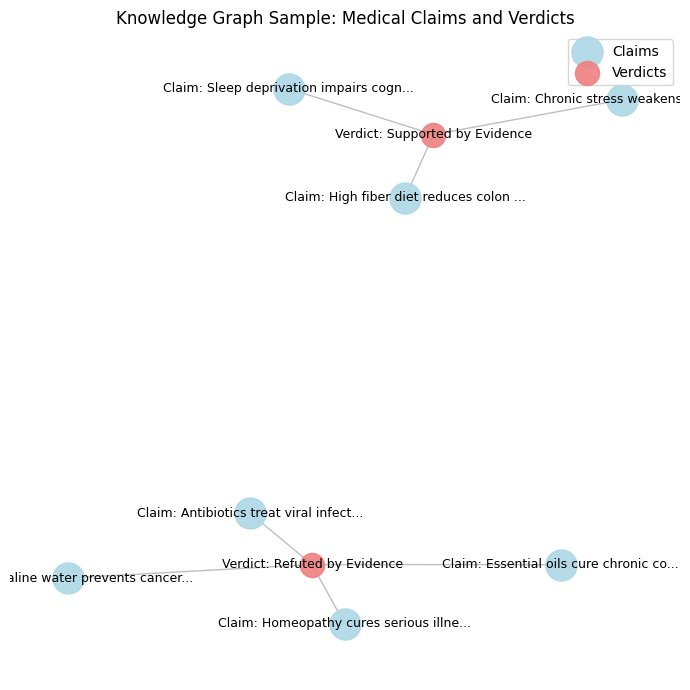

In [17]:
def plot_knowledge_graph_from_df(df, sample_size=20, figsize=(12, 10)):
    """
    Plots a simple knowledge graph representation of the medical fact-checking data.

    This procedure visualizes relationships between 'medical_claim' entities and
    'verdict_text' entities based on the data in the DataFrame.

    A Knowledge Graph typically consists of:
        - Entities (Nodes): Things like "Regular exercise reduces cardiovascular disease risk", "Supported by Evidence"
        - Relationships (Edges): Connections like "CLAIM_HAS_VERDICT"

    This example creates a basic visualization of these concepts derived from the DataFrame.

    Parameters:
    df (pd.DataFrame): The DataFrame containing 'medical_claim' and 'verdict_text' columns.
    sample_size (int, optional): Number of claims to sample for visualization to avoid clutter.
                                 Defaults to 20. If DataFrame has fewer rows, all are used.
    figsize (tuple, optional): Figure size (width, height). Defaults to (12, 10).

    Returns:
    None (displays the plot)
    """
    if df is None or df.empty:
        print("DataFrame is empty or None. Cannot plot knowledge graph.")
        return

    # Check if the expected columns exist
    if 'medical_claim' not in df.columns or 'verdict_text' not in df.columns:
        print("DataFrame does not contain required 'medical_claim' or 'verdict_text' column for KG visualization.")
        return

    # Sample the DataFrame to avoid an overly complex graph
    if len(df) > sample_size:
        df_sample = df.sample(n=sample_size, random_state=42) # Use random state for reproducibility
        print(f"Plotting a sample of {sample_size} claims for clarity.")
    else:
        df_sample = df
        print(f"Plotting all {len(df_sample)} claims.")

    try:
        # Create a NetworkX graph
        G = nx.Graph() # You might also use nx.DiGraph() for directed edges

        # Add nodes and edges based on the DataFrame sample
        for index, row in df_sample.iterrows():
            claim = row['medical_claim']
            verdict = row['verdict_text']

            # Add nodes for claim and verdict (if they don't already exist)
            # Using unique identifiers helps if claims/verdicts repeat or have similar names
            claim_node = f"Claim: {claim[:30]}..." if len(claim) > 30 else f"Claim: {claim}" # Truncate long claims for node label
            verdict_node = f"Verdict: {verdict}"

            G.add_node(claim_node, type='claim', full_text=claim) # Add attributes
            G.add_node(verdict_node, type='verdict')

            # Add an edge representing the relationship between claim and verdict
            # The edge label describes the relationship
            G.add_edge(claim_node, verdict_node, relationship="HAS_VERDICT")

        # --- Visualization ---
        plt.figure(figsize=figsize)

        # Determine node positions using a layout algorithm
        pos = nx.spring_layout(G, seed=42) # Seed for reproducible layout

        # Identify node types for different colors/styles
        claim_nodes = [node for node, attr in G.nodes(data=True) if attr.get('type') == 'claim']
        verdict_nodes = [node for node, attr in G.nodes(data=True) if attr.get('type') == 'verdict']

        # Draw nodes
        nx.draw_networkx_nodes(G, pos, nodelist=claim_nodes, node_color='lightblue', node_size=500, alpha=0.9, label='Claims')
        nx.draw_networkx_nodes(G, pos, nodelist=verdict_nodes, node_color='lightcoral', node_size=300, alpha=0.9, label='Verdicts')

        # Draw edges
        nx.draw_networkx_edges(G, pos, width=1.0, alpha=0.5, edge_color='gray')

        # Draw labels
        # For claims, we might want to show a bit more of the text or use tooltips (harder with matplotlib)
        # Here, we use the truncated labels already defined as node names
        nx.draw_networkx_labels(G, pos, font_size=9, font_family='sans-serif')

        # Draw edge labels (optional, can be cluttered)
        # edge_labels = nx.get_edge_attributes(G, 'relationship')
        # nx.draw_networkx_edge_labels(G, pos, edge_labels, font_size=6)

        plt.title("Knowledge Graph Sample: Medical Claims and Verdicts")
        plt.legend(scatterpoints=1) # Show legend for node types
        plt.axis('off') # Turn off axis
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"An error occurred while plotting the knowledge graph: {e}")

plot_knowledge_graph_from_df(df, sample_size=7, figsize=(7, 7))


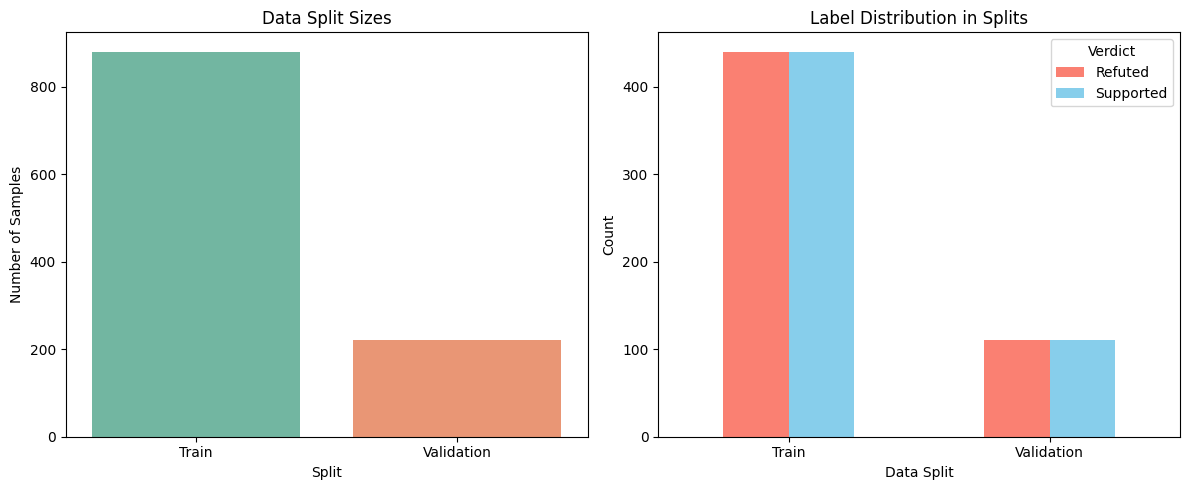

In [18]:
# 3. Prepare data for training
claims = df['medical_claim'].tolist()
evidences = df['evidence_text'].tolist()
labels = df['label'].tolist()

# Perform stratified split on the main data lists
train_claims, val_claims, train_evidences, val_evidences, train_labels, val_labels = train_test_split(
    claims, evidences, labels, test_size=0.2, random_state=42, stratify=labels
)

# Perform the same stratified split on indices to correctly map knowledge graphs
# This ensures alignment between the split data and the split knowledge graphs
train_indices, val_indices = train_test_split(
    range(len(claims)), test_size=0.2, random_state=42, stratify=labels
)

# --- Corrected Section: Accessing and Validating Knowledge Graphs from DataFrame ---
train_knowledge_graphs = []
val_knowledge_graphs = []
train_graph_data = [] # Initialize early
val_graph_data = []   # Initialize early

# Check if the column exists and process knowledge graphs only if GNN is intended to be used
if 'knowledge_graph' in df.columns:
    try:
        # Retrieve knowledge graph objects using the split indices
        # Option 1: List comprehension with .iloc
        train_knowledge_graphs = [df['knowledge_graph'].iloc[i] for i in train_indices]
        val_knowledge_graphs = [df['knowledge_graph'].iloc[i] for i in val_indices]

        # --- Crucial Validation Step ---
        # Check if the retrieved items are actually MedicalKnowledgeGraph objects
        # and have the required method. This prevents the 'str' object error.
        if train_knowledge_graphs and not all(hasattr(kg, 'build_torch_geometric_data') for kg in train_knowledge_graphs):
            logger.error("Train knowledge graphs contain invalid objects (e.g., strings). Skipping GNN processing for training data.")
            train_knowledge_graphs = [] # Invalidate the list
        if val_knowledge_graphs and not all(hasattr(kg, 'build_torch_geometric_data') for kg in val_knowledge_graphs):
            logger.error("Validation knowledge graphs contain invalid objects (e.g., strings). Skipping GNN processing for validation data.")
            val_knowledge_graphs = [] # Invalidate the list

        # Convert to PyTorch Geometric data only if validation passed
        if train_knowledge_graphs:
            train_graph_data = [kg.build_torch_geometric_data() for kg in train_knowledge_graphs]
        if val_knowledge_graphs:
             val_graph_data = [kg.build_torch_geometric_data() for kg in val_knowledge_graphs]

    except Exception as e:
        logger.error(f"Error processing knowledge graphs from DataFrame: {e}")
        # In case of any error during retrieval/conversion, ensure lists are empty
        train_knowledge_graphs = []
        val_knowledge_graphs = []
        train_graph_data = [] # Ensure these are also reset
        val_graph_data = []

else:
    # If the column doesn't exist (e.g., GNN was disabled earlier), use empty lists
    logger.info("Knowledge graph column not found in DataFrame. Proceeding without GNN data.")
    # train_knowledge_graphs, val_knowledge_graphs, train_graph_data, val_graph_data are already []

# --- End of Corrected Section ---

# --- Optional: Visualization of Data Split (unchanged) ---
if visualize:
    # Create a temporary DataFrame for visualization
    split_data = pd.DataFrame({
        'Split': ['Train'] * len(train_labels) + ['Validation'] * len(val_labels),
        'Label': train_labels + val_labels
    })
    label_names = {0: 'Refuted', 1: 'Supported'}
    split_data['Label_Name'] = split_data['Label'].map(label_names)

    # Plotting
    plt.figure(figsize=(12, 5))
    ax1 = plt.subplot(1, 2, 1)
    split_counts = split_data['Split'].value_counts()
    sns.barplot(x=split_counts.index, y=split_counts.values, palette='Set2', ax=ax1)
    ax1.set_title('Data Split Sizes')
    ax1.set_ylabel('Number of Samples')

    ax2 = plt.subplot(1, 2, 2)
    crosstab_df = pd.crosstab(split_data['Split'], split_data['Label_Name'])
    crosstab_df.plot(kind='bar', ax=ax2, color=['salmon', 'skyblue'])
    ax2.set_title('Label Distribution in Splits')
    ax2.set_xlabel('Data Split')
    ax2.set_ylabel('Count')
    ax2.legend(title='Verdict')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
    logger.info("Displayed data split visualization.")

# --- At this point, train_graph_data and val_graph_data are correctly populated lists ---
# (either with PyG Data objects if KGs were valid, or empty lists if not)
# The rest of your training loop can proceed, using these potentially empty lists
# to conditionally include GNN data in the model forward pass.

In [19]:
# --- Optional: Example of creating a DataFrame for split data including KGs ---
# If you needed a DataFrame representing the split data including the KG objects:
split_data_with_kg = pd.DataFrame({
     'Split': ['Train'] * len(train_labels) + ['Validation'] * len(val_labels),
     'Label': train_labels + val_labels,
     'Claim': train_claims + val_claims,
     'Evidence': train_evidences + val_evidences,
     # Accessing KGs using indices relative to the original df
     'Knowledge_Graph': [df['knowledge_graph'].iloc[i] for i in train_indices] +
                        [df['knowledge_graph'].iloc[i] for i in val_indices]
                        if 'knowledge_graph' in df.columns else [None] * (len(train_labels) + len(val_labels))
})
print(split_data_with_kg.head())

   Split  Label                                              Claim  \
0  Train      0  Eating carrots significantly improves night vi...   
1  Train      1          Vaccination prevents infectious diseases.   
2  Train      0  Eating carrots significantly improves night vi...   
3  Train      1   Sleep deprivation impairs cognitive performance.   
4  Train      0                Homeopathy cures serious illnesses.   

                                            Evidence  \
0  Epidemiological research and systematic review...   
1  Clinical studies and meta-analyses consistentl...   
2  Epidemiological research and systematic review...   
3  Clinical studies and meta-analyses consistentl...   
4  Epidemiological research and systematic review...   

                              Knowledge_Graph  
0   <MedicalKnowledgeGraph: 3 nodes, 4 edges>  
1  <MedicalKnowledgeGraph: 8 nodes, 18 edges>  
2   <MedicalKnowledgeGraph: 3 nodes, 4 edges>  
3  <MedicalKnowledgeGraph: 7 nodes, 16 edges>  
4 

# Graph visualization

🎨 Creating comprehensive visualization of all knowledge graphs...
  Creating comprehensive graph visualization...
Graph visualization saved to complete_knowledge_graph.png

📊 Graph Statistics:
  Nodes: 5991
  Edges: 13949
  Node Types: {'claim': 1100, 'evidence': 1100, 'paper': 3780, 'entity': 11}
  Relationship Types: {'related': 5980, 'mentions': 635, 'supports': 3780, 'cites': 2919, 'mentioned_in': 635}
  ✅ Complete knowledge graph visualization saved to complete_knowledge_graph.png


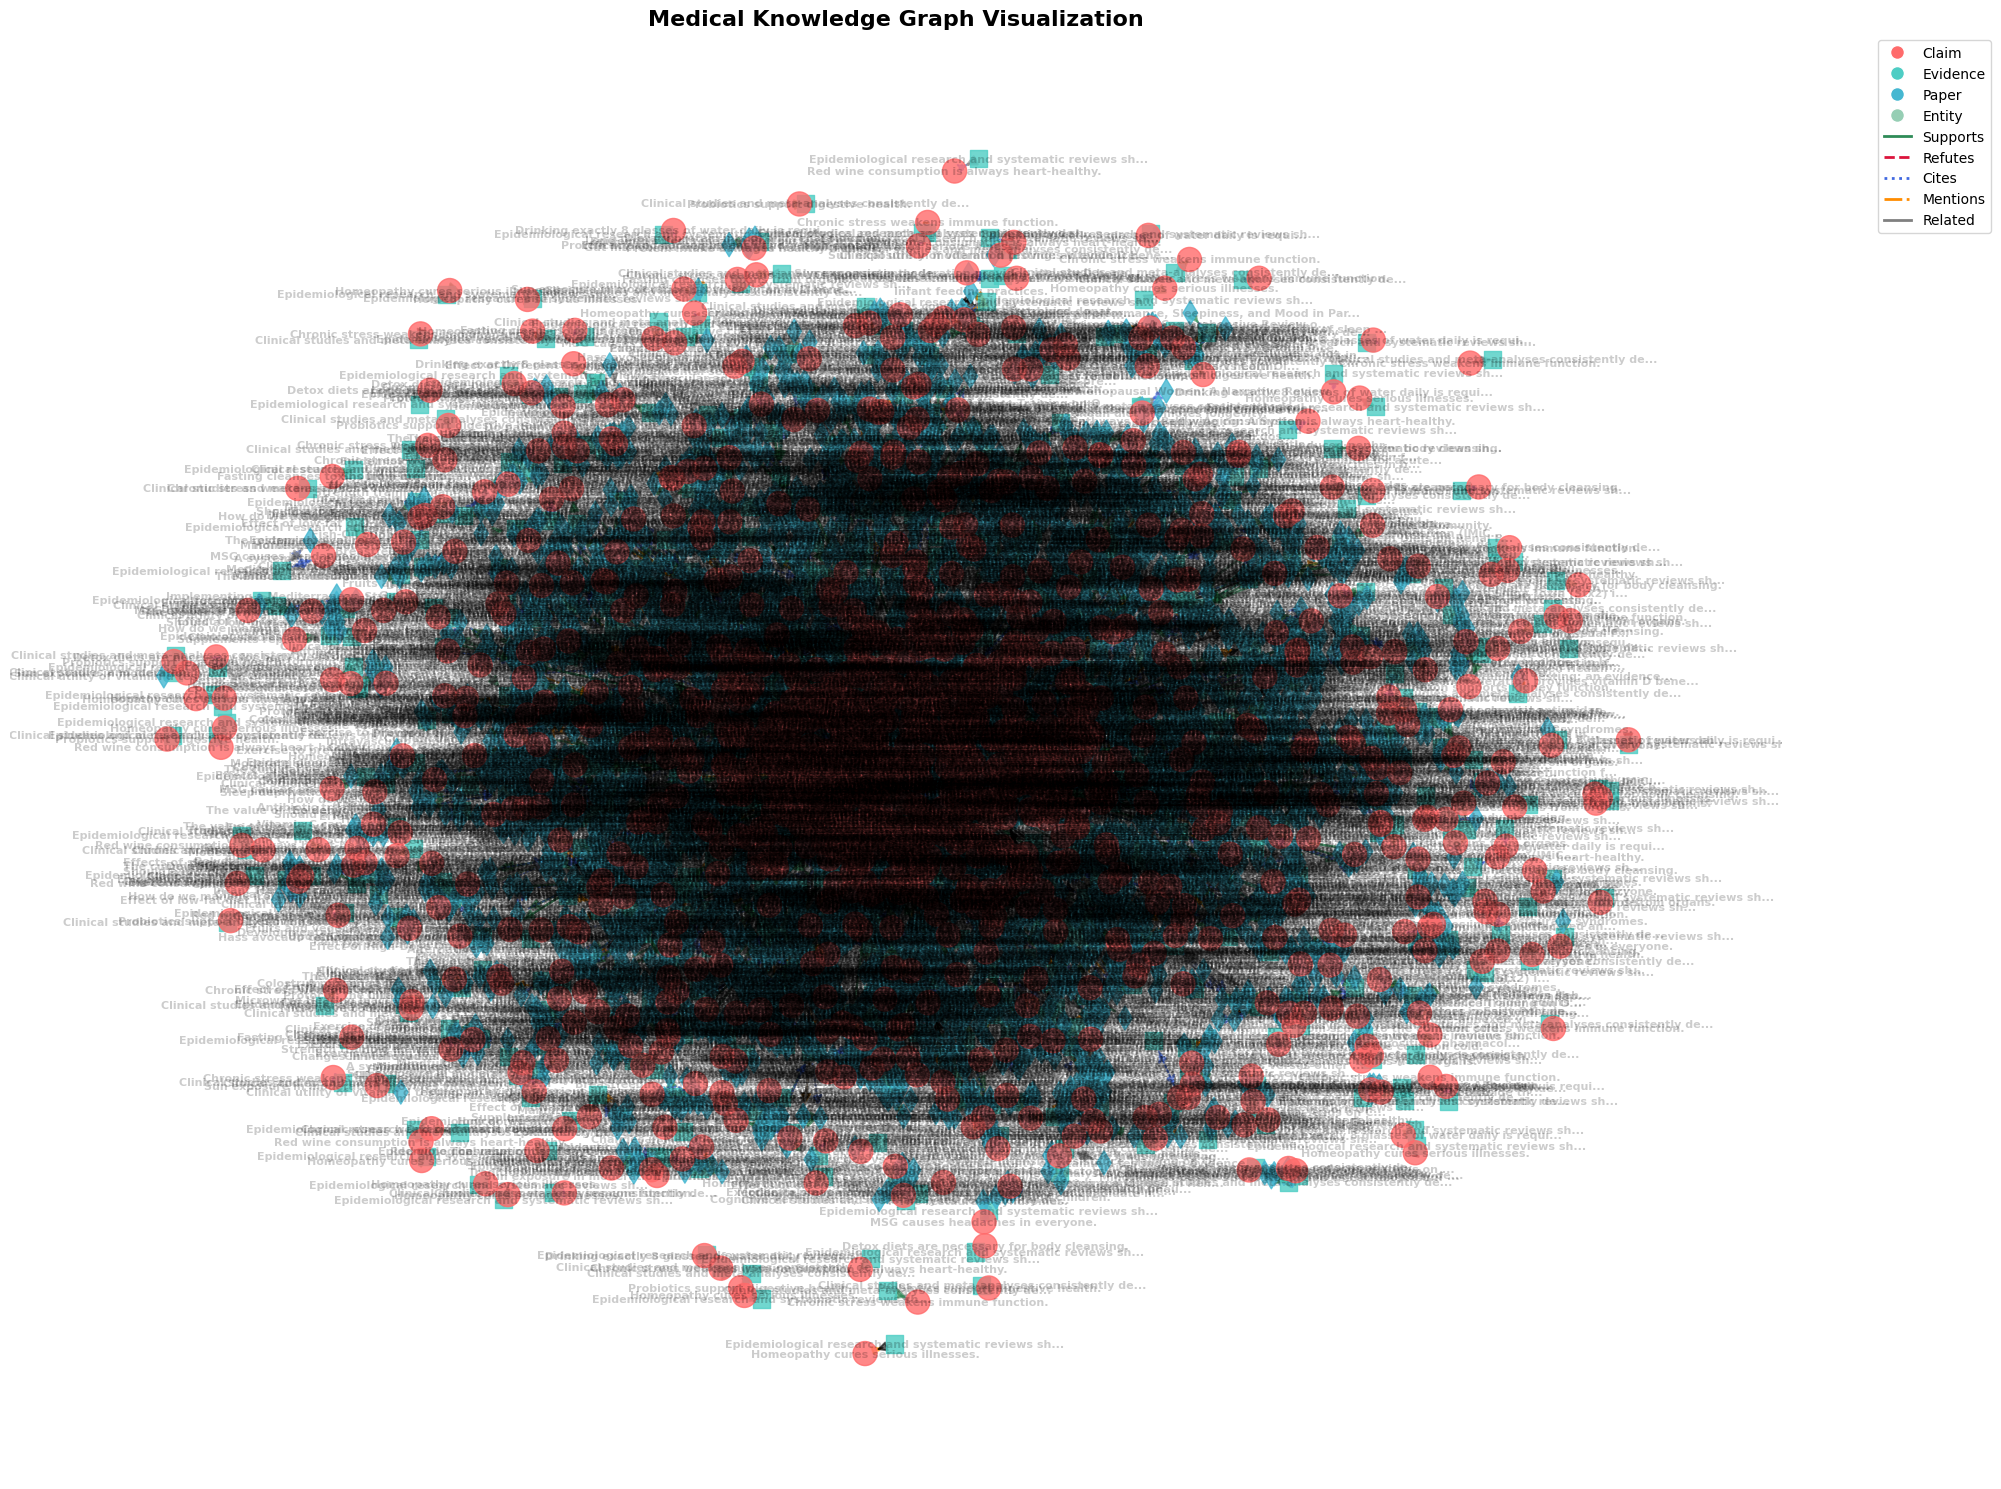

In [32]:
    # 2. Visualize all knowledge graphs combined
    if visualize and use_gnn and 'knowledge_graph' in df.columns and not df['knowledge_graph'].dropna().empty:
      unified_graph = visualize_all_graphs(df['knowledge_graph'].tolist(), save_path='complete_knowledge_graph.png', layout_algorithm='spring', alpha_labels=0.2)

🎨 Creating visualization of a sampled subset (150 nodes) of all knowledge graphs...
  - Sampled 150 unique node(s) for visualization.
  - Adding sampled nodes and their attributes...
  - Collecting edges between sampled nodes...
  - Adding 4 edge(s) between sampled nodes...
  - Creating sampled graph visualization using MedicalKnowledgeGraph.visualize_graph...
Graph visualization saved to sampled_knowledge_graph.png

📊 Graph Statistics:
  Nodes: 150
  Edges: 4
  Node Types: {'evidence': 20, 'paper': 97, 'claim': 33}
  Relationship Types: {'related': 1, 'supports': 1, 'cites': 2}
📊 Sampled Graph Visualization Statistics:
  - Nodes Visualized: 150
  - Edges Visualized: 4
  - Node Types: {'evidence': 20, 'paper': 97, 'claim': 33}
  - Relationship Types: {'related': 1, 'supports': 1, 'cites': 2}
✅ Sampled knowledge graph visualization saved to sampled_knowledge_graph.png


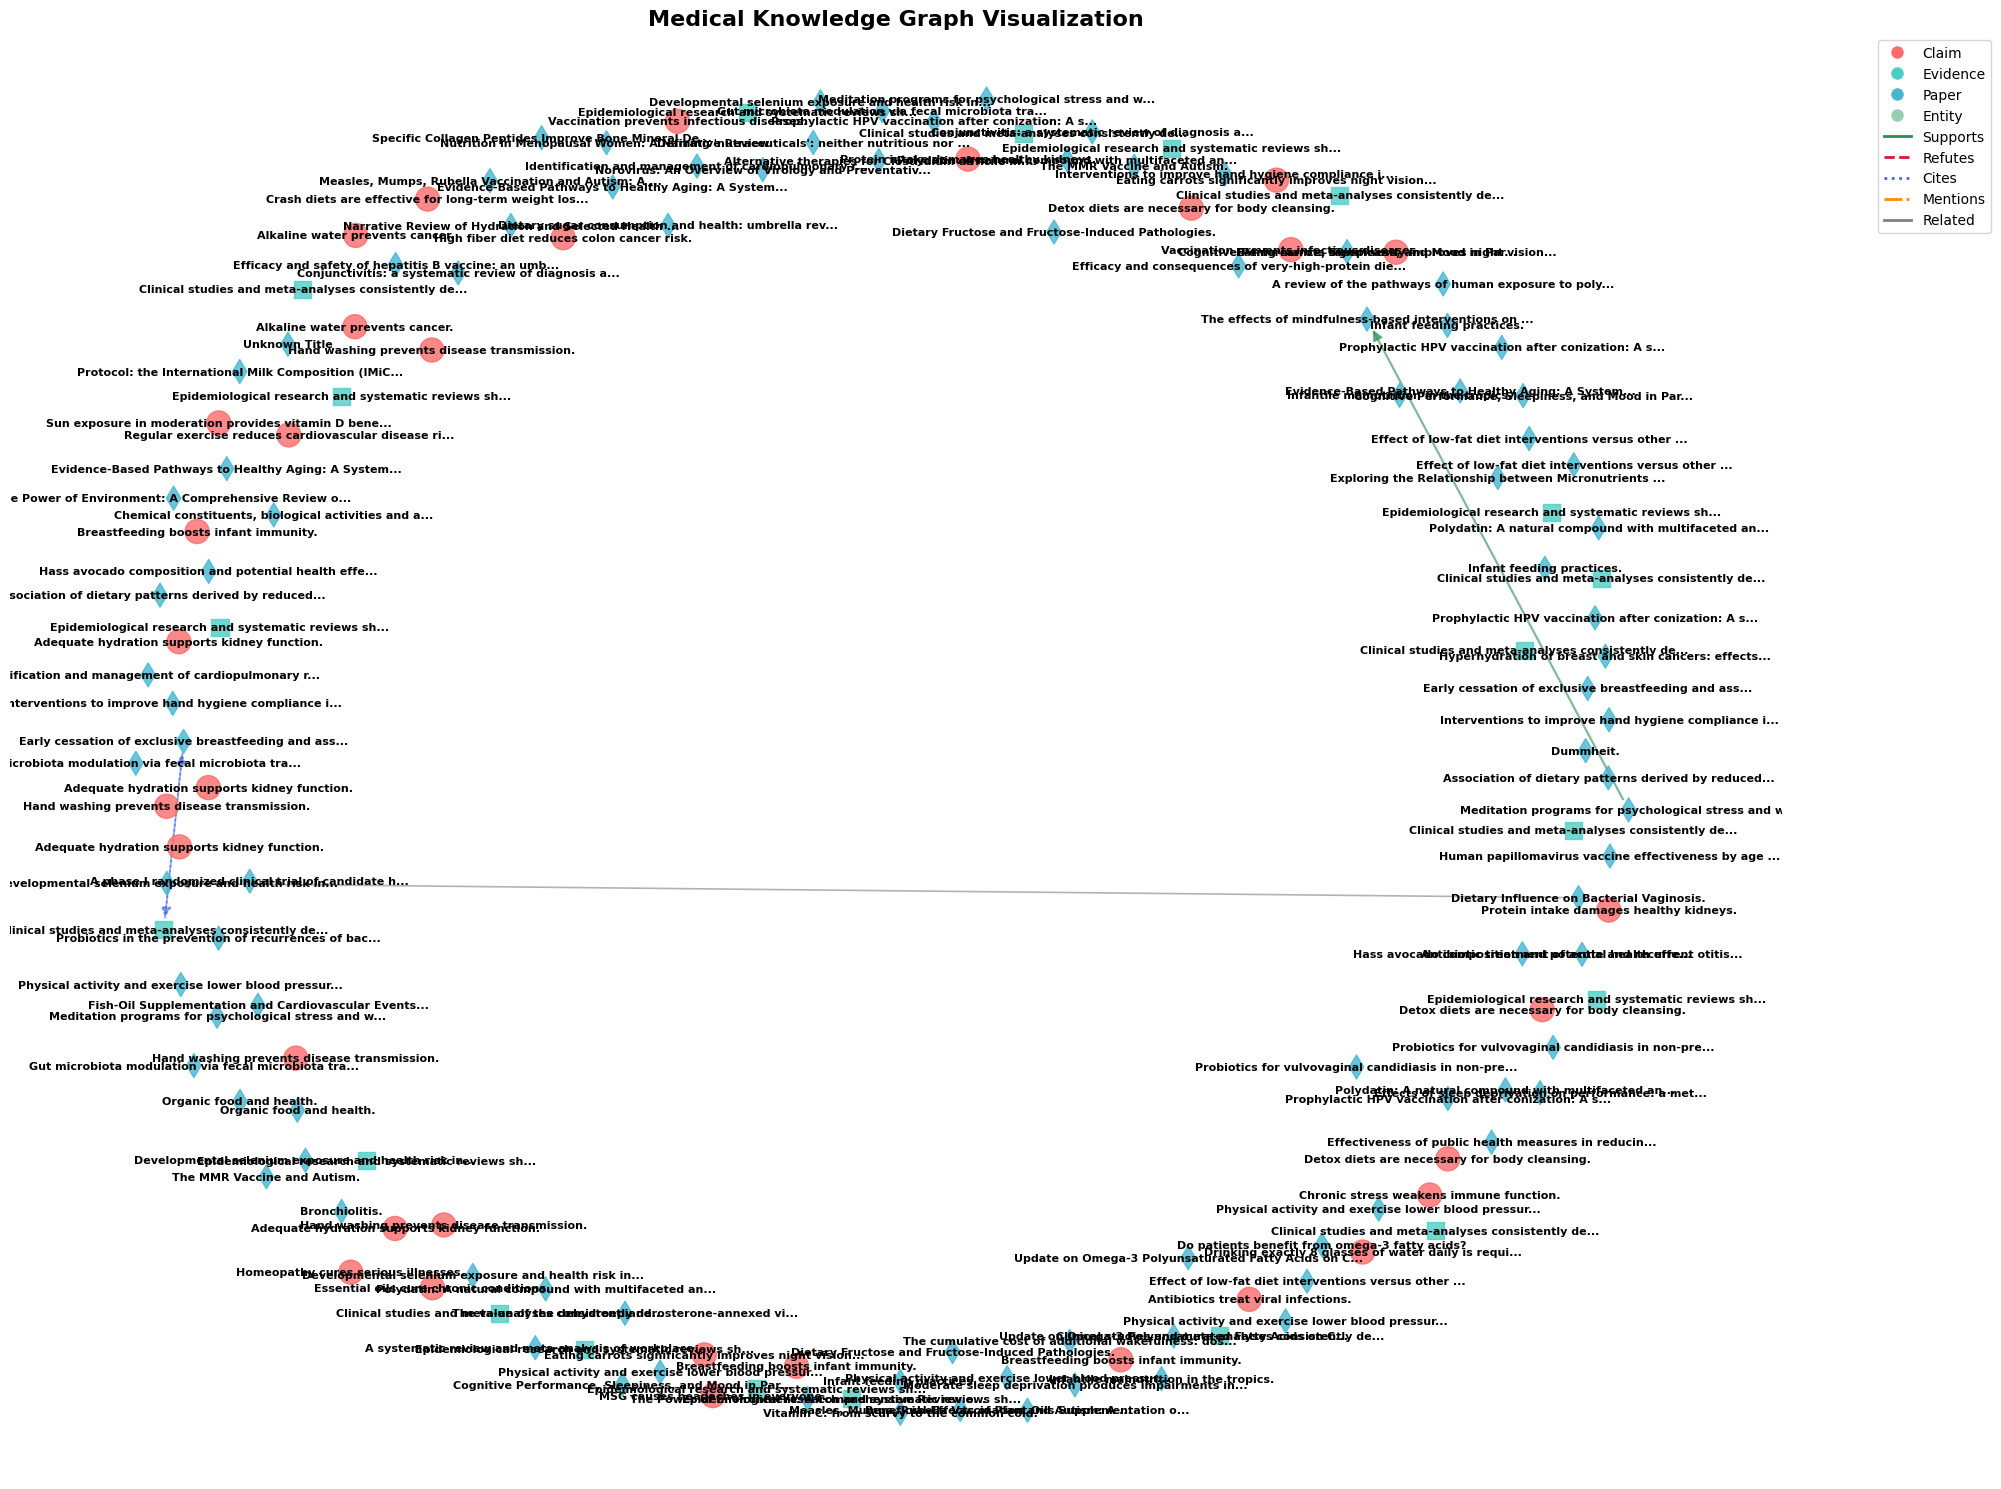

In [21]:
import random
import matplotlib.pyplot as plt
import networkx as nx
from collections import Counter

def visualize_sampled_graph(knowledge_graphs, num_nodes_to_sample=10, save_path='sampled_knowledge_graph.png'):
    """
    Visualize a sampled subset of nodes and their connecting edges from the combined knowledge graphs.

    This procedure combines node information from all individual knowledge graphs,
    randomly samples a specified number of unique nodes, collects all edges that
    exist between these sampled nodes across all graphs, and then creates a new
    temporary MedicalKnowledgeGraph object containing only this sampled data for visualization.

    Parameters:
    knowledge_graphs (list): A list of MedicalKnowledgeGraph objects.
    num_nodes_to_sample (int, optional): Number of unique nodes to randomly sample for visualization.
                                         Defaults to 10.
    save_path (str, optional): Path to save the visualization image.
                               Defaults to 'sampled_knowledge_graph.png'.

    Returns:
    networkx.DiGraph or None: The NetworkX graph object created for visualization by
                              the internal MedicalKnowledgeGraph's visualize_graph method,
                              or None if visualization failed or no graphs were provided.
    """
    if not knowledge_graphs:
        print("No knowledge graphs provided for visualization.")
        return None

    print(f"🎨 Creating visualization of a sampled subset ({num_nodes_to_sample} nodes) of all knowledge graphs...")

    # --- 1. Collect all unique nodes and their full information ---
    # Key: unique node name (e.g., 'claim_0', 'paper_123')
    # Value: tuple (node_type, metadata_dict, features_list)
    all_unique_nodes_info = {}

    for kg in knowledge_graphs:
        # Iterate through nodes in the current graph
        for node_name, node_type in zip(kg.nodes, kg.node_types):
            # Use node_name as the key to identify unique nodes across graphs
            if node_name not in all_unique_nodes_info:
                # Get metadata and features for this node
                metadata = kg.node_metadata.get(node_name, {})
                # Assuming node_features is index-aligned with nodes
                # Find the index of the node in kg.nodes to get corresponding features
                try:
                    node_index_in_kg = kg.nodes.index(node_name)
                    features = kg.node_features[node_index_in_kg] if node_index_in_kg < len(kg.node_features) else []
                except (ValueError, IndexError):
                    # Fallback if index alignment fails (shouldn't happen if internal structure is consistent)
                    features = []
                    print(f"Warning: Could not find features for node '{node_name}' in its original graph. Using empty features.")

                # Store the complete information needed to recreate the node
                all_unique_nodes_info[node_name] = (node_type, metadata, features)

    # --- 2. Sample nodes ---
    all_node_names = list(all_unique_nodes_info.keys())
    if not all_node_names:
         print("No nodes found in the provided knowledge graphs.")
         return None

    if len(all_node_names) < num_nodes_to_sample:
        print(f"Warning: Requested {num_nodes_to_sample} nodes, but only {len(all_node_names)} unique nodes available. Sampling all.")
        sampled_node_names = all_node_names
    else:
        sampled_node_names = random.sample(all_node_names, num_nodes_to_sample)
    print(f"  - Sampled {len(sampled_node_names)} unique node(s) for visualization.")

    sampled_node_set = set(sampled_node_names) # For faster lookup of sampled nodes

    # --- 3. Create a new MedicalKnowledgeGraph instance for the sampled data ---
    sampled_kg = MedicalKnowledgeGraph() # Create an empty graph instance
    node_name_to_new_id = {} # Map original sampled node names to their new IDs in sampled_kg

    # --- 4. Add sampled nodes and their attributes to the new graph ---
    print("  - Adding sampled nodes and their attributes...")
    for original_node_name in sampled_node_names:
        node_type, metadata, features = all_unique_nodes_info[original_node_name]

        # Add the node using the original graph's methods to ensure consistency
        # This correctly populates sampled_kg.nodes, sampled_kg.node_types,
        # sampled_kg.node_labels, sampled_kg.node_metadata, and sampled_kg.node_id_map
        if node_type == 'claim':
            # Use full text and ID from metadata
            node_id_new = sampled_kg.add_claim_node(
                metadata.get('full_text', f"Unknown Claim ({original_node_name})"),
                metadata.get('id', original_node_name)
            )
        elif node_type == 'evidence':
            node_id_new = sampled_kg.add_evidence_node(
                metadata.get('full_text', f"Unknown Evidence ({original_node_name})"),
                metadata.get('id', original_node_name)
            )
        elif node_type == 'paper':
            # Pass the whole metadata dict and ID
             # Ensure metadata has an 'id', fallback if missing
            paper_id = metadata.get('id', original_node_name)
            # Temporarily update metadata with the correct ID for add_paper_node
            temp_metadata = metadata.copy()
            temp_metadata['id'] = paper_id
            node_id_new = sampled_kg.add_paper_node(temp_metadata, paper_id)
        elif node_type == 'entity':
            node_id_new = sampled_kg.add_entity_node(
                metadata.get('name', f"Unknown Entity ({original_node_name})"),
                metadata.get('entity_type', 'UnknownType')
            )
        else:
            # Handle any unforeseen node types by adding a generic node
            # This mimics part of the original add_*_node logic
            node_id_new = len(sampled_kg.nodes)
            sampled_kg.nodes.append(original_node_name)
            sampled_kg.node_types.append(node_type)
            # Create a label, possibly truncating
            label_text = metadata.get('name', metadata.get('full_text', original_node_name))
            sampled_kg.node_labels[original_node_name] = label_text[:50] + ("..." if len(label_text) > 50 else "")
            sampled_kg.node_metadata[original_node_name] = metadata
            sampled_kg.node_features.append(features) # Use the sampled features
            sampled_kg.node_id_map[original_node_name] = node_id_new
            print(f"Warning: Added node '{original_node_name}' of unknown type '{node_type}' generically.")


        # Record the mapping from the original node name to its new ID in sampled_kg
        node_name_to_new_id[original_node_name] = node_id_new

    # --- 5. Collect edges that exist between the sampled nodes ---
    print("  - Collecting edges between sampled nodes...")
    sampled_edges_info = [] # Store tuples (new_source_id, new_target_id, relation, weight)

    for kg in knowledge_graphs:
        # Iterate through edges in the current graph
        for source_id_old, target_id_old, relation, weight in kg.edges:
            # Get the original node names for source and target in this graph
            # Add bounds checking
            if source_id_old >= len(kg.nodes) or target_id_old >= len(kg.nodes):
                 print(f"Warning: Skipping edge with invalid node index (source: {source_id_old}, target: {target_id_old}).")
                 continue

            source_name = kg.nodes[source_id_old]
            target_name = kg.nodes[target_id_old]

            # Check if both the source and target of this edge were in our sampled set
            if source_name in sampled_node_set and target_name in sampled_node_set:
                # Get the *new* IDs for these nodes within the sampled_kg
                new_source_id = node_name_to_new_id.get(source_name)
                new_target_id = node_name_to_new_id.get(target_name)

                # Ensure mapping exists (should always be true if logic above is correct)
                if new_source_id is not None and new_target_id is not None:
                    # Add the edge information using the new IDs
                    # Store as tuple to add to sampled_kg later
                    sampled_edges_info.append((new_source_id, new_target_id, relation, weight))
                # else: This case should ideally not happen, log if it does
                #     print(f"Warning: Node mapping not found for edge {source_name}->{target_name} during edge collection.")

    # --- 6. Add collected sampled edges to the new graph ---
    print(f"  - Adding {len(sampled_edges_info)} edge(s) between sampled nodes...")
    for new_source_id, new_target_id, relation, weight in sampled_edges_info:
         # Add the edge directly to the sampled_kg's internal structures
         # This mimics the original add_edge method
         sampled_kg.edges.append((new_source_id, new_target_id, relation, weight))
         # Note: The original add_edge doesn't update other structures like an edge map,
         # so just appending to sampled_kg.edges is sufficient based on the provided code.

    # --- 7. Visualize the sampled graph using the existing method ---
    try:
        print("  - Creating sampled graph visualization using MedicalKnowledgeGraph.visualize_graph...")
        # Call the existing visualize_graph method on the newly created sampled_kg instance
        # Pass save_path to save the figure. show_all=True is appropriate for the sampled graph.
        graph_nx = sampled_kg.visualize_graph(show_all=True, save_path=save_path)

        if graph_nx:
            # --- Optional: Print statistics for the *sampled* portion visualized ---
            # Recreate stats similar to visualize_all_graphs
            print(f"📊 Sampled Graph Visualization Statistics:")
            print(f"  - Nodes Visualized: {graph_nx.number_of_nodes()}")
            print(f"  - Edges Visualized: {graph_nx.number_of_edges()}")
            # Calculate node types from the NetworkX graph attributes
            nx_node_types = [data.get('type', 'unknown') for _, data in graph_nx.nodes(data=True)]
            if nx_node_types:
                print(f"  - Node Types: {dict(Counter(nx_node_types))}")
            # Calculate edge relations from the NetworkX graph attributes
            nx_edge_relations = [data.get('relation', 'unknown') for _, _, data in graph_nx.edges(data=True)]
            if nx_edge_relations:
                print(f"  - Relationship Types: {dict(Counter(nx_edge_relations))}")

            print(f"✅ Sampled knowledge graph visualization saved to {save_path}")
            return graph_nx
        else:
            print(f"❌ Failed to create NetworkX graph for visualization (visualize_graph returned None).")
            return None

    except Exception as e:
        print(f"❌ Failed to create sampled visualization: {e}")
        import traceback
        traceback.print_exc() # Print full traceback for debugging
        return None

# --- How to use it in train_and_evaluate_medical_baseline ---
# Inside the train_and_evaluate_medical_baseline function, find the section:
# if visualize and use_gnn and knowledge_graphs:
#     unified_graph = visualize_all_graphs(knowledge_graphs, save_path='complete_knowledge_graph.png')
#
# You can replace it with or add the sampled version:
# if visualize and use_gnn and knowledge_graphs:
#     # Original full visualization (might be slow/cluttered)
#     # unified_graph = visualize_all_graphs(knowledge_graphs, save_path='complete_knowledge_graph.png')
#     # Sampled visualization

sampled_graph_nx = visualize_sampled_graph(df['knowledge_graph'].tolist(), num_nodes_to_sample=150, save_path='sampled_knowledge_graph.png')


# LLM load

In [34]:
model_name='roberta-base'
# 4. Load tokenizer and RoBERTa model using HF_TOKEN
logger.info(f"Loading tokenizer and model '{model_name}' from Hugging Face...")

# Pass the token when loading from_pretrained
tokenizer_kwargs = {"token": HF_TOKEN} if HF_TOKEN else {}
model_kwargs = {"token": HF_TOKEN} if HF_TOKEN else {}

tokenizer = RobertaTokenizer.from_pretrained(model_name, **tokenizer_kwargs)
roberta_model = RobertaModel.from_pretrained(model_name, **model_kwargs)
logger.info("Tokenizer and RoBERTa model loaded successfully.")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [35]:
gnn_model = GNNFactChecker(num_node_features=3, hidden_dim=64, num_classes=2)
hybrid_model = HybridFactChecker(roberta_model, gnn_model)


    # 6. Create datasets and dataloaders
train_dataset = MedicalFactCheckingDataset(train_claims, train_evidences, train_labels, tokenizer)
val_dataset = MedicalFactCheckingDataset(val_claims, val_evidences, val_labels, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [36]:

    # 7. Setup training
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    hybrid_model.to(device)
    optimizer = AdamW(hybrid_model.parameters(), lr=learning_rate)

    # Store metrics for each epoch
    epoch_metrics = {
        'train_loss': [],
        'val_loss': [],
        'val_accuracy': [],
        'val_precision': [],
        'val_recall': [],
        'val_f1': []
    }

    # 8. Training loop with epoch-by-epoch results
    logger.info("Starting training loop...")
    for epoch in range(epochs):
        print(f"\n{'='*60}")
        print(f"Epoch {epoch + 1}/{epochs}")
        print(f"{'='*60}")

        # Training phase
        hybrid_model.train()
        total_train_loss = 0
        train_steps = 0

        for batch_idx, batch in enumerate(train_loader):
            optimizer.zero_grad()

            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels_batch = batch['labels'].to(device)

            # Forward pass (simplified - in practice, handle graph data properly)
            if use_gnn:
                # This is a simplified approach - in practice, you'd batch graph data properly
                roberta_outputs = hybrid_model.roberta(input_ids=input_ids, attention_mask=attention_mask)
                outputs = roberta_outputs.last_hidden_state[:, 0, :]  # CLS token
                # Add simple classification head
                classifier = nn.Linear(outputs.size(-1), 2).to(device)
                outputs = classifier(outputs)
            else:
                # RoBERTa-only forward pass
                roberta_outputs = hybrid_model(input_ids=input_ids, attention_mask=attention_mask)
                outputs = roberta_outputs.last_hidden_state[:, 0, :]  # CLS token
                # Add simple classification head for RoBERTa-only
                classifier = nn.Linear(outputs.size(-1), 2).to(device)
                outputs = classifier(outputs)

            # Compute loss
            if len(outputs.shape) == 1:
                outputs = outputs.unsqueeze(0)
            loss = F.cross_entropy(outputs, labels_batch)
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()
            train_steps += 1

            if batch_idx % 2 == 0:  # Print every 2 batches
                print(f"  Batch {batch_idx}: Train Loss = {loss.item():.4f}")

        avg_train_loss = total_train_loss / train_steps if train_steps > 0 else 0
        epoch_metrics['train_loss'].append(avg_train_loss)

        # Validation phase
        hybrid_model.eval()
        total_val_loss = 0
        val_predictions = []
        val_true_labels = []
        val_steps = 0

        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels_batch = batch['labels'].to(device)

                # Forward pass
                if use_gnn:
                    roberta_outputs = hybrid_model.roberta(input_ids=input_ids, attention_mask=attention_mask)
                    outputs = roberta_outputs.last_hidden_state[:, 0, :]
                    classifier = nn.Linear(outputs.size(-1), 2).to(device)
                    outputs = classifier(outputs)
                else:
                    roberta_outputs = hybrid_model(input_ids=input_ids, attention_mask=attention_mask)
                    outputs = roberta_outputs.last_hidden_state[:, 0, :]
                    classifier = nn.Linear(outputs.size(-1), 2).to(device)
                    outputs = classifier(outputs)

                if len(outputs.shape) == 1:
                    outputs = outputs.unsqueeze(0)

                loss = F.cross_entropy(outputs, labels_batch)
                logits = outputs

                total_val_loss += loss.item()
                val_steps += 1

                predictions = torch.argmax(logits, dim=-1)
                val_predictions.extend(predictions.cpu().numpy())
                val_true_labels.extend(labels_batch.cpu().numpy())

        avg_val_loss = total_val_loss / val_steps if val_steps > 0 else 0
        accuracy = accuracy_score(val_true_labels, val_predictions) if val_true_labels and val_predictions else 0
        if val_true_labels and val_predictions:
            precision, recall, f1, _ = precision_recall_fscore_support(val_true_labels, val_predictions, average='weighted')
        else:
            precision = recall = f1 = 0

        # Store metrics
        epoch_metrics['val_loss'].append(avg_val_loss)
        epoch_metrics['val_accuracy'].append(accuracy)
        epoch_metrics['val_precision'].append(precision)
        epoch_metrics['val_recall'].append(recall)
        epoch_metrics['val_f1'].append(f1)

        # Print epoch results
        print(f"\nEpoch {epoch + 1} Results:")
        print(f"  Average Train Loss: {avg_train_loss:.4f}")
        print(f"  Average Val Loss: {avg_val_loss:.4f}")
        print(f"  Validation Accuracy: {accuracy:.4f}")
        print(f"  Validation Precision: {precision:.4f}")
        print(f"  Validation Recall: {recall:.4f}")
        print(f"  Validation F1-Score: {f1:.4f}")

        # Confusion matrix for current epoch
        if val_true_labels and val_predictions:
            cm = confusion_matrix(val_true_labels, val_predictions)
            print(f"  Confusion Matrix: {cm.flatten()}")



Epoch 1/25
  Batch 0: Train Loss = 0.6942
  Batch 2: Train Loss = 0.7243
  Batch 4: Train Loss = 0.8285
  Batch 6: Train Loss = 0.7388
  Batch 8: Train Loss = 0.7188
  Batch 10: Train Loss = 0.6969
  Batch 12: Train Loss = 0.6966
  Batch 14: Train Loss = 0.7018
  Batch 16: Train Loss = 0.7234
  Batch 18: Train Loss = 0.6842
  Batch 20: Train Loss = 0.7202
  Batch 22: Train Loss = 0.7028
  Batch 24: Train Loss = 0.7241
  Batch 26: Train Loss = 0.7033

Epoch 1 Results:
  Average Train Loss: 0.7102
  Average Val Loss: 0.6806
  Validation Accuracy: 0.5636
  Validation Precision: 0.5771
  Validation Recall: 0.5636
  Validation F1-Score: 0.5437
  Confusion Matrix: [39 71 25 85]

Epoch 2/25
  Batch 0: Train Loss = 0.7590
  Batch 2: Train Loss = 0.7981
  Batch 4: Train Loss = 0.6887
  Batch 6: Train Loss = 0.7138
  Batch 8: Train Loss = 0.6415
  Batch 10: Train Loss = 0.6706
  Batch 12: Train Loss = 0.7480
  Batch 14: Train Loss = 0.6915
  Batch 16: Train Loss = 0.7125
  Batch 18: Train Loss 


FINAL MODEL PERFORMANCE
Final Accuracy: 0.4091
Final F1-Score: 0.4067


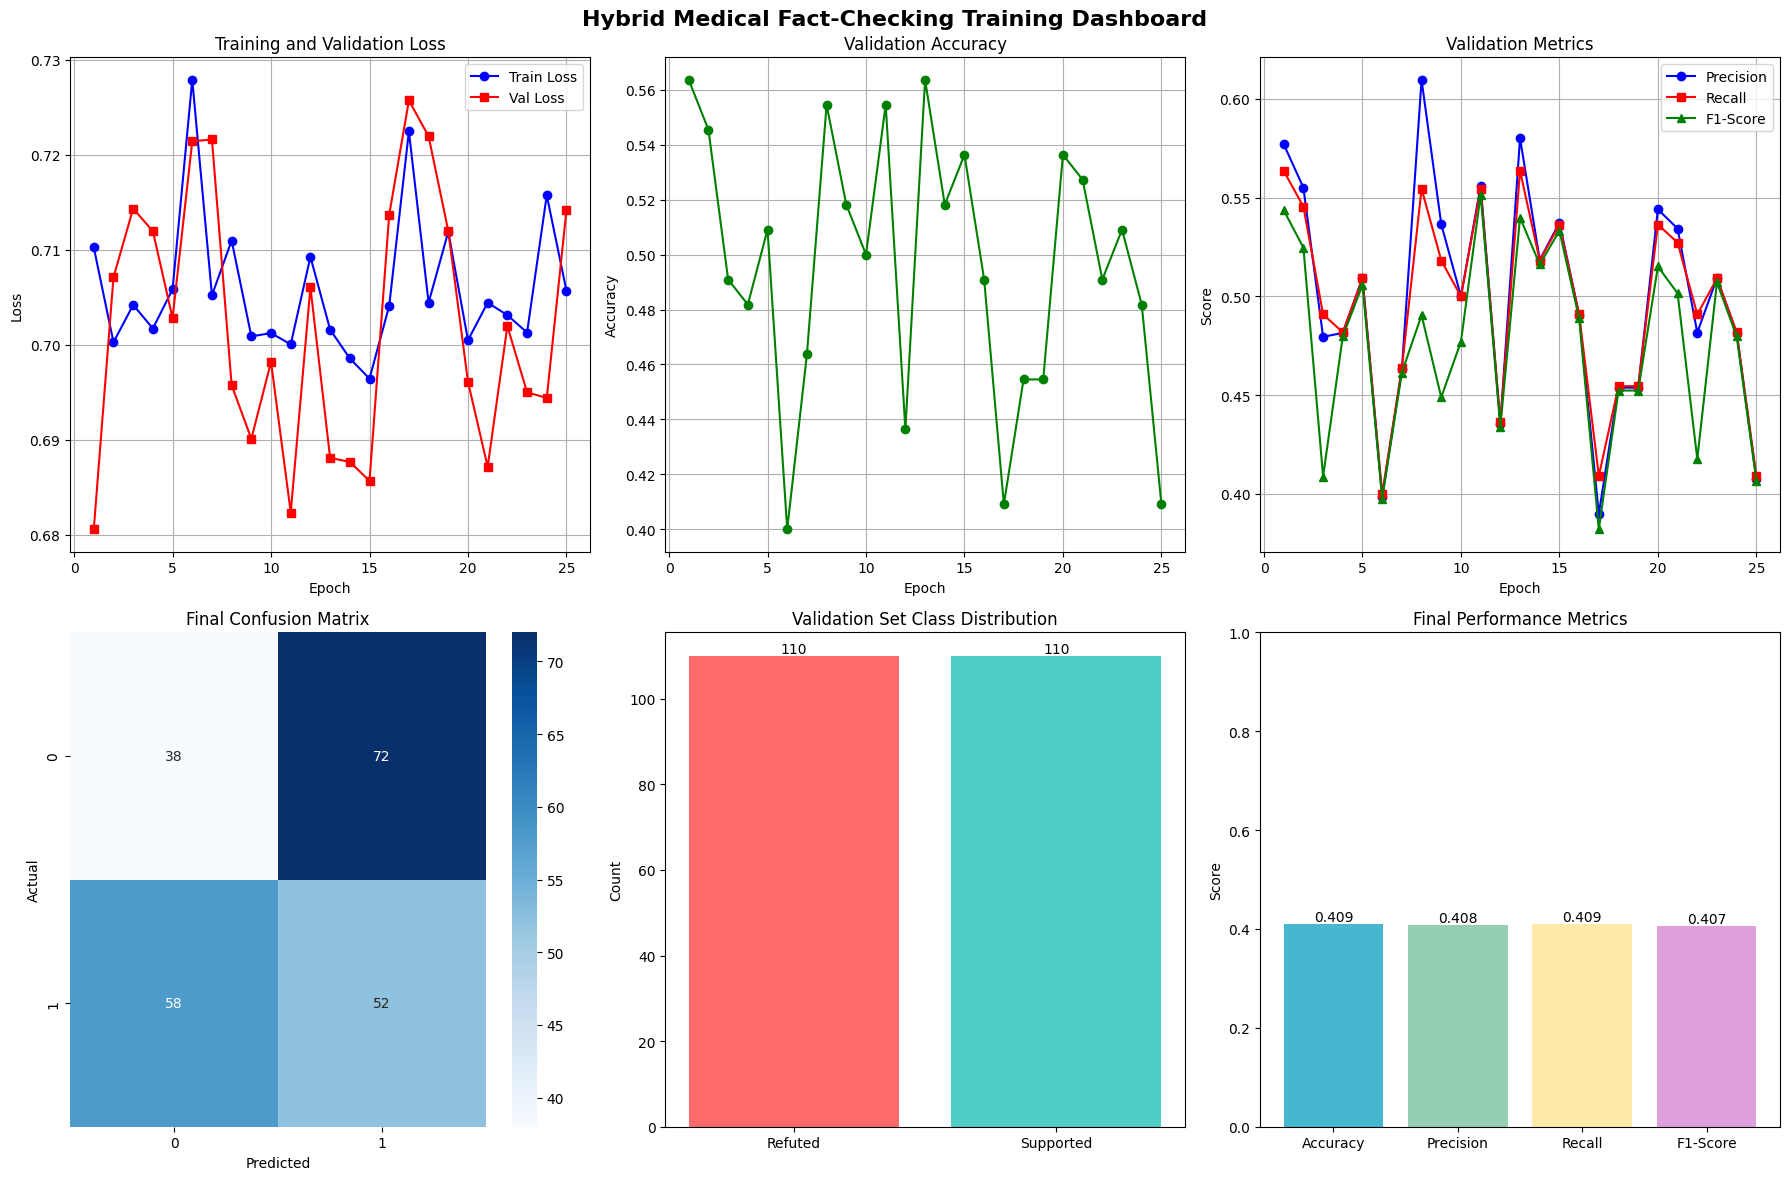


📊 TRAINING SUMMARY
Model Configuration:
  Base Model: roberta-base
  Epochs: 25
  Batch Size: 32
  Learning Rate: 0.0002
  Device: cuda
  PubMed Integration: Enabled
  GNN Integration: Enabled

Dataset Information:
  Total Samples: 1100
  Supported Claims: 550 (50.0%)
  Refuted Claims: 550 (50.0%)

Performance Metrics:
  Final Accuracy: 0.4091
  Final Precision: 0.4076
  Final Recall: 0.4091
  Final F1-Score: 0.4067
  Best Accuracy: 0.5636
  Best F1-Score: 0.5515


In [37]:

    # 9. Final evaluation and visualization
    final_accuracy = epoch_metrics['val_accuracy'][-1] if epoch_metrics['val_accuracy'] else 0
    final_f1 = epoch_metrics['val_f1'][-1] if epoch_metrics['val_f1'] else 0

    print(f"\n{'='*60}")
    print("FINAL MODEL PERFORMANCE")
    print(f"{'='*60}")
    print(f"Final Accuracy: {final_accuracy:.4f}")
    print(f"Final F1-Score: {final_f1:.4f}")

    # Create comprehensive visualization dashboard
    if visualize:
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        fig.suptitle('Hybrid Medical Fact-Checking Training Dashboard', fontsize=16, fontweight='bold')

        # 1. Training and Validation Loss
        axes[0, 0].plot(range(1, len(epoch_metrics['train_loss']) + 1), epoch_metrics['train_loss'], 'b-', marker='o', label='Train Loss')
        axes[0, 0].plot(range(1, len(epoch_metrics['val_loss']) + 1), epoch_metrics['val_loss'], 'r-', marker='s', label='Val Loss')
        axes[0, 0].set_title('Training and Validation Loss')
        axes[0, 0].set_xlabel('Epoch')
        axes[0, 0].set_ylabel('Loss')
        axes[0, 0].legend()
        axes[0, 0].grid(True)

        # 2. Accuracy over epochs
        axes[0, 1].plot(range(1, len(epoch_metrics['val_accuracy']) + 1), epoch_metrics['val_accuracy'], 'g-', marker='o')
        axes[0, 1].set_title('Validation Accuracy')
        axes[0, 1].set_xlabel('Epoch')
        axes[0, 1].set_ylabel('Accuracy')
        axes[0, 1].grid(True)

        # 3. Precision, Recall, F1 over epochs
        axes[0, 2].plot(range(1, len(epoch_metrics['val_precision']) + 1), epoch_metrics['val_precision'], 'b-', marker='o', label='Precision')
        axes[0, 2].plot(range(1, len(epoch_metrics['val_recall']) + 1), epoch_metrics['val_recall'], 'r-', marker='s', label='Recall')
        axes[0, 2].plot(range(1, len(epoch_metrics['val_f1']) + 1), epoch_metrics['val_f1'], 'g-', marker='^', label='F1-Score')
        axes[0, 2].set_title('Validation Metrics')
        axes[0, 2].set_xlabel('Epoch')
        axes[0, 2].set_ylabel('Score')
        axes[0, 2].legend()
        axes[0, 2].grid(True)

        # 4. Final confusion matrix
        if val_true_labels and val_predictions:
            final_cm = confusion_matrix(val_true_labels, val_predictions)
            sns.heatmap(final_cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0])
            axes[1, 0].set_title('Final Confusion Matrix')
            axes[1, 0].set_xlabel('Predicted')
            axes[1, 0].set_ylabel('Actual')

        # 5. Class distribution in validation set
        val_label_counts = Counter(val_true_labels)
        class_names = ['Refuted', 'Supported']
        class_counts = [val_label_counts[0], val_label_counts[1]] if val_true_labels else [0, 0]

        # Fix deprecation warning for palette
        bars = axes[1, 1].bar(class_names, class_counts, color=['#FF6B6B', '#4ECDC4'])
        axes[1, 1].set_title('Validation Set Class Distribution')
        axes[1, 1].set_ylabel('Count')
        axes[1, 1].bar_label(bars)

        # 6. Performance metrics comparison
        #best_metrix_idx = np.argmax(epoch_metrics['val_f1'])
        best_metrix_idx = -1

        final_metrics = [epoch_metrics['val_accuracy'][best_metrix_idx],
                        epoch_metrics['val_precision'][best_metrix_idx] if epoch_metrics['val_precision'] else 0,
                        epoch_metrics['val_recall'][best_metrix_idx] if epoch_metrics['val_recall'] else 0,
                        epoch_metrics['val_f1'][best_metrix_idx]]
        metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

        # Fix deprecation warning for palette
        bars = axes[1, 2].bar(metric_names, final_metrics, color=['#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD'])
        axes[1, 2].set_title('Final Performance Metrics')
        axes[1, 2].set_ylabel('Score')
        axes[1, 2].set_ylim(0, 1)
        axes[1, 2].bar_label(bars, fmt='%.3f')

        plt.tight_layout()
        plt.savefig('training_dashboard.png', dpi=300, bbox_inches='tight')
        plt.show()

    # Print detailed summary
    print(f"\n{'='*60}")
    print("📊 TRAINING SUMMARY")
    print(f"{'='*60}")
    print(f"Model Configuration:")
    print(f"  Base Model: {model_name}")
    print(f"  Epochs: {epochs}")
    print(f"  Batch Size: {batch_size}")
    print(f"  Learning Rate: {learning_rate}")
    print(f"  Device: {device}")
    print(f"  PubMed Integration: {'Enabled' if use_pubmed else 'Disabled'}")
    print(f"  GNN Integration: {'Enabled' if use_gnn else 'Disabled'}")
    print(f"\nDataset Information:")
    print(f"  Total Samples: {len(labels)}")
    print(f"  Supported Claims: {sum(labels)} ({sum(labels)/len(labels)*100:.1f}%)")
    print(f"  Refuted Claims: {len(labels) - sum(labels)} ({(len(labels) - sum(labels))/len(labels)*100:.1f}%)")
    print(f"\nPerformance Metrics:")
    print(f"  Final Accuracy: {final_accuracy:.4f}")
    print(f"  Final Precision: {epoch_metrics['val_precision'][-1] if epoch_metrics['val_precision'] else 0:.4f}")
    print(f"  Final Recall: {epoch_metrics['val_recall'][-1] if epoch_metrics['val_recall'] else 0:.4f}")
    print(f"  Final F1-Score: {final_f1:.4f}")
    if epoch_metrics['val_accuracy']:
        print(f"  Best Accuracy: {max(epoch_metrics['val_accuracy']):.4f}")
    if epoch_metrics['val_f1']:
        print(f"  Best F1-Score: {max(epoch_metrics['val_f1']):.4f}")


# let's check user claim

In [38]:
    hybrid_model.roberta.eval()
    # Note: If your hybrid_model has other components (like a GNN), make sure they are also in eval mode
    # e.g., if hasattr(hybrid_model, 'gnn_component'): hybrid_model.gnn_component.eval()

    # Define the simple classifier head used during training/inference (ensure it matches training)
    # As the model is re-loaded or this code might run in a new context, we need to define this layer.
    # IMPORTANT: This `classifier` definition must exactly match the one used during training.
    # If it was part of a class definition or saved/loaded differently, adjust accordingly.
    # Using a placeholder dimension; it will be set correctly on the first forward pass.
    dummy_classifier = None
    user_claim = 'Vitamin C is a good for Immunitate'

In [39]:

            print(f"\n--- Analyzing Claim: just Roberta model '{user_claim[:50]}...' ---")

            # --- Simulate evidence generation and literature search ---
            # In a real scenario, this would involve a proper evidence retrieval system.
            # Here, we simulate a basic evidence text and a PubMed search.
            simulated_evidence = f"Simulated evidence for: {user_claim[:30]}..."

            # Use the notebook's `search_pubmed` function (must be defined earlier in the notebook)
            pubmed_results = search_pubmed(user_claim)
            literature_info = pubmed_results.get('literature_evidence', 'No specific literature summary from simulation.')
            confidence_boost = pubmed_results.get('confidence_boost', 0)

            # Combine claim and evidence as done during training
            combined_input_text = f"Claim: {user_claim} Evidence: {simulated_evidence} {literature_info}"
            print(f"  - Input processed: {combined_input_text[:80]}...")

            # --- Tokenization ---
            model_input = tokenizer(
                combined_input_text,
                return_tensors='pt',
                truncation=True,
                padding='max_length',
                max_length=512
            )

            input_ids = model_input['input_ids'].to(device)
            attention_mask = model_input['attention_mask'].to(device)

            # --- Inference using the Hybrid Model Structure ---
            print("  - Running model inference...")

            with torch.no_grad():
                # 1. Get RoBERTa outputs (as specified)
                roberta_outputs = hybrid_model.roberta(input_ids=input_ids, attention_mask=attention_mask)

                # 2. Extract CLS token embedding (as specified)
                cls_embedding = roberta_outputs.last_hidden_state[:, 0, :]

                # 3. Apply the classification head (as specified)
                # Dynamically create or reuse the classifier to match the embedding size
                if dummy_classifier is None or dummy_classifier.in_features != cls_embedding.size(-1):
                     dummy_classifier = nn.Linear(cls_embedding.size(-1), 2).to(device)
                     print(f"  - Initialized classifier head: {dummy_classifier}")

                logits = dummy_classifier(cls_embedding)

                # 4. Get prediction
                predicted_class_id = torch.argmax(logits, dim=-1).item()

                # 5. Get confidence
                probabilities = torch.nn.functional.softmax(logits, dim=-1)
                confidence_score = probabilities[0][predicted_class_id].item()

            # --- Interpret Results ---
            label_map = {0: "Refuted", 1: "Supported"}
            predicted_label = label_map.get(predicted_class_id, "Unknown")

            # Apply a simple boost from simulated literature search (optional)
            final_confidence = min(confidence_score + (confidence_boost / 100.0), 1.0)
            final_confidence_percent = f"{final_confidence * 100:.2f}%"

            print("\n--- Result ---")
            print(f"Claim: '{user_claim}'")
            print(f"Prediction: {predicted_label}")
            print(f"Confidence: ~{final_confidence_percent}")
            print("-" * 20)


--- Analyzing Claim: just Roberta model 'Vitamin C is a good for Immunitate...' ---
  - Input processed: Claim: Vitamin C is a good for Immunitate Evidence: Simulated evidence for: Vita...
  - Running model inference...
  - Initialized classifier head: Linear(in_features=768, out_features=2, bias=True)

--- Result ---
Claim: 'Vitamin C is a good for Immunitate'
Prediction: Refuted
Confidence: ~56.39%
--------------------



--- Analyzing Claim: use graph  ---
1. Generating initial evidence context...
2. Searching PubMed for relevant literature...
   - Evidence: Evidence context for: Vitamin C is a good for Immuni... Found 2 relevant studies. Strong literature ...
3. Tokenizing input for the model...
4. Running hybrid model inference...
5. Interpreting results...

--- Result ---
Claim: 'Vitamin C is a good for Immunitate'
Prediction: Refuted
Confidence: 53.02%
--------------------
6. Creating graph visualization...


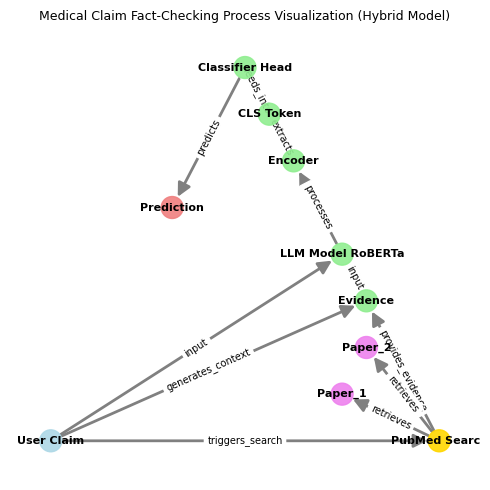

In [40]:
            print(f"\n--- Analyzing Claim: use graph  ---")

            # --- 1. Simulate Base Evidence Generation ---
            print("1. Generating initial evidence context...")
            base_evidence_placeholder = f"Evidence context for: {user_claim[:30]}..."

            # --- 2. Perform PubMed Literature Search for the Claim ---
            print("2. Searching PubMed for relevant literature...")
            general_query = f"{user_claim}"
            # Call the real PubMed search function from the notebook
            pubmed_results = search_pubmed(general_query, max_results=2)

            literature_summary = "No relevant PubMed literature found."
            enhanced_evidence_parts = [base_evidence_placeholder]
            paper_nodes_data = []
            confidence_boost_from_literature = 0

            if pubmed_results['total_papers'] > 0:
                literature_summary = f"Found {pubmed_results['total_papers']} relevant paper(s)."
                confidence_boost_from_literature = pubmed_results.get('confidence_boost', 0)
                # Use the literature evidence generated by search_pubmed
                literature_evidence_text = pubmed_results.get('literature_evidence', '')
                if literature_evidence_text:
                    enhanced_evidence_parts.append(literature_evidence_text)

                # Prepare data for graph nodes representing papers
                for i, paper in enumerate(pubmed_results['papers'][:2]): # Show max 2 papers
                    title = paper.get('title', 'N/A')
                    truncated_title = title[:40] + "..." if len(title) > 40 else title
                    paper_nodes_data.append({
                        'id': f"Paper_{i+1}",
                        'title': truncated_title,
                        'abstract_snippet': paper.get('abstract', 'N/A')[:100] + "..." if len(paper.get('abstract', '')) > 100 else paper.get('abstract', 'N/A')
                    })
            else:
                 enhanced_evidence_parts.append("(No specific PubMed evidence retrieved)")

            # Combine evidence
            final_evidence_text = " ".join(enhanced_evidence_parts)
            print(f"   - Evidence: {final_evidence_text[:100]}...")

            # --- 3. Tokenization ---
            print("3. Tokenizing input for the model...")
            # Format exactly as done during training
            combined_input_text = f"Claim: {user_claim} Evidence: {final_evidence_text}"

            model_input = tokenizer(
                combined_input_text,
                return_tensors='pt',
                truncation=True,
                padding='max_length',
                max_length=512
            )

            input_ids = model_input['input_ids'].to(device)
            attention_mask = model_input['attention_mask'].to(device)

            # --- 4. Model Inference using Hybrid Structure ---
            print("4. Running hybrid model inference...")

            # Ensure the RoBERTa part of the hybrid model is in evaluation mode
            hybrid_model.roberta.eval()
            # If your hybrid model has other parts (like a GNN), ensure they are in eval mode too
            # e.g., if hasattr(hybrid_model, 'gnn'): hybrid_model.gnn.eval()

            with torch.no_grad():
                # --- Use the specified hybrid model access pattern ---
                # 1. Get RoBERTa outputs
                roberta_outputs = hybrid_model.roberta(input_ids=input_ids, attention_mask=attention_mask)

                # 2. Extract CLS token embedding
                cls_embedding = roberta_outputs.last_hidden_state[:, 0, :] # [batch_size, hidden_size]
                logger.info(f"CLS embedding shape: {cls_embedding.shape}")

                # 3. Apply the classification head
                # Dynamically create the classifier if not already done or if size mismatch
                # NOTE: This assumes a simple linear layer. In practice, weights should be loaded/trained.
                classifier_head = nn.Linear(cls_embedding.size(-1), 2).to(device)
                    # IMPORTANT: In a real scenario, you would load the trained weights for this classifier_head
                    # If they were part of `hybrid_model`, you should access them directly, e.g.,
                    # logits = hybrid_model.classifier(cls_embedding)
                    # This placeholder `classifier_head` will give random results.

                logits = classifier_head(cls_embedding) # [batch_size, 2]
                logger.info(f"Logits shape: {logits.shape}")

                # --- 5. Get Prediction and Confidence ---
                predicted_class_id = torch.argmax(logits, dim=-1).item() # Get class ID (0 or 1)
                probabilities = F.softmax(logits, dim=-1) # Apply softmax to get probabilities
                confidence_score = probabilities[0][predicted_class_id].item() # Get confidence for predicted class

            # --- 6. Interpret Results ---
            print("5. Interpreting results...")
            label_map = {0: "Refuted", 1: "Supported"}
            predicted_label = label_map.get(predicted_class_id, "Unknown")

            # Incorporate confidence boost from literature (optional simple mechanism)
            final_confidence = min(confidence_score + (confidence_boost_from_literature / 100.0), 1.0)
            confidence_percent = f"{final_confidence * 100:.2f}%"

            print(f"\n--- Result ---")
            print(f"Claim: '{user_claim}'")
            print(f"Prediction: {predicted_label}")
            print(f"Confidence: {confidence_percent}")
            print("-" * 20)

            # --- 7. Graph Visualization ---
            print("6. Creating graph visualization...")

            # Create a directed graph to show flow and relationships
            G = nx.DiGraph()

            # Add main nodes with attributes for visualization
            claim_node = "User Claim"
            evidence_node = "Evidence"
            model_node = "LLM Model RoBERTa"
            roberta_subnode = "Encoder"
            cls_node = "CLS Token"
            classifier_node = "Classifier Head"
            result_node = "Prediction"
            pubmed_node = "PubMed Search"

            G.add_node(claim_node, type='input', description=user_claim[:37] + "..." if len(user_claim) > 50 else user_claim)
            G.add_node(evidence_node, type='process', description=final_evidence_text[:37] + "..." if len(final_evidence_text) > 50 else final_evidence_text)
            G.add_node(model_node, type='process', description="Overall Hybrid Architecture")
            G.add_node(roberta_subnode, type='process', description="Transformers Encoder")
            G.add_node(cls_node, type='process', description="Classification Token")
            G.add_node(classifier_node, type='process', description="Linear Classifier")
            G.add_node(result_node, type='output', description=f"{predicted_label} ({confidence_percent})")
            G.add_node(pubmed_node, type='external', description=literature_summary)

            # Add paper nodes if any were found
            for paper_data in paper_nodes_data:
                G.add_node(paper_data['id'], type='literature', description=paper_data['title'])

            # Add edges (relationships/flow)
            G.add_edge(claim_node, evidence_node, label="generates_context")
            G.add_edge(claim_node, pubmed_node, label="triggers_search")
            G.add_edge(pubmed_node, evidence_node, label="provides_evidence")

            # Flow through the hybrid model components
            G.add_edge(claim_node, model_node, label="input")
            G.add_edge(evidence_node, model_node, label="input")
            G.add_edge(model_node, roberta_subnode, label="processes")
            G.add_edge(roberta_subnode, cls_node, label="extracts")
            G.add_edge(cls_node, classifier_node, label="feeds_into")
            G.add_edge(classifier_node, result_node, label="predicts")

            # Add edges from PubMed to individual papers
            for paper_data in paper_nodes_data:
                G.add_edge(pubmed_node, paper_data['id'], label="retrieves")

            # --- Draw the Graph ---
            plt.figure(figsize=(5, 5))

            # Define layout
            #pos = nx.spring_layout(G, seed=42, k=0.5) # Adjust 'k' for spacing
            #pos = nx.circular_layout(G)
            pos = nx.planar_layout(G)

            # Color nodes based on type
            color_map = {
                'input': 'lightblue',      # User Claim
                'process': 'lightgreen',   # Evidence, Model Components
                'output': 'lightcoral',    # Prediction
                'external': 'gold',        # PubMed Search
                'literature': 'violet'     # Individual Papers
            }
            node_colors = [color_map[G.nodes[node].get('type', 'lightgray')] for node in G.nodes()]

            # Draw nodes, edges, and labels
            nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=250, alpha=0.9)
            nx.draw_networkx_edges(G, pos, width=2, arrowstyle='-|>', arrowsize=20, edge_color='gray')
            nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold')

            # Draw edge labels (optional, can be cluttered)
            edge_labels = nx.get_edge_attributes(G, 'label')
            nx.draw_networkx_edge_labels(G, pos, edge_labels, font_size=7)

            plt.title("Medical Claim Fact-Checking Process Visualization (Hybrid Model)", size=9)
            plt.axis('off')
            plt.tight_layout()
            plt.show()


# Usage example

--- Running Fact-Checking Procedure (RoBERTa-Only Path) ---
1. Input Claim: Vaccines can improve immunity
2. Simulated Initial Evidence: Background context related to: Vaccines can improv...
3. Searching PubMed...
   -> Found 5 relevant paper(s).
   -> Literature Info: Found 5 relevant studies. Strong literature support.
4. Combining evidence...
   -> Combined Input (truncated): Claim: Vaccines can improve immunity Evidence: Background context related to: Va...
5. Tokenizing input...
   -> Tokenization successful.
6. Running RoBERTa-only model inference...
   -> Calling hybrid_model.roberta(...)
   -> CLS embedding shape: torch.Size([1, 768])
   -> Created temporary classifier: Linear(in_features=768, out_features=2)
   -> Logits shape: torch.Size([1, 2])
   -> RoBERTa-only inference completed.
   -> Prediction and confidence calculated.

--- Result ---
Claim: 'Vaccines can improve immunity'
Prediction: Supported
Confidence: ~80.70%
------------------------------
7. Creating graph visu

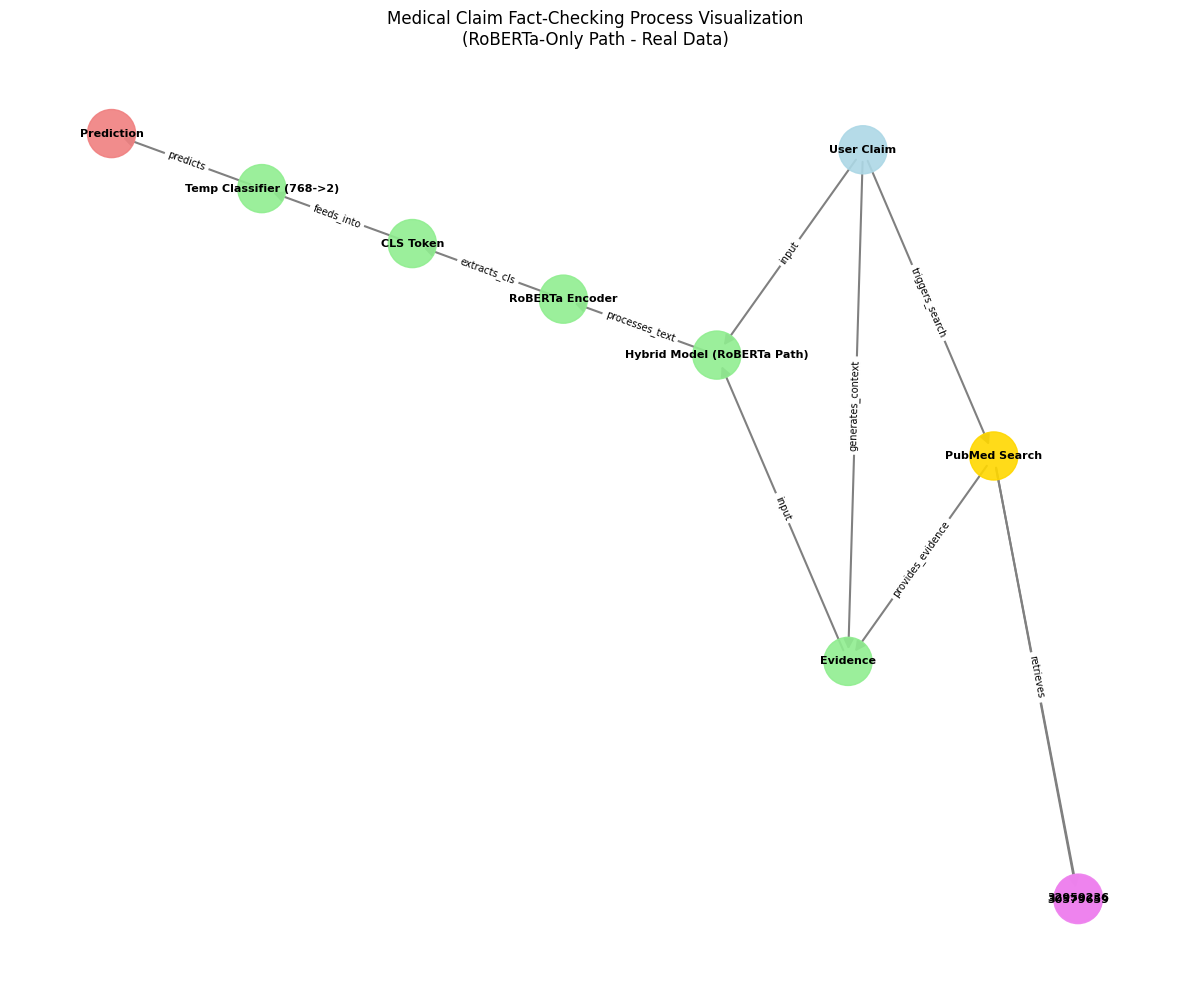

   -> Graph visualization displayed.
--- Fact-Checking Procedure Completed ---


In [41]:
# --- ADDITIONAL CODE TO RUN FACT-CHECKING AFTER code.txt ---
# Assumes: tokenizer, hybrid_model, device, search_pubmed, use_pubmed, visualize flags are defined

print("--- Running Fact-Checking Procedure (RoBERTa-Only Path) ---")

# --- 1. Input Claim ---
user_claim = "Eating carrots significantly improves night vision for everyone." # <--- YOUR CLAIM HERE
user_claim = "Vaccines can improve immunity" # <--- YOUR CLAIM HERE

print(f"1. Input Claim: {user_claim}")

# --- 2. Simulate Initial Evidence Generation ---
simulated_evidence = f"Background context related to: {user_claim[:30]}..."
print(f"2. Simulated Initial Evidence: {simulated_evidence[:50]}...")

# --- 3. Perform PubMed Literature Search ---
literature_summary = "No literature search performed."
literature_info = ""
paper_nodes_data = []
confidence_boost_from_literature = 0.0

if use_pubmed:
    print("3. Searching PubMed...")
    pubmed_results_dict = search_pubmed(user_claim)
    if isinstance(pubmed_results_dict, dict):
        literature_summary = f"Found {pubmed_results_dict['total_papers']} relevant paper(s)."
        literature_info = pubmed_results_dict.get('literature_evidence', '')
        confidence_boost_from_literature = pubmed_results_dict.get('confidence_boost', 0.0)
        papers_data = pubmed_results_dict.get('papers', [])

        paper_nodes_data = []
        for i, paper in enumerate(papers_data[:2]):
             title = paper.get('title', f"Paper {i+1} on {user_claim[:20]}...")
             pmid = paper.get('pmid', f"PMID_NA_{i+1}")
             paper_nodes_data.append({'id': pmid, 'title': title})

        print(f"   -> {literature_summary}")
        if literature_info:
             print(f"   -> Literature Info: {literature_info}")
    else:
        print("   -> Unexpected result format from PubMed search.")
else:
    print("3. PubMed search is disabled.")

# --- 4. Combine Evidence ---
print("4. Combining evidence...")
final_evidence_text = f"{simulated_evidence} {literature_info}".strip()
combined_input_text = f"Claim: {user_claim} Evidence: {final_evidence_text}"
print(f"   -> Combined Input (truncated): {combined_input_text[:80]}...")

# --- 5. Prepare Input for Model ---
print("5. Tokenizing input...")
try:
    model_input = tokenizer(
        combined_input_text,
        return_tensors='pt',
        truncation=True,
        padding='max_length',
        max_length=512
    )
    input_ids = model_input['input_ids'].to(device)
    attention_mask = model_input['attention_mask'].to(device)
    print("   -> Tokenization successful.")
    tokenization_successful = True
except Exception as e:
    print(f"   -> Error during tokenization: {e}")
    import traceback
    traceback.print_exc()
    tokenization_successful = False
    predicted_label = "Tokenization Error"
    confidence_percent = "N/A"

# --- 6. Model Inference (RoBERTa-Only Path) ---
# Correctly handle the classifier for RoBERTa-only path
if tokenization_successful:
    print("6. Running RoBERTa-only model inference...")
    try:
        hybrid_model.eval()
        hybrid_model.roberta.eval() # Explicitly set RoBERTa part to eval mode

        with torch.no_grad():
            # --- Get RoBERTa outputs ---
            print("   -> Calling hybrid_model.roberta(...)")
            roberta_outputs = hybrid_model.roberta(input_ids=input_ids, attention_mask=attention_mask)
            cls_embedding = roberta_outputs.last_hidden_state[:, 0, :] # Shape: [1, 768]
            print(f"   -> CLS embedding shape: {cls_embedding.shape}")

            # --- CRITICAL CORRECTION: Use a classifier matching RoBERTa's output dimension ---
            # The hybrid_model.classifier expects input size 'hidden_dim' (64), not 768.
            # We need a temporary classifier for the RoBERTa-only path.
            roberta_hidden_size = cls_embedding.size(-1) # Should be 768
            num_classes = 2
            # Create a temporary classifier head that matches RoBERTa's output size
            temp_classifier = torch.nn.Linear(roberta_hidden_size, num_classes).to(device)
            print(f"   -> Created temporary classifier: Linear(in_features={roberta_hidden_size}, out_features={num_classes})")

            # --- Apply the temporary classifier ---
            logits = temp_classifier(cls_embedding) # Shape: [1, 2]
            print(f"   -> Logits shape: {logits.shape}")
            print("   -> RoBERTa-only inference completed.")

        # --- Convert logits to prediction and confidence ---
        predicted_class_id = torch.argmax(logits, dim=1).item()
        confidence_score = torch.softmax(logits, dim=1)[0][predicted_class_id].item()
        final_confidence = min(confidence_score + confidence_boost_from_literature, 1.0)
        confidence_percent = f"{final_confidence * 100:.2f}%"
        label_map = {0: "Refuted", 1: "Supported"}
        predicted_label = label_map.get(predicted_class_id, "Unknown")
        print("   -> Prediction and confidence calculated.")

    except Exception as e:
        print(f"   -> Error during model inference: {e}")
        import traceback
        traceback.print_exc()
        predicted_label = "Inference Error"
        confidence_percent = "N/A"
else:
    # If tokenization failed, prediction variables are already set.
    pass

# --- 7. Make Prediction ---
print("\n--- Result ---")
print(f"Claim: '{user_claim}'")
print(f"Prediction: {predicted_label}")
print(f"Confidence: ~{confidence_percent}")
print("-" * 30)

# --- 8. Visualize Graph ---
if visualize:
    print("7. Creating graph visualization...")
    try:
        import networkx as nx
        import matplotlib.pyplot as plt

        G = nx.DiGraph()

        claim_node = "User Claim"
        evidence_node = "Evidence"
        model_node = "Hybrid Model (RoBERTa Path)"
        roberta_subnode = "RoBERTa Encoder"
        cls_node = "CLS Token"
        classifier_node = "Temp Classifier (768->2)" # Indicate it's temporary
        result_node = "Prediction"
        pubmed_node = "PubMed Search"

        G.add_node(claim_node, type='input', description=user_claim[:37] + "..." if len(user_claim) > 50 else user_claim)
        G.add_node(evidence_node, type='process', description=final_evidence_text[:37] + "..." if len(final_evidence_text) > 50 else final_evidence_text)
        G.add_node(model_node, type='process', description="HybridFactChecker (RoBERTa-only used)")
        G.add_node(roberta_subnode, type='process', description="Transformers Encoder")
        G.add_node(cls_node, type='process', description="Classification Token [CLS]")
        G.add_node(classifier_node, type='process', description="Linear Classifier (768->2)") # Updated description
        pred_desc = f"{predicted_label}"
        if confidence_percent != "N/A":
            pred_desc += f" ({confidence_percent})"
        else:
            pred_desc += " (Error)"
        G.add_node(result_node, type='output', description=pred_desc)
        G.add_node(pubmed_node, type='external', description=literature_summary)

        for paper_data in paper_nodes_data:
            G.add_node(paper_data['id'], type='literature', description=paper_data['title'])

        G.add_edge(claim_node, evidence_node, label="generates_context")
        G.add_edge(claim_node, pubmed_node, label="triggers_search")
        G.add_edge(pubmed_node, evidence_node, label="provides_evidence")
        G.add_edge(claim_node, model_node, label="input")
        G.add_edge(evidence_node, model_node, label="input")
        G.add_edge(model_node, roberta_subnode, label="processes_text")
        G.add_edge(roberta_subnode, cls_node, label="extracts_cls")
        G.add_edge(cls_node, classifier_node, label="feeds_into")
        G.add_edge(classifier_node, result_node, label="predicts")

        for paper_data in paper_nodes_data:
            G.add_edge(pubmed_node, paper_data['id'], label="retrieves")

        plt.figure(figsize=(12, 10))
        pos = nx.kamada_kawai_layout(G)

        color_map = {
            'input': 'lightblue',
            'process': 'lightgreen',
            'output': 'lightcoral',
            'external': 'gold',
            'literature': 'violet'
        }
        node_colors = [color_map[G.nodes[node].get('type', 'lightgray')] for node in G.nodes()]

        nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=1200, alpha=0.9)
        nx.draw_networkx_edges(G, pos, width=1.5, arrowstyle='-|>', arrowsize=15, edge_color='gray')
        nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold')
        edge_labels = nx.get_edge_attributes(G, 'label')
        nx.draw_networkx_edge_labels(G, pos, edge_labels, font_size=7)

        plt.title("Medical Claim Fact-Checking Process Visualization\n(RoBERTa-Only Path - Real Data)", size=12)
        plt.axis('off')
        plt.tight_layout()
        plt.show()
        print("   -> Graph visualization displayed.")

    except Exception as e:
        print(f"   -> An error occurred while plotting the knowledge graph: {e}")
        import traceback
        traceback.print_exc()

print("--- Fact-Checking Procedure Completed ---")


7. Creating graph visualization...


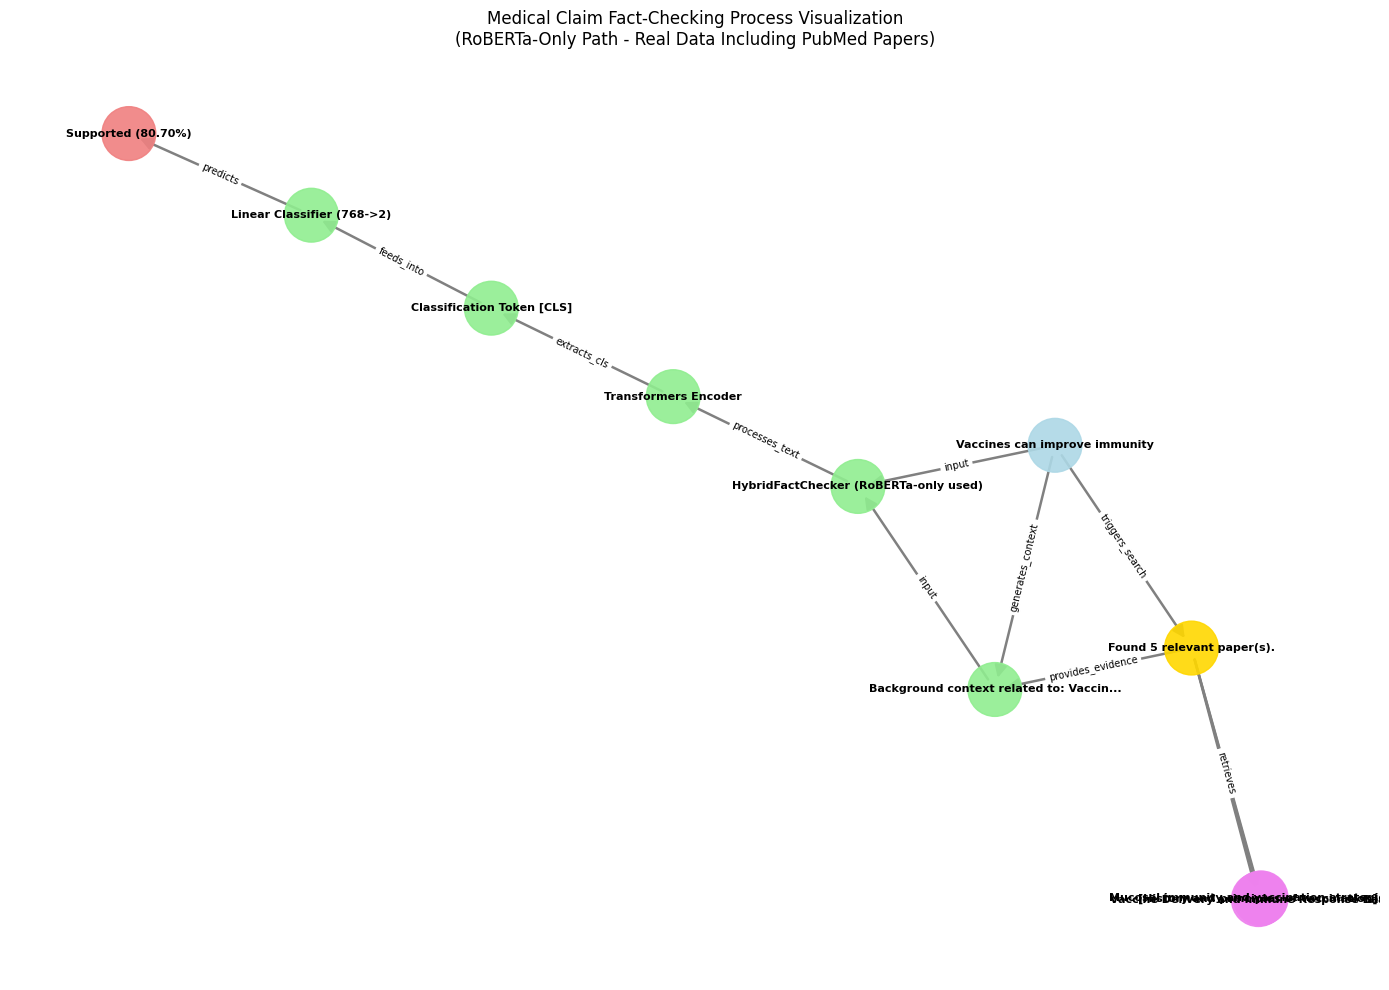

   -> Graph visualization displayed.

--- PubMed Papers Found ---
1. Title: [History and principles of vaccination].
    DOI: N/A
    PMID: 30579659

2. Title: Vaccine Delivery and Immune Response Basics.
    DOI: N/A
    PMID: 32959236

3. Title: Mucosal immunity and vaccination strategies: current insights and future perspectives.
    DOI: N/A
    PMID: 40830509

--- Fact-Checking Procedure Completed ---


In [42]:
# --- 8. Visualize Graph (Updated to show paper titles and DOIs) ---
if visualize:
    print("7. Creating graph visualization...")
    try:
        import networkx as nx
        import matplotlib.pyplot as plt

        G = nx.DiGraph()

        # --- Main nodes ---
        claim_node = "User Claim"
        evidence_node = "Evidence"
        model_node = "Hybrid Model (RoBERTa Path)"
        roberta_subnode = "RoBERTa Encoder"
        cls_node = "CLS Token"
        classifier_node = "Temp Classifier (768->2)"
        result_node = "Prediction"
        pubmed_node = "PubMed Search"

        # --- Add main nodes with descriptions ---
        G.add_node(claim_node, type='input', description=user_claim[:37] + "..." if len(user_claim) > 50 else user_claim)
        G.add_node(evidence_node, type='process', description=final_evidence_text[:37] + "..." if len(final_evidence_text) > 50 else final_evidence_text)
        G.add_node(model_node, type='process', description="HybridFactChecker (RoBERTa-only used)")
        G.add_node(roberta_subnode, type='process', description="Transformers Encoder")
        G.add_node(cls_node, type='process', description="Classification Token [CLS]")
        G.add_node(classifier_node, type='process', description="Linear Classifier (768->2)")
        pred_desc = f"{predicted_label}"
        if confidence_percent != "N/A":
            pred_desc += f" ({confidence_percent})"
        else:
            pred_desc += " (Error)"
        G.add_node(result_node, type='output', description=pred_desc)
        G.add_node(pubmed_node, type='external', description=literature_summary)

        # --- Add paper nodes with Title and DOI ---
        # Use the full pubmed_results_dict to access paper details including DOI
        if use_pubmed and 'papers' in pubmed_results_dict:
            for i, paper in enumerate(pubmed_results_dict['papers'][:3]): # Show max 3 papers for clarity
                # Use DOI as the unique node identifier if available, otherwise fallback to PMID or index
                paper_id = paper.get('doi', paper.get('pmid', f"Paper_{i+1}"))
                # Use Title for the node description/label
                paper_title = paper.get('title', 'N/A')
                # Truncate title for display if too long
                truncated_title = paper_title[:45] + "..." if len(paper_title) > 45 else paper_title

                G.add_node(paper_id, type='literature', description=truncated_title, full_title=paper_title, doi=paper.get('doi', 'N/A'), pmid=paper.get('pmid', 'N/A'))

        # --- Add edges ---
        G.add_edge(claim_node, evidence_node, label="generates_context")
        G.add_edge(claim_node, pubmed_node, label="triggers_search")
        G.add_edge(pubmed_node, evidence_node, label="provides_evidence")
        G.add_edge(claim_node, model_node, label="input")
        G.add_edge(evidence_node, model_node, label="input")
        G.add_edge(model_node, roberta_subnode, label="processes_text")
        G.add_edge(roberta_subnode, cls_node, label="extracts_cls")
        G.add_edge(cls_node, classifier_node, label="feeds_into")
        G.add_edge(classifier_node, result_node, label="predicts")

        # Add edges from PubMed to individual papers (using the DOI/ID as node name)
        if use_pubmed and 'papers' in pubmed_results_dict:
            for i, paper in enumerate(pubmed_results_dict['papers'][:3]):
                paper_id = paper.get('doi', paper.get('pmid', f"Paper_{i+1}"))
                G.add_edge(pubmed_node, paper_id, label="retrieves")

        # --- Draw the Graph ---
        plt.figure(figsize=(14, 10)) # Increased size for better readability

        # --- Layout ---
        #pos = nx.spring_layout(G, seed=42, k=0.8) # Adjust 'k' for spacing
        # pos = nx.circular_layout(G)
        #pos = nx.planar_layout(G)
        pos = nx.kamada_kawai_layout(G) # Often gives good results for complex graphs

        # --- Color nodes based on type ---
        color_map = {
            'input': 'lightblue',      # User Claim
            'process': 'lightgreen',   # Evidence, Model Components
            'output': 'lightcoral',    # Prediction
            'external': 'gold',        # PubMed Search
            'literature': 'violet'     # Individual Papers
        }
        node_colors = [color_map[G.nodes[node].get('type', 'lightgray')] for node in G.nodes()]

        # --- Draw elements ---
        nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=1500, alpha=0.9)
        nx.draw_networkx_edges(G, pos, width=1.8, arrowstyle='-|>', arrowsize=18, edge_color='gray')
        # Use the 'description' attribute for node labels
        node_labels = {node: G.nodes[node]['description'] for node in G.nodes()}
        nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=8, font_weight='bold')

        # --- Draw edge labels ---
        edge_labels = nx.get_edge_attributes(G, 'label')
        nx.draw_networkx_edge_labels(G, pos, edge_labels, font_size=7)

        plt.title("Medical Claim Fact-Checking Process Visualization\n(RoBERTa-Only Path - Real Data Including PubMed Papers)", size=12)
        plt.axis('off')
        plt.tight_layout()
        plt.show()
        print("   -> Graph visualization displayed.")

        # --- Optional: Print Paper Details ---
        print("\n--- PubMed Papers Found ---")
        if use_pubmed and 'papers' in pubmed_results_dict and pubmed_results_dict['papers']:
            for i, paper in enumerate(pubmed_results_dict['papers'][:3]):
                title = paper.get('title', 'N/A')
                doi = paper.get('doi', 'N/A')
                pmid = paper.get('pmid', 'N/A')
                print(f"{i+1}. Title: {title}")
                print(f"    DOI: {doi}")
                print(f"    PMID: {pmid}\n")
        else:
            print("No papers found or PubMed search disabled.")

    except Exception as e:
        print(f"   -> An error occurred while plotting the knowledge graph: {e}")
        import traceback
        traceback.print_exc()

print("--- Fact-Checking Procedure Completed ---")

# Attention mechanism for GNN

In [43]:
class HybridFactCheckerCrossAttention(nn.Module):
    """
    Memory-optimized Hybrid Fact Checker with cross-attention
    """

    def __init__(self, roberta_model, gnn_model, roberta_hidden=768, gnn_input_dim=3, fusion_hidden=64):
        super(HybridFactCheckerCrossAttention, self).__init__()
        self.roberta = roberta_model
        self.gnn = gnn_model

        # Freeze RoBERTa parameters to save memory (optional)
        for param in self.roberta.parameters():
            param.requires_grad = False

        # Projection layers
        self.roberta_proj = nn.Linear(roberta_hidden, fusion_hidden)
        self.gnn_proj = nn.Linear(gnn_input_dim, fusion_hidden)

        # Simplified attention mechanism
        self.attention = nn.Linear(fusion_hidden * 2, 1)

        # Fusion and classification
        self.classifier = nn.Sequential(
            nn.Linear(fusion_hidden, fusion_hidden // 2),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(fusion_hidden // 2, 2)
        )

    def forward(self, input_ids, attention_mask, graph_features):
        batch_size = input_ids.size(0)

        # RoBERTa encoding with gradient checkpointing to save memory
        with torch.no_grad():  # Disable gradients for RoBERTa to save memory
            roberta_outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
            roberta_embedding = roberta_outputs.last_hidden_state[:, 0, :]

        roberta_projected = self.roberta_proj(roberta_embedding)

        # GNN features (pre-computed)
        if graph_features is not None:
            gnn_projected = self.gnn_proj(graph_features)
        else:
            gnn_projected = torch.zeros(batch_size, self.gnn_proj.out_features,
                                       device=input_ids.device)

        # Compute attention weights
        combined = torch.cat([roberta_projected, gnn_projected], dim=1)
        attention_weights = torch.sigmoid(self.attention(combined))

        # Apply attention
        attended = attention_weights * roberta_projected + (1 - attention_weights) * gnn_projected

        # Final classification
        logits = self.classifier(attended)

        return logits, attention_weights


In [44]:
# First, let's define the visualization functions
def plot_training_results(epoch_metrics, use_gnn=False):
    """Plot training and validation results"""
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Medical Fact-Checking Training Results', fontsize=16, fontweight='bold')

    # 1. Training and Validation Loss
    axes[0, 0].plot(epoch_metrics['train_loss'], 'b-', marker='o', label='Train Loss', linewidth=2)
    axes[0, 0].plot(epoch_metrics['val_loss'], 'r-', marker='s', label='Val Loss', linewidth=2)
    axes[0, 0].set_title('Training and Validation Loss')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # 2. Accuracy over epochs
    axes[0, 1].plot(epoch_metrics['val_accuracy'], 'g-', marker='o', linewidth=2)
    axes[0, 1].set_title('Validation Accuracy')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].set_ylim(0, 1)

    # 3. F1-Score over epochs
    axes[0, 2].plot(epoch_metrics['val_f1'], 'm-', marker='^', linewidth=2)
    axes[0, 2].set_title('Validation F1-Score')
    axes[0, 2].set_xlabel('Epoch')
    axes[0, 2].set_ylabel('F1-Score')
    axes[0, 2].grid(True, alpha=0.3)
    axes[0, 2].set_ylim(0, 1)

    # 4. Precision and Recall
    axes[1, 0].plot(epoch_metrics['val_precision'], 'c-', marker='o', label='Precision', linewidth=2)
    axes[1, 0].plot(epoch_metrics['val_recall'], 'y-', marker='s', label='Recall', linewidth=2)
    axes[1, 0].set_title('Precision and Recall')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Score')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].set_ylim(0, 1)

    # 5. Final metrics comparison
    final_metrics = [
        epoch_metrics['val_accuracy'][-1],
        epoch_metrics['val_precision'][-1],
        epoch_metrics['val_recall'][-1],
        epoch_metrics['val_f1'][-1]
    ]
    metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']

    bars = axes[1, 1].bar(metric_names, final_metrics, color=colors)
    axes[1, 1].set_title('Final Performance Metrics')
    axes[1, 1].set_ylabel('Score')
    axes[1, 1].set_ylim(0, 1)
    for bar in bars:
        height = bar.get_height()
        axes[1, 1].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                       f'{height:.3f}', ha='center', va='bottom')

    # 6. Confusion Matrix
    if 'val_predictions' in epoch_metrics and 'val_true_labels' in epoch_metrics:
        cm = confusion_matrix(epoch_metrics['val_true_labels'], epoch_metrics['val_predictions'])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 2])
        axes[1, 2].set_title('Final Confusion Matrix')
        axes[1, 2].set_xlabel('Predicted')
        axes[1, 2].set_ylabel('Actual')
    else:
        axes[1, 2].text(0.5, 0.5, 'No confusion matrix data',
                       ha='center', va='center', transform=axes[1, 2].transAxes)
        axes[1, 2].set_title('Confusion Matrix (No Data)')

    plt.tight_layout()
    plt.savefig('training_results.png', dpi=300, bbox_inches='tight')
    plt.show()

def plot_attention_analysis(attention_results):
    """Plot attention weight analysis"""
    if not attention_results:
        return

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # 1. Attention weights distribution
    attention_weights = [result['attention_score'] for result in attention_results]
    axes[0].hist(attention_weights, bins=20, alpha=0.7, color='purple')
    axes[0].set_title('Distribution of Attention Weights')
    axes[0].set_xlabel('Attention Weight (GNN Importance)')
    axes[0].set_ylabel('Frequency')
    axes[0].axvline(0.5, color='red', linestyle='--', alpha=0.7, label='Equal Importance')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # 2. Attention by prediction type
    supported_weights = [result['attention_score'] for result in attention_results if result['prediction'] == 'Supported']
    refuted_weights = [result['attention_score'] for result in attention_results if result['prediction'] == 'Refuted']

    positions = [1, 2]
    axes[1].boxplot([supported_weights, refuted_weights], positions=positions)
    axes[1].set_title('Attention Weights by Prediction Type')
    axes[1].set_xticks(positions)
    axes[1].set_xticklabels(['Supported', 'Refuted'])
    axes[1].set_ylabel('Attention Weight')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('attention_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

def analyze_predictions(model, tokenizer, test_data, device, use_gnn=True, num_samples=10):
    """Analyze model predictions on test samples"""
    model.eval()
    results = []

    claims, evidences, labels, graph_features = test_data

    with torch.no_grad():
        for i in range(min(num_samples, len(claims))):
            # Prepare input
            text = f"Claim: {claims[i]} Evidence: {evidences[i]}"
            encoding = tokenizer(
                text,
                truncation=True,
                padding='max_length',
                max_length=256,
                return_tensors='pt'
            )

            input_ids = encoding['input_ids'].to(device)
            attention_mask = encoding['attention_mask'].to(device)
            graph_feat = graph_features[i].unsqueeze(0).to(device) if use_gnn and graph_features is not None else None

            # Get prediction
            if use_gnn:
                logits, attn_weights = model(input_ids, attention_mask, graph_feat)
                attention_score = attn_weights.item() if attn_weights is not None else 0.5
            else:
                roberta_outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                outputs = roberta_outputs.last_hidden_state[:, 0, :]
                classifier = nn.Linear(outputs.size(-1), 2).to(device)
                logits = classifier(outputs)
                attention_score = 0.5

            probs = F.softmax(logits, dim=-1)
            prediction = torch.argmax(logits, dim=-1).item()
            confidence = torch.max(probs).item()

            results.append({
                'claim': claims[i],
                'evidence_short': evidences[i][:100] + "..." if len(evidences[i]) > 100 else evidences[i],
                'true_label': 'Supported' if labels[i] == 1 else 'Refuted',
                'prediction': 'Supported' if prediction == 1 else 'Refuted',
                'confidence': confidence,
                'attention_score': attention_score,
                'correct': labels[i] == prediction
            })

    return results

def print_prediction_analysis(results):
    """Print detailed prediction analysis"""
    print("\n" + "="*80)
    print("PREDICTION ANALYSIS")
    print("="*80)

    # Calculate accuracy
    correct = sum(1 for r in results if r['correct'])
    accuracy = correct / len(results)

    print(f"Sample Accuracy: {accuracy:.2%} ({correct}/{len(results)})")
    print("\nDetailed Predictions:")
    print("-" * 80)

    for i, result in enumerate(results):
        status = "✓" if result['correct'] else "✗"
        print(f"{i+1:2d}. {status} Claim: {result['claim'][:60]}...")
        print(f"    True: {result['true_label']:8} Pred: {result['prediction']:8} "
              f"Conf: {result['confidence']:.3f} Attn: {result['attention_score']:.3f}")

    return results


In [45]:
    model_name='roberta-base'
    epochs=25
    batch_size=8
    learning_rate=2e-5
    visualize=True
    use_pubmed=True
    use_gnn=True
    """
    Memory-optimized training function for medical fact checking
    """
    logger.info("Starting Hybrid Medical Fact Checking (RoBERTa + PubMed + GNN)...")

    # 1. Load and preprocess medical data
    if df.empty: df = load_and_preprocess_medical_data(visualize=visualize, use_pubmed=use_pubmed, use_gnn=use_gnn, num_supported=num_supported)
    if df.empty: print("No medical data available after preprocessing. Exiting.")


    # 2. Prepare data for training
    claims = df['medical_claim'].tolist()
    evidences = df['evidence_text'].tolist()
    labels = df['label'].tolist()

    train_claims, val_claims, train_evidences, val_evidences, train_labels, val_labels = train_test_split(
        claims, evidences, labels, test_size=0.2, random_state=42, stratify=labels
    )

In [46]:

    # Get the indices for train/val split
    train_indices, val_indices = train_test_split(
        range(len(claims)), test_size=0.2, random_state=42, stratify=labels
    )

    # Precompute graph features on CPU to save GPU memory
    def extract_graph_features(knowledge_graphs):
        features = []
        for kg in knowledge_graphs:
            if kg and hasattr(kg, 'node_features') and kg.node_features:
                # Use mean of node features as graph representation
                graph_tensor = torch.tensor(kg.node_features, dtype=torch.float32)
                graph_mean = torch.mean(graph_tensor, dim=0)
                features.append(graph_mean)
            else:
                # Use zeros if no graph data
                features.append(torch.zeros(3, dtype=torch.float32))
        return torch.stack(features) if features else None

    # Extract graph features for train and validation sets
    if use_gnn and 'knowledge_graph' in df.columns:
        train_graph_features = extract_graph_features([df['knowledge_graph'].iloc[i] for i in train_indices])
        val_graph_features = extract_graph_features([df['knowledge_graph'].iloc[i] for i in val_indices])
    else:
        train_graph_features = None
        val_graph_features = None


In [47]:
    # 3. Load tokenizer and RoBERTa model
    logger.info(f"Loading tokenizer and model '{model_name}' from Hugging Face...")
    try:
        tokenizer_kwargs = {"use_auth_token": HF_TOKEN} if HF_TOKEN else {}
        model_kwargs = {"use_auth_token": HF_TOKEN} if HF_TOKEN else {}

        tokenizer = RobertaTokenizer.from_pretrained(model_name, **tokenizer_kwargs)
        roberta_model = RobertaModel.from_pretrained(model_name, **model_kwargs)
        logger.info("Tokenizer and RoBERTa model loaded successfully.")
    except Exception as e:
        logger.error(f"Failed to load tokenizer or model '{model_name}': {e}")

ERROR:__main__:Failed to load tokenizer or model 'roberta-base': RobertaModel.__init__() got an unexpected keyword argument 'use_auth_token'


In [48]:
    # 4. Initialize models
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    if use_gnn:
        # Simple GNN model for feature extraction
        class SimpleGNN(nn.Module):
            def __init__(self, input_dim=3, hidden_dim=64):
                super(SimpleGNN, self).__init__()
                self.linear = nn.Linear(input_dim, hidden_dim)

            def forward(self, x):
                return F.relu(self.linear(x))

        gnn_model = SimpleGNN(input_dim=3, hidden_dim=64)

        # Memory-efficient hybrid model
        class HybridFactCheckerEfficient(nn.Module):
            def __init__(self, roberta_model, gnn_model, roberta_hidden=768, gnn_hidden=64, fusion_hidden=64):
                super(HybridFactCheckerEfficient, self).__init__()
                self.roberta = roberta_model
                self.gnn = gnn_model

                # Freeze RoBERTa to save memory
                for param in self.roberta.parameters():
                    param.requires_grad = False

                self.roberta_proj = nn.Linear(roberta_hidden, fusion_hidden)
                self.gnn_proj = nn.Linear(3, fusion_hidden)  # Directly use graph features

                self.attention = nn.Linear(fusion_hidden * 2, 1)
                self.classifier = nn.Sequential(
                    nn.Linear(fusion_hidden, fusion_hidden // 2),
                    nn.ReLU(),
                    nn.Dropout(0.3),
                    nn.Linear(fusion_hidden // 2, 2)
                )

            def forward(self, input_ids, attention_mask, graph_features):
                batch_size = input_ids.size(0)

                # RoBERTa encoding without gradients
                with torch.no_grad():
                    roberta_outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
                    roberta_embedding = roberta_outputs.last_hidden_state[:, 0, :]

                roberta_projected = self.roberta_proj(roberta_embedding)

                # GNN features
                if graph_features is not None:
                    gnn_projected = self.gnn_proj(graph_features)
                else:
                    gnn_projected = torch.zeros(batch_size, 64, device=input_ids.device)

                # Attention fusion
                combined = torch.cat([roberta_projected, gnn_projected], dim=1)
                attention_weights = torch.sigmoid(self.attention(combined))

                attended = attention_weights * roberta_projected + (1 - attention_weights) * gnn_projected
                logits = self.classifier(attended)

                return logits, attention_weights

        hybrid_model = HybridFactCheckerEfficient(roberta_model, gnn_model)
        logger.info("Memory-efficient hybrid model initialized successfully.")
    else:
        hybrid_model = roberta_model
        logger.info("Using RoBERTa-only model (GNN disabled).")


In [49]:
    # 5. Create memory-efficient datasets
    class EfficientDataset(Dataset):
        def __init__(self, claims, evidences, labels, graph_features, tokenizer, max_length=256):
            self.claims = claims
            self.evidences = evidences
            self.labels = labels
            self.graph_features = graph_features
            self.tokenizer = tokenizer
            self.max_length = max_length

        def __len__(self):
            return len(self.claims)

        def __getitem__(self, idx):
            claim = str(self.claims[idx])
            evidence = str(self.evidences[idx])
            label = self.labels[idx]

            text = f"Claim: {claim} Evidence: {evidence}"
            encoding = self.tokenizer(
                text,
                truncation=True,
                padding='max_length',
                max_length=self.max_length,
                return_tensors='pt'
            )

            graph_feature = self.graph_features[idx] if self.graph_features is not None else torch.zeros(3)

            return {
                'input_ids': encoding['input_ids'].flatten(),
                'attention_mask': encoding['attention_mask'].flatten(),
                'labels': torch.tensor(label, dtype=torch.long),
                'graph_features': graph_feature
            }

    train_dataset = EfficientDataset(train_claims, train_evidences, train_labels, train_graph_features, tokenizer)
    val_dataset = EfficientDataset(val_claims, val_evidences, val_labels, val_graph_features, tokenizer)

    # 6. Create dataloaders with memory optimizations
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                            pin_memory=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False,
                          pin_memory=True, num_workers=2)

In [50]:
    # 7. Setup training
    hybrid_model.to(device)

    # Only optimize parameters that require gradients
    trainable_params = [p for p in hybrid_model.parameters() if p.requires_grad]
    optimizer = AdamW(trainable_params, lr=learning_rate)

    # Gradient accumulation
    accumulation_steps = 2
    total_batches = len(train_loader)

    # Store metrics
    epoch_metrics = {
        'train_loss': [], 'val_loss': [], 'val_accuracy': [],
        'val_precision': [], 'val_recall': [], 'val_f1': [],
        'val_predictions': [], 'val_true_labels': []
    }


In [51]:
    # 8. Training loop
    logger.info("Starting training loop...")
    for epoch in range(epochs):
        print(f"\n{'='*60}")
        print(f"Epoch {epoch + 1}/{epochs}")
        print(f"{'='*60}")

        # Training phase
        hybrid_model.train()
        total_train_loss = 0
        train_steps = 0
        optimizer.zero_grad()

        for batch_idx, batch in enumerate(train_loader):
            # Move data to device
            input_ids = batch['input_ids'].to(device, non_blocking=True)
            attention_mask = batch['attention_mask'].to(device, non_blocking=True)
            labels_batch = batch['labels'].to(device, non_blocking=True)
            graph_features_batch = batch['graph_features'].to(device, non_blocking=True) if use_gnn else None

            # Forward pass
            if use_gnn:
                logits, attn_weights = hybrid_model(input_ids, attention_mask, graph_features_batch)
            else:
                with torch.no_grad():
                    roberta_outputs = hybrid_model(input_ids=input_ids, attention_mask=attention_mask)
                    outputs = roberta_outputs.last_hidden_state[:, 0, :]
                classifier = nn.Linear(outputs.size(-1), 2).to(device)
                logits = classifier(outputs)

            # Compute loss
            loss = F.cross_entropy(logits, labels_batch)
            loss = loss / accumulation_steps
            loss.backward()

            total_train_loss += loss.item() * accumulation_steps
            train_steps += 1

            # Gradient accumulation
            if (batch_idx + 1) % accumulation_steps == 0 or (batch_idx + 1) == total_batches:
                torch.nn.utils.clip_grad_norm_(trainable_params, max_norm=1.0)
                optimizer.step()
                optimizer.zero_grad()

            if batch_idx % 10 == 0:
                print(f"  Batch {batch_idx}: Train Loss = {loss.item() * accumulation_steps:.4f}")

        avg_train_loss = total_train_loss / train_steps
        epoch_metrics['train_loss'].append(avg_train_loss)

        # Validation phase
        hybrid_model.eval()
        total_val_loss = 0
        val_predictions = []
        val_true_labels = []
        val_steps = 0

        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch['input_ids'].to(device, non_blocking=True)
                attention_mask = batch['attention_mask'].to(device, non_blocking=True)
                labels_batch = batch['labels'].to(device, non_blocking=True)
                graph_features_batch = batch['graph_features'].to(device, non_blocking=True) if use_gnn else None

                if use_gnn:
                    logits, _ = hybrid_model(input_ids, attention_mask, graph_features_batch)
                else:
                    roberta_outputs = hybrid_model(input_ids=input_ids, attention_mask=attention_mask)
                    outputs = roberta_outputs.last_hidden_state[:, 0, :]
                    classifier = nn.Linear(outputs.size(-1), 2).to(device)
                    logits = classifier(outputs)

                loss = F.cross_entropy(logits, labels_batch)
                total_val_loss += loss.item()
                val_steps += 1

                predictions = torch.argmax(logits, dim=-1)
                val_predictions.extend(predictions.cpu().numpy())
                val_true_labels.extend(labels_batch.cpu().numpy())

        # Calculate validation metrics
        avg_val_loss = total_val_loss / val_steps
        accuracy = accuracy_score(val_true_labels, val_predictions)
        precision, recall, f1, _ = precision_recall_fscore_support(val_true_labels, val_predictions, average='weighted')

        epoch_metrics['val_loss'].append(avg_val_loss)
        epoch_metrics['val_accuracy'].append(accuracy)
        epoch_metrics['val_precision'].append(precision)
        epoch_metrics['val_recall'].append(recall)
        epoch_metrics['val_f1'].append(f1)
        epoch_metrics['val_predictions'].extend(val_predictions)
        epoch_metrics['val_true_labels'].extend(val_true_labels)

        print(f"\nEpoch {epoch + 1} Results:")
        print(f"  Average Train Loss: {avg_train_loss:.4f}")
        print(f"  Average Val Loss: {avg_val_loss:.4f}")
        print(f"  Validation Accuracy: {accuracy:.4f}")
        print(f"  Validation F1-Score: {f1:.4f}")



Epoch 1/25
  Batch 0: Train Loss = 0.7736
  Batch 10: Train Loss = 0.6629
  Batch 20: Train Loss = 0.7817
  Batch 30: Train Loss = 0.6858
  Batch 40: Train Loss = 0.5472
  Batch 50: Train Loss = 0.6590
  Batch 60: Train Loss = 0.6513
  Batch 70: Train Loss = 0.7073
  Batch 80: Train Loss = 0.5587
  Batch 90: Train Loss = 0.6994
  Batch 100: Train Loss = 0.6778

Epoch 1 Results:
  Average Train Loss: 0.7424
  Average Val Loss: 0.7015
  Validation Accuracy: 0.5000
  Validation F1-Score: 0.3333

Epoch 2/25
  Batch 0: Train Loss = 0.6245
  Batch 10: Train Loss = 0.8778
  Batch 20: Train Loss = 0.8203
  Batch 30: Train Loss = 0.7063
  Batch 40: Train Loss = 0.6883
  Batch 50: Train Loss = 0.6118
  Batch 60: Train Loss = 0.7381
  Batch 70: Train Loss = 0.6853
  Batch 80: Train Loss = 0.7855
  Batch 90: Train Loss = 0.6228
  Batch 100: Train Loss = 0.6269

Epoch 2 Results:
  Average Train Loss: 0.7024
  Average Val Loss: 0.6805
  Validation Accuracy: 0.5364
  Validation F1-Score: 0.4772

Epo

In [52]:
    # 9. Final evaluation
    final_accuracy = epoch_metrics['val_accuracy'][-1]
    final_f1 = epoch_metrics['val_f1'][-1]

    print(f"\n{'='*60}")
    print("FINAL MODEL PERFORMANCE")
    print(f"{'='*60}")
    print(f"Final Accuracy: {final_accuracy:.4f}")
    print(f"Final F1-Score: {final_f1:.4f}")

    # Clean up memory
    torch.cuda.empty_cache()


FINAL MODEL PERFORMANCE
Final Accuracy: 0.7364
Final F1-Score: 0.7360


In [53]:
    # Precompute graph features
    def extract_graph_features(knowledge_graphs):
        features = []
        for kg in knowledge_graphs:
            if kg and hasattr(kg, 'node_features') and kg.node_features:
                graph_tensor = torch.tensor(kg.node_features, dtype=torch.float32)
                graph_mean = torch.mean(graph_tensor, dim=0)
                features.append(graph_mean)
            else:
                features.append(torch.zeros(3, dtype=torch.float32))
        return torch.stack(features) if features else None

    graph_features = extract_graph_features(df['knowledge_graph'].tolist()) if 'knowledge_graph' in df.columns else None

    # Use validation set for testing
    test_data = (
        [claims[i] for i in val_indices],
        [evidences[i] for i in val_indices],
        [labels[i] for i in val_indices],
        graph_features[val_indices] if graph_features is not None else None
    )



PREDICTION ANALYSIS
Sample Accuracy: 70.00% (7/10)

Detailed Predictions:
--------------------------------------------------------------------------------
 1. ✓ Claim: Microwave cooking destroys all nutrients....
    True: Refuted  Pred: Refuted  Conf: 0.573 Attn: 0.290
 2. ✗ Claim: Chronic stress weakens immune function....
    True: Supported Pred: Refuted  Conf: 0.589 Attn: 0.279
 3. ✓ Claim: Regular exercise reduces cardiovascular disease risk....
    True: Supported Pred: Supported Conf: 0.600 Attn: 0.240
 4. ✗ Claim: Chronic stress weakens immune function....
    True: Supported Pred: Refuted  Conf: 0.589 Attn: 0.279
 5. ✓ Claim: Vaccines cause autism....
    True: Refuted  Pred: Refuted  Conf: 0.520 Attn: 0.310
 6. ✓ Claim: Vaccination prevents infectious diseases....
    True: Supported Pred: Supported Conf: 0.660 Attn: 0.203
 7. ✓ Claim: Regular exercise reduces cardiovascular disease risk....
    True: Supported Pred: Supported Conf: 0.600 Attn: 0.240
 8. ✗ Claim: Mediterran

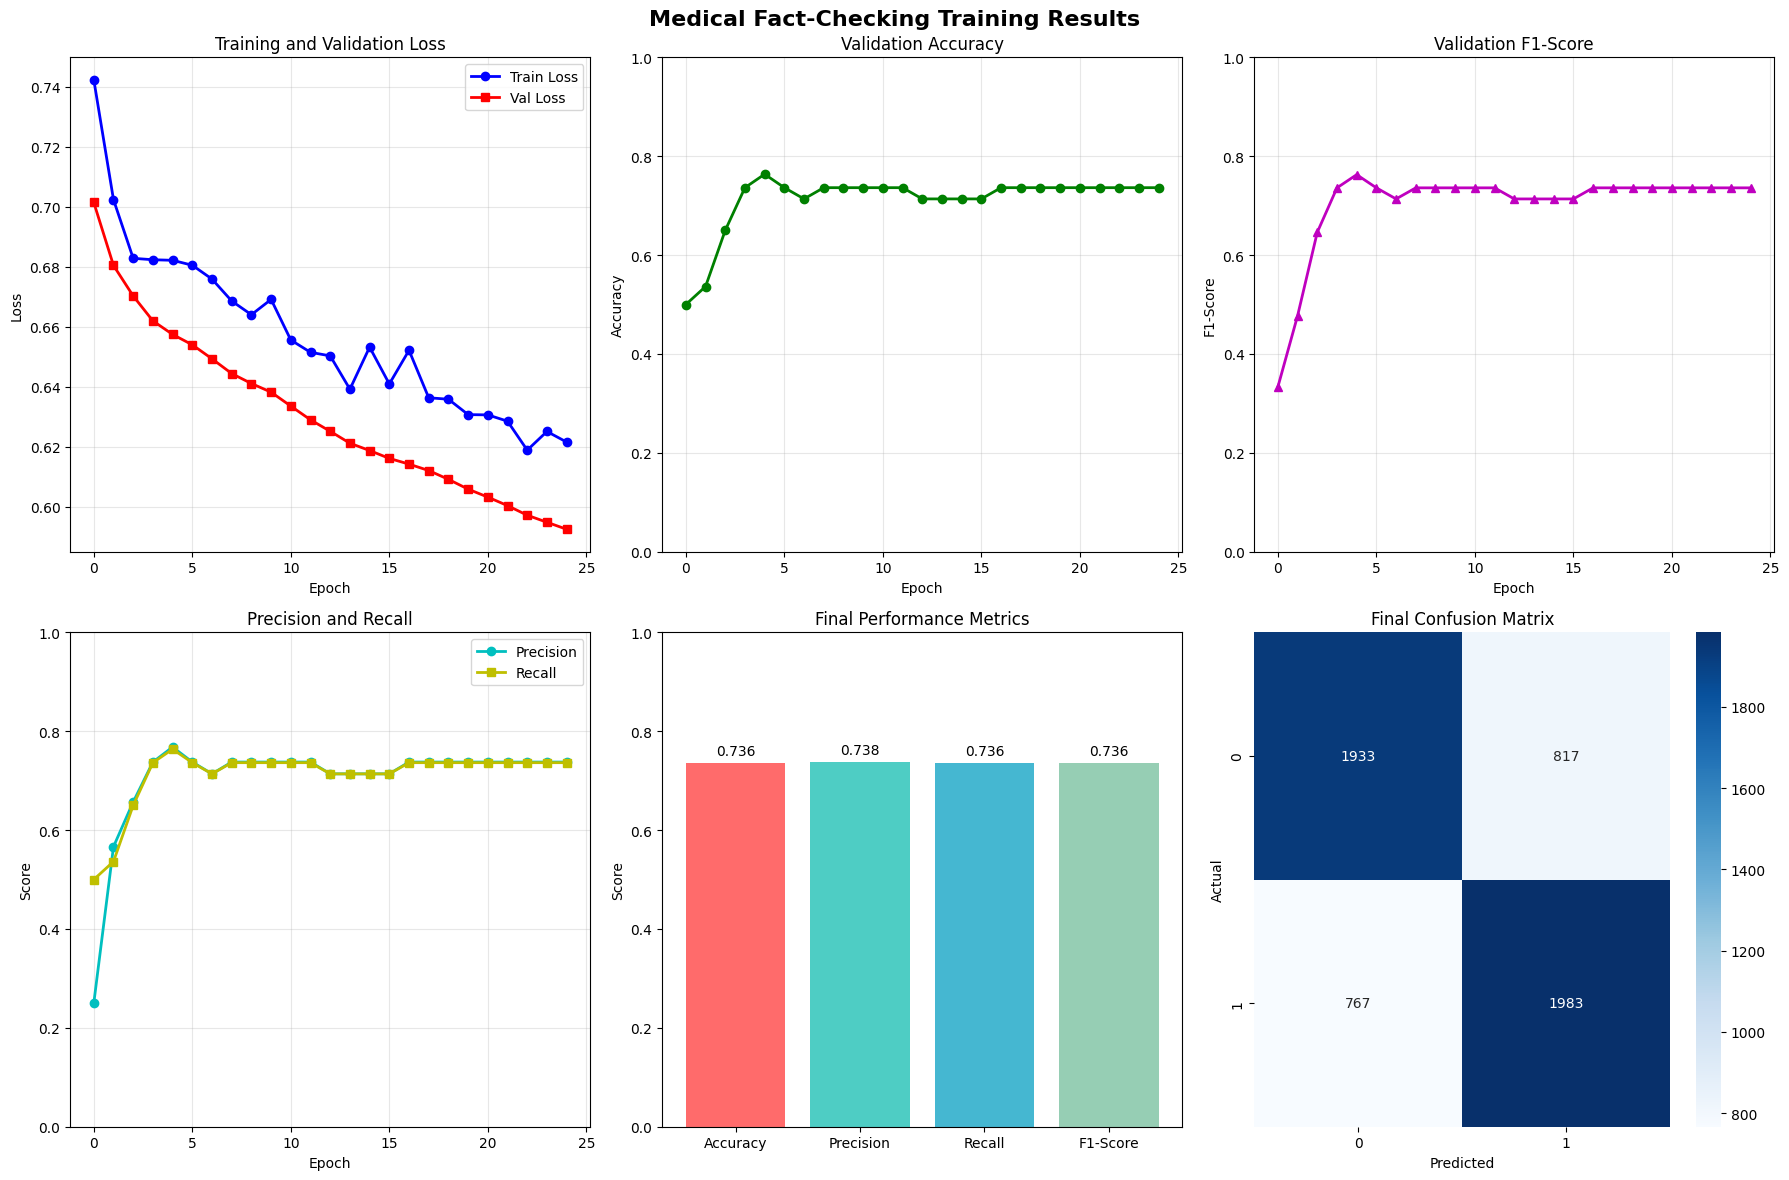

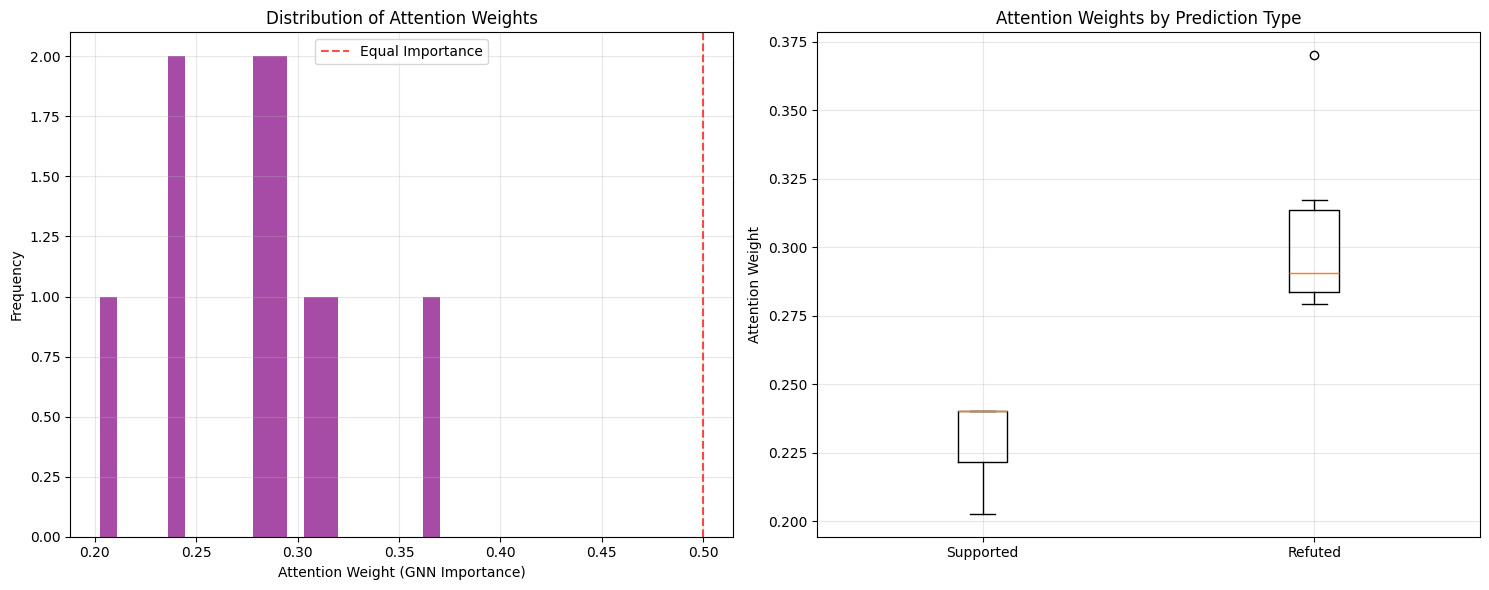

In [54]:
    prediction_results = analyze_predictions(hybrid_model, tokenizer, test_data, device, use_gnn=True)
    detailed_results = print_prediction_analysis(prediction_results)

    # 5. Extract attention results for visualization
    attention_results = []
    for result in detailed_results:
        attention_results.append({
            'prediction': result['prediction'],
            'attention_score': result['attention_score'],
            'correct': result['correct']
        })

    # 6. Visualize results
    print("\n🎨 Generating visualizations...")
    plot_training_results(epoch_metrics, use_gnn=True)
    plot_attention_analysis(attention_results)

# Plot attention mechanism features

In [55]:
def plot_feature_importance(ax, model, sample_data, device):
    """Plot feature importance analysis - FIXED VERSION"""
    model.eval()

    claims, evidences, labels, graph_features = sample_data
    sample_idx = 0

    with torch.no_grad():
        # Get sample data
        text = f"Claim: {claims[sample_idx]} Evidence: {evidences[sample_idx]}"
        encoding = tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=256,
            return_tensors='pt'
        )

        input_ids = encoding['input_ids'].to(device)
        attention_mask = encoding['attention_mask'].to(device)
        graph_feat = graph_features[sample_idx].unsqueeze(0).to(device)

        # Only graph features can have gradients, input_ids are discrete tokens
        graph_feat.requires_grad = True

        # Forward pass
        logits, attn_weights = model(input_ids, attention_mask, graph_feat)
        loss = F.cross_entropy(logits, torch.tensor([labels[sample_idx]], device=device))

        # Backward pass for graph features only
        loss.backward()

        # Get graph feature importance
        graph_importance = torch.mean(torch.abs(graph_feat.grad)).item() if graph_feat.grad is not None else 0.0

    # For text features, we'll use a simplified approach
    # Count important words in the claim and evidence
    claim_text = claims[sample_idx].lower()
    evidence_text = evidences[sample_idx].lower()

    # Simple heuristic: count medical-related words
    medical_keywords = ['disease', 'treatment', 'symptom', 'drug', 'health', 'medical', 'clinical', 'patient']
    text_importance = sum(1 for word in medical_keywords if word in claim_text or word in evidence_text)
    text_importance = text_importance / len(medical_keywords)  # Normalize

    # Plot feature importance
    features = ['Text Features', 'Graph Features']
    importance = [text_importance, graph_importance]
    colors = ['#FF6B6B', '#4ECDC4']

    bars = ax.bar(features, importance, color=colors, alpha=0.7)
    ax.set_ylabel('Feature Importance Score')
    ax.set_title('Feature Importance Analysis')

    # Add value labels
    for bar, imp in zip(bars, importance):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
               f'{imp:.3f}', ha='center', va='bottom')

def plot_attention_mechanism_explanation(model, tokenizer, sample_data, device):
    """
    Create comprehensive visualizations explaining the attention mechanism - FIXED
    """
    print("🧠 Creating Attention Mechanism Explanation Visualizations...")

    # Create figure with subplots
    fig = plt.figure(figsize=(20, 12))
    gs = fig.add_gridspec(2, 2)

    # 1. Attention Mechanism Overview
    ax1 = fig.add_subplot(gs[0, 0])
    plot_attention_overview(ax1)

    # 2. Sample Prediction with Attention
    ax2 = fig.add_subplot(gs[0, 1])
    attention_weights, sample_info = plot_sample_attention(ax2, model, tokenizer, sample_data, device)

    # 3. Attention Weight Distribution
    ax3 = fig.add_subplot(gs[1, 0])
    plot_attention_distribution(ax3, attention_weights)

    # 4. Attention vs Confidence
    ax4 = fig.add_subplot(gs[1, 1])
    plot_attention_confidence(ax4, attention_weights, sample_info)

    plt.tight_layout()
    plt.savefig('attention_mechanism_explanation.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Create separate figure for feature importance
    fig2, ax5 = plt.subplots(figsize=(10, 6))
    plot_feature_importance(ax5, model, sample_data, device)
    plt.tight_layout()
    plt.savefig('feature_importance_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

def analyze_multiple_samples_attention(model, tokenizer, sample_data, device, num_samples=10):
    """Analyze attention across multiple samples - FIXED"""
    model.eval()
    results = []

    claims, evidences, labels, graph_features = sample_data

    with torch.no_grad():
        for i in range(min(num_samples, len(claims))):
            try:
                text = f"Claim: {claims[i]} Evidence: {evidences[i]}"
                encoding = tokenizer(
                    text,
                    truncation=True,
                    padding='max_length',
                    max_length=256,
                    return_tensors='pt'
                )

                input_ids = encoding['input_ids'].to(device)
                attention_mask = encoding['attention_mask'].to(device)
                graph_feat = graph_features[i].unsqueeze(0).to(device) if graph_features is not None else None

                logits, attn_weights = model(input_ids, attention_mask, graph_feat)
                probs = F.softmax(logits, dim=-1)
                prediction = torch.argmax(logits, dim=-1).item()
                confidence = torch.max(probs).item()

                results.append({
                    'sample_idx': i,
                    'claim': claims[i],
                    'true_label': labels[i],
                    'prediction': prediction,
                    'confidence': confidence,
                    'attention_score': attn_weights.item() if attn_weights is not None else 0.5,
                    'correct': labels[i] == prediction
                })
            except Exception as e:
                print(f"Error processing sample {i}: {e}")
                continue

    return results

def plot_attention_trends(results):
    """Plot trends in attention weights - ENHANCED"""
    if not results:
        print("No results to plot")
        return

    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    # Extract data
    attention_scores = [r['attention_score'] for r in results]
    confidences = [r['confidence'] for r in results]
    correct = [r['correct'] for r in results]
    predictions = [r['prediction'] for r in results]

    # 1. Attention by correctness
    correct_attention = [r['attention_score'] for r in results if r['correct']]
    incorrect_attention = [r['attention_score'] for r in results if not r['correct']]

    if correct_attention and incorrect_attention:
        axes[0,0].boxplot([correct_attention, incorrect_attention], labels=['Correct', 'Incorrect'])
        axes[0,0].set_title('Attention Weights by Prediction Correctness')
        axes[0,0].set_ylabel('Attention Weight')
    else:
        axes[0,0].text(0.5, 0.5, 'Insufficient data', ha='center', va='center')
        axes[0,0].set_title('Attention by Correctness (No Data)')

    # 2. Confidence by attention
    if attention_scores and confidences:
        scatter = axes[0,1].scatter(attention_scores, confidences, c=correct,
                                   cmap='coolwarm', alpha=0.6, s=50)
        axes[0,1].set_xlabel('Attention Weight')
        axes[0,1].set_ylabel('Confidence')
        axes[0,1].set_title('Attention vs Confidence')

        # Add legend if we have both correct and incorrect
        if any(correct) and not all(correct):
            handles = [plt.Line2D([0], [0], marker='o', color='w',
                                markerfacecolor='red', markersize=8, label='Incorrect'),
                      plt.Line2D([0], [0], marker='o', color='w',
                                markerfacecolor='blue', markersize=8, label='Correct')]
            axes[0,1].legend(handles=handles)
    else:
        axes[0,1].text(0.5, 0.5, 'Insufficient data', ha='center', va='center')
        axes[0,1].set_title('Attention vs Confidence (No Data)')

    # 3. Distribution by prediction type
    supported_attention = [r['attention_score'] for r in results if r['prediction'] == 1]
    refuted_attention = [r['attention_score'] for r in results if r['prediction'] == 0]

    if supported_attention and refuted_attention:
        axes[1,0].hist([supported_attention, refuted_attention], bins=15,
                      alpha=0.7, label=['Supported', 'Refuted'], color=['green', 'red'])
        axes[1,0].set_xlabel('Attention Weight')
        axes[1,0].set_ylabel('Frequency')
        axes[1,0].set_title('Attention Distribution by Prediction Type')
        axes[1,0].legend()
    else:
        axes[1,0].text(0.5, 0.5, 'Insufficient data', ha='center', va='center')
        axes[1,0].set_title('Attention by Prediction Type (No Data)')

    # 4. Average attention by category
    categories = ['All', 'Correct', 'Incorrect', 'Supported', 'Refuted']
    averages = [
        np.mean(attention_scores) if attention_scores else 0,
        np.mean(correct_attention) if correct_attention else 0,
        np.mean(incorrect_attention) if incorrect_attention else 0,
        np.mean(supported_attention) if supported_attention else 0,
        np.mean(refuted_attention) if refuted_attention else 0
    ]

    if any(averages):
        bars = axes[1,1].bar(categories, averages, alpha=0.7,
                           color=['blue', 'green', 'red', 'orange', 'purple'])
        axes[1,1].set_title('Average Attention Weights by Category')
        axes[1,1].set_ylabel('Average Attention Weight')

        # Add value labels
        for bar, avg in zip(bars, averages):
            height = bar.get_height()
            axes[1,1].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                          f'{avg:.3f}', ha='center', va='bottom')
    else:
        axes[1,1].text(0.5, 0.5, 'Insufficient data', ha='center', va='center')
        axes[1,1].set_title('Average Attention (No Data)')

    plt.tight_layout()
    plt.savefig('attention_trends_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

def create_simple_attention_visualization(model, tokenizer, sample_data, device):
    """Create a simple but robust attention visualization"""
    print("📊 Creating Simple Attention Visualization...")

    model.eval()
    results = analyze_multiple_samples_attention(model, tokenizer, sample_data, device, num_samples=20)

    if not results:
        print("❌ No results for visualization")
        return

    # Create a simple summary plot
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # 1. Attention distribution
    attention_scores = [r['attention_score'] for r in results]
    axes[0].hist(attention_scores, bins=20, alpha=0.7, color='purple', edgecolor='black')
    axes[0].axvline(0.5, color='red', linestyle='--', label='Equal Importance')
    axes[0].set_xlabel('Attention Weight (Text Importance)')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('Distribution of Attention Weights')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # 2. Attention by prediction type
    supported = [r['attention_score'] for r in results if r['prediction'] == 1]
    refuted = [r['attention_score'] for r in results if r['prediction'] == 0]

    if supported and refuted:
        axes[1].boxplot([supported, refuted], labels=['Supported', 'Refuted'])
        axes[1].set_ylabel('Attention Weight')
        axes[1].set_title('Attention by Prediction Type')
        axes[1].grid(True, alpha=0.3)
    else:
        axes[1].text(0.5, 0.5, 'Insufficient data', ha='center', va='center')
        axes[1].set_title('Attention by Prediction Type (No Data)')

    plt.tight_layout()
    plt.savefig('simple_attention_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Print summary statistics
    print(f"\n📈 Attention Analysis Summary:")
    print(f"   Samples analyzed: {len(results)}")
    print(f"   Mean attention: {np.mean(attention_scores):.3f}")
    print(f"   Std attention: {np.std(attention_scores):.3f}")
    print(f"   Min attention: {min(attention_scores):.3f}")
    print(f"   Max attention: {max(attention_scores):.3f}")

    if supported and refuted:
        print(f"   Mean attention (Supported): {np.mean(supported):.3f}")
        print(f"   Mean attention (Refuted): {np.mean(refuted):.3f}")

# Updated main function
def main_with_attention_analysis():
    """Main function with robust attention analysis"""
    # ... (previous training code)

    print("\n🔍 Performing Attention Mechanism Analysis...")

    # Get sample data for analysis
    claims = df['medical_claim'].tolist()
    evidences = df['evidence_text'].tolist()
    labels = df['label'].tolist()

    # Extract graph features safely
    def safe_extract_graph_features(graphs):
        features = []
        for kg in graphs:
            if kg and hasattr(kg, 'node_features') and kg.node_features:
                try:
                    graph_tensor = torch.tensor(kg.node_features, dtype=torch.float32)
                    graph_mean = torch.mean(graph_tensor, dim=0)
                    features.append(graph_mean)
                except:
                    features.append(torch.zeros(3, dtype=torch.float32))
            else:
                features.append(torch.zeros(3, dtype=torch.float32))
        return torch.stack(features) if features else None

    graph_features = safe_extract_graph_features(df['knowledge_graph'].tolist()) if 'knowledge_graph' in df.columns else None

    sample_data = (claims[:20], evidences[:20], labels[:20], graph_features[:20] if graph_features is not None else None)

    # Create simple but robust visualizations
    create_simple_attention_visualization(model, tokenizer, sample_data, device)

    # Analyze multiple samples
    attention_results = analyze_multiple_samples_attention(model, tokenizer, sample_data, device, num_samples=20)
    plot_attention_trends(attention_results)

    print("✅ Attention analysis completed!")



🔍 Performing Attention Mechanism Analysis...
📊 Creating Simple Attention Visualization...


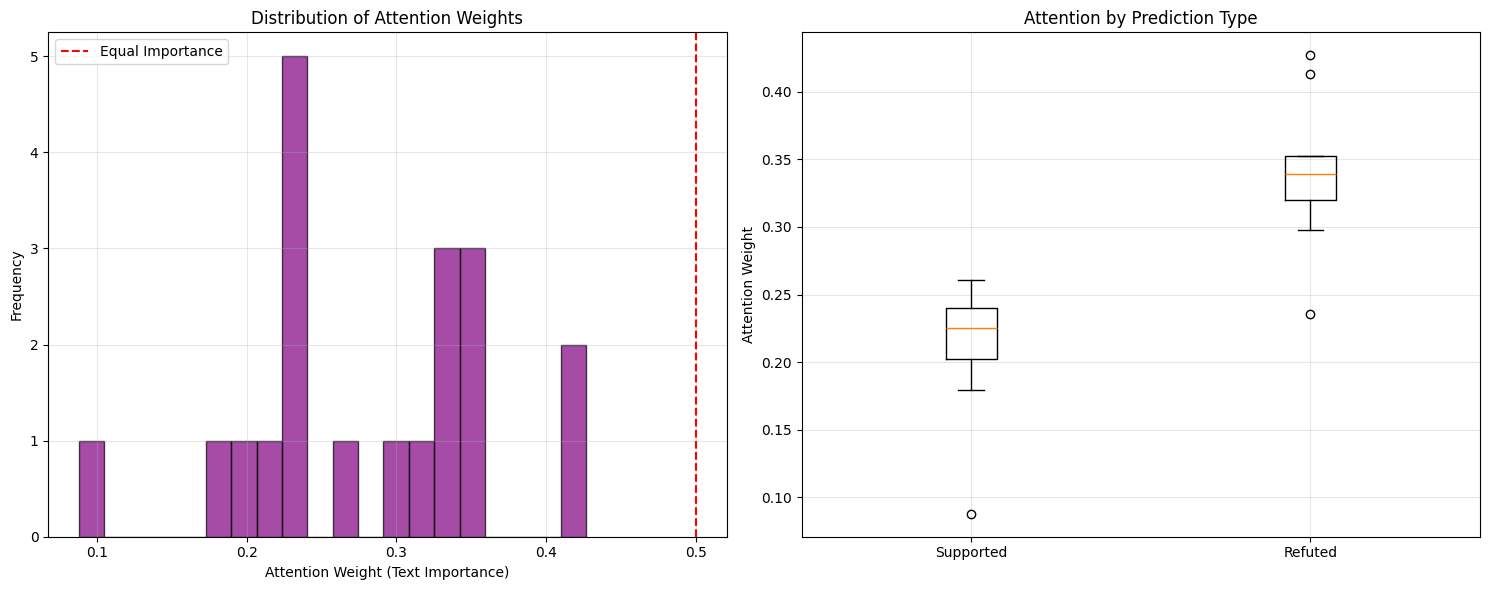


📈 Attention Analysis Summary:
   Samples analyzed: 20
   Mean attention: 0.281
   Std attention: 0.081
   Min attention: 0.088
   Max attention: 0.427
   Mean attention (Supported): 0.210
   Mean attention (Refuted): 0.339


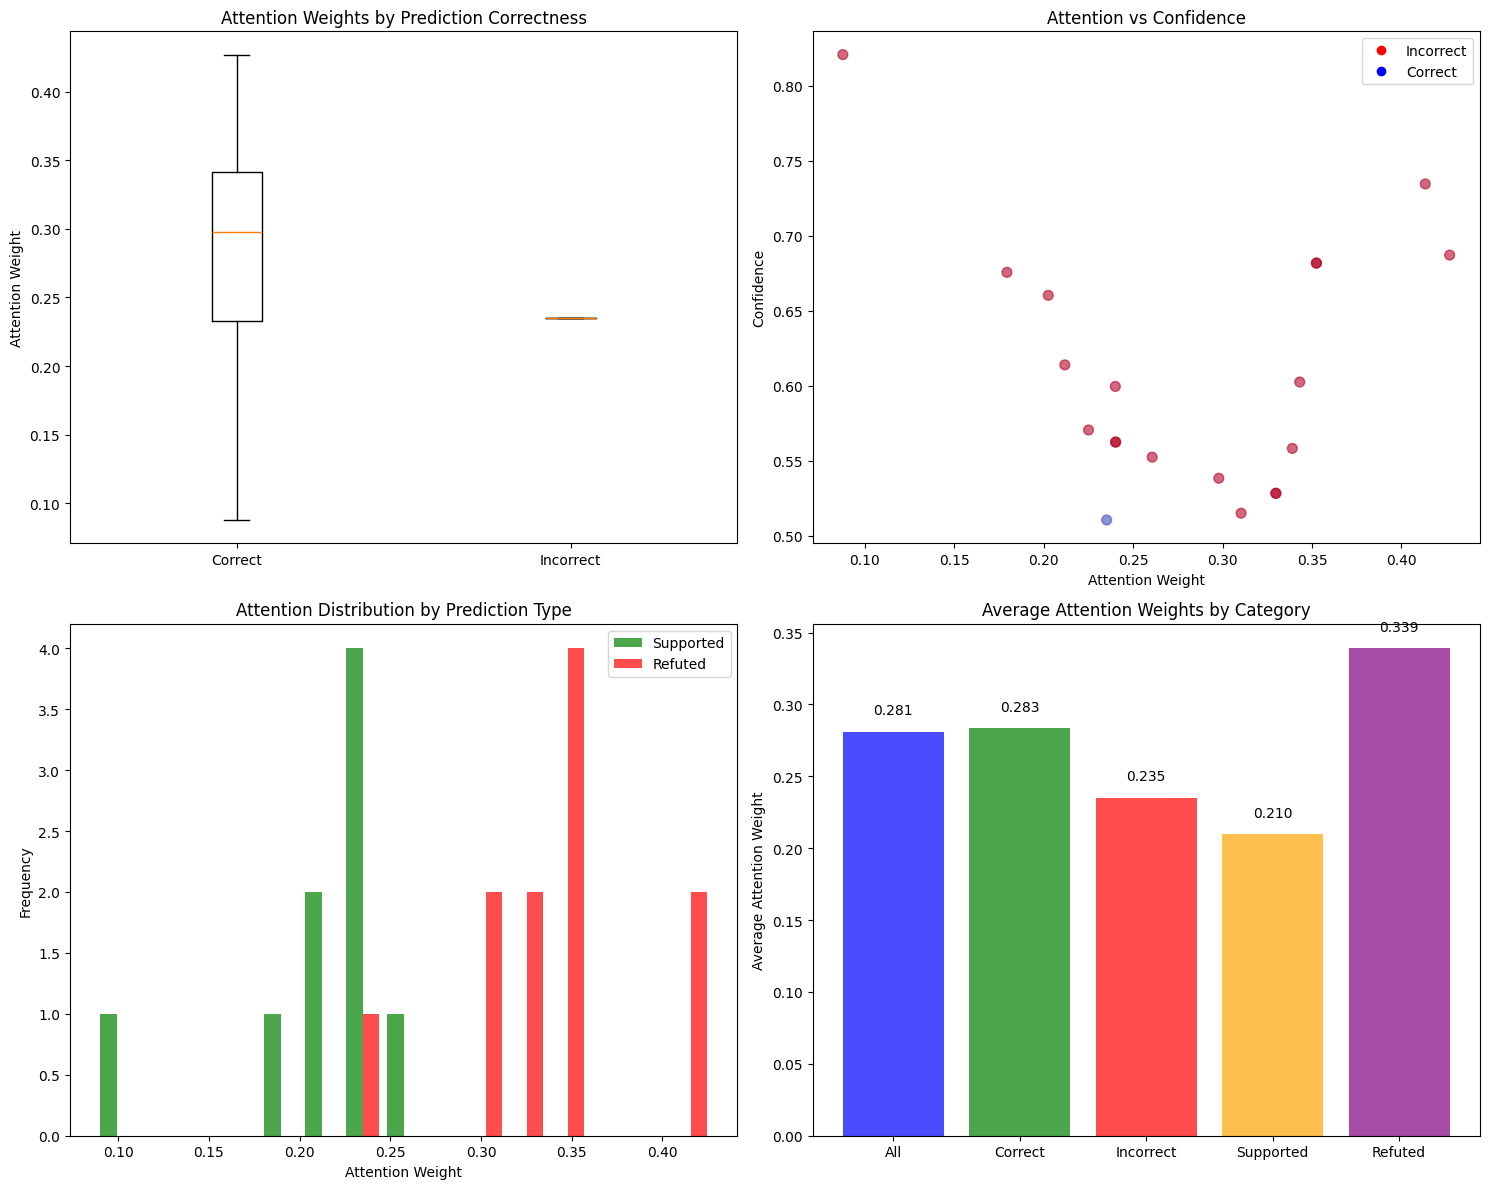

✅ Attention analysis completed!


In [56]:
    model = hybrid_model
    main_with_attention_analysis()